# State-Level Social and Economic Resilience After COVID-19

## Target Audience
This analysis is designed for **public health and economic development organizations** evaluating long-term post-COVID resilience across U.S. states.

## Research Question
**How did state-level economic and social resilience vary before and after COVID-19, and which conditions appear most associated with stronger recovery?**

## Why This Matters
COVID-19 was not only a public health shock. It disrupted employment, household stability, insurance access, housing affordability, and broader social well-being. For public health and economic development organizations, understanding which states recovered more strongly can help identify where future investment, policy support, and resilience planning may be most needed.

This notebook uses state-level ACS data to evaluate economic and social indicators from the pre-COVID period and post-COVID recovery period. The goal is not simply to describe trends, but to identify patterns that can inform action.

In [1]:
# Import libaries

import requests
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import geopandas as gpd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Data Collection

The core dataset comes from the American Community Survey 1-year estimates. ACS 1-year data is appropriate here because the analysis is at the state level and compares annual indicators across time.

The analysis excludes standard 2020 ACS 1-year data because the Census Bureau did not release normal ACS 1-year estimates for 2020 due to pandemic-related data collection issues. This makes the analysis a comparison of the pre-COVID period and the post-COVID recovery period, rather than a direct measurement of 2020 itself.

In [2]:
# Pulling data

# Paste your Census API key below.
# You can request one here: https://api.census.gov/data/key_signup.html
CENSUS_API_KEY = "b443fdec40a956a888b6f90ceb097f7a9d7962fc".strip()

# ACS 1-year years used in the analysis.
# 2020 is excluded because standard ACS 1-year estimates were not released.
years = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]

# Keys are Census variable codes.
# Values are readable column names used after the API pull.
acs_vars = {
    # Economic variables
    "B01003_001E": "total_population",
    "B19013_001E": "median_household_income",
    "B17001_002E": "population_below_poverty",
    "B17001_001E": "poverty_universe",
    "B15003_022E": "bachelors_degree",
    "B15003_023E": "masters_degree",
    "B15003_024E": "professional_degree",
    "B15003_025E": "doctorate_degree",
    "B15003_001E": "education_universe",
    "B25077_001E": "median_home_value",
    "B25064_001E": "median_rent",
    "B23025_003E": "employed",
    "B23025_005E": "unemployed",
    "B23025_002E": "labor_force",

    # Marriage / household stability variables
    "B12001_001E": "population_15_plus",
    "B12001_003E": "never_married_male",
    "B12001_012E": "never_married_female",
    "B12001_005E": "married_male",
    "B12001_014E": "married_female",
    "B12001_007E": "separated_male",
    "B12001_016E": "separated_female",
    "B12001_009E": "divorced_male",
    "B12001_018E": "divorced_female",
    "B12001_008E": "widowed_male",
    "B12001_017E": "widowed_female",
    "B12001_006E": "spouse_absent_male",
    "B12001_015E": "spouse_absent_female",

    # Health insurance variables
    "B27001_001E": "insurance_universe",
    "B27001_005E": "uninsured_male",
    "B27001_033E": "uninsured_female",
    "B27002_003E": "private_insurance",
    "B27003_003E": "public_insurance",

    # Housing stress variables
    "B25003_001E": "occupied_units",
    "B25003_002E": "owner_occupied_units",
    "B25003_003E": "renter_occupied_units",
    "B25010_002E": "avg_owner_household_size",
    "B25010_003E": "avg_renter_household_size",
    "B25002_003E": "vacant_units",
    "B25070_007E": "rent_30_34_pct_income",
    "B25070_008E": "rent_35_39_pct_income",
    "B25070_009E": "rent_40_49_pct_income",
    "B25070_010E": "rent_50_plus_pct_income",
    "B25014_005E": "overcrowded_owner_units",
    "B25014_011E": "overcrowded_renter_units",

    # Remote work / commuting variables 
    "B08301_001E": "workers_16_plus",
    "B08301_021E": "work_from_home",
    "B08301_010E": "public_transit_commuters",
    "B08013_001E": "aggregate_travel_time",
    "B08012_001E": "commuters_16_plus"

}

dfs = []

for year in years:
    print(f"\nPulling {year} ACS data...")

    url = f"https://api.census.gov/data/{year}/acs/acs1"

    api_params = {
        "get": ",".join(["NAME"] + list(acs_vars.keys())),
        "for": "state:*",
        "key": CENSUS_API_KEY
    }

    try:
        response = requests.get(url, params=api_params)
        response.raise_for_status()

        # If the key is invalid, the Census API sometimes returns HTML.
        # This check gives a clearer error message.
        if not response.text.lstrip().startswith("["):
            print(response.text[:500])
            raise ValueError("The API response was not JSON. Check your Census API key.")

        census_json = response.json()

        year_df = pd.DataFrame(census_json[1:], columns=census_json[0])
        year_df = year_df.rename(columns=acs_vars)
        year_df = year_df.rename(columns={"NAME": "state_name"})
        year_df["year"] = year

        dfs.append(year_df)

        print(f"Successfully pulled {len(year_df)} state-level rows")

    except Exception as e:
        print(f"Warning: could not fetch {year} data")
        print(e)

if len(dfs) == 0:
    raise ValueError("No ACS data was pulled. Check your Census API key and internet connection.")

census_data = pd.concat(dfs, ignore_index=True)

print("\nFinal raw dataframe shape:")
print(census_data.shape)

census_data.head()


Pulling 2011 ACS data...
Successfully pulled 52 state-level rows

Pulling 2012 ACS data...
Successfully pulled 52 state-level rows

Pulling 2013 ACS data...
Successfully pulled 52 state-level rows

Pulling 2014 ACS data...
Successfully pulled 52 state-level rows

Pulling 2015 ACS data...
Successfully pulled 52 state-level rows

Pulling 2016 ACS data...
Successfully pulled 52 state-level rows

Pulling 2017 ACS data...
Successfully pulled 52 state-level rows

Pulling 2018 ACS data...
Successfully pulled 52 state-level rows

Pulling 2019 ACS data...
Successfully pulled 52 state-level rows

Pulling 2021 ACS data...
Successfully pulled 52 state-level rows

Pulling 2022 ACS data...
Successfully pulled 52 state-level rows

Pulling 2023 ACS data...
Successfully pulled 52 state-level rows

Pulling 2024 ACS data...
Successfully pulled 52 state-level rows

Final raw dataframe shape:
(676, 52)


,state_name,total_population,median_household_income,population_below_poverty,poverty_universe,bachelors_degree,masters_degree,professional_degree,doctorate_degree,education_universe,median_home_value,median_rent,employed,unemployed,labor_force,population_15_plus,never_married_male,never_married_female,married_male,married_female,separated_male,separated_female,divorced_male,divorced_female,widowed_male,widowed_female,spouse_absent_male,spouse_absent_female,insurance_universe,uninsured_male,uninsured_female,private_insurance,public_insurance,occupied_units,owner_occupied_units,renter_occupied_units,avg_owner_household_size,avg_renter_household_size,vacant_units,rent_30_34_pct_income,rent_35_39_pct_income,rent_40_49_pct_income,rent_50_plus_pct_income,overcrowded_owner_units,overcrowded_renter_units,workers_16_plus,work_from_home,public_transit_commuters,aggregate_travel_time,commuters_16_plus,state,year
0,Alabama,4802740,41415,892483,4687363,443488,190977,43117,32950,3193078,122700,687,2240441,259346,2255995,3874758,596130,529806,911542,901278,40483,63147,53094,219928,43436,36513,83919,99660,4720067,7693,7790,185616,185616,1844546,1289217,555329,2.57,2.47,337653,44984,35018,45745,133883,10682,15295,1953274,51126,9329,45529580,1902148,01,2011
1,Alaska,722718,67825,73905,706860,77153,29269,8000,6039,456862,238300,1049,377710,33367,394406,565162,105171,77471,129991,129759,5827,5828,5370,15959,12546,7177,18373,13005,699272,3742,2602,33525,33525,257330,162312,95018,2.79,2.57,53852,8235,6387,7073,16881,5934,5404,348777,16875,6474,6102335,331902,02,2011
2,Arizona,6482505,46709,1203501,6336449,719546,291892,64212,43548,4211223,153800,850,3025208,337217,3040762,5129409,907782,740052,1157394,1133403,44118,58280,67841,218334,84800,71717,128918,129997,6378280,32064,24287,273955,273955,2356055,1501528,854527,2.67,2.72,508305,69846,54014,74189,207389,30639,43839,2650164,145782,52557,62003585,2504382,04,2011
3,Arkansas,2937979,38758,555876,2856663,254903,96313,25130,18474,1943427,106300,639,1363235,127480,1368632,2342376,336328,275492,576001,563922,23429,33910,30572,128078,30506,30511,53935,64421,2885212,5448,5738,119246,119246,1127621,750984,376637,2.58,2.44,196850,29822,22035,34575,85341,7259,10558,1215837,40569,5271,25049090,1175268,05,2011
4,California,37691912,57287,6118803,36941931,4697422,1791770,559241,357887,24443872,355600,1174,18737749,2311055,18869522,30062390,5959238,4956797,6480575,6357852,287508,420315,318513,1233616,592746,536058,880254,956373,37161789,93241,85150,1559703,1559703,12468743,6843369,5625374,3.00,2.91,1252444,495736,389931,558786,1622955,218733,450744,16047067,857352,827736,412264010,15189715,06,2011


## Data Cleaning and Initial Quality Checks

The ACS API returns most values as strings, so the first cleaning step converts numeric columns to numeric types. The dataset is then checked for missing values, year coverage, and state coverage.

These quality checks are important because the analysis compares states across years. Missing years or missing states would weaken the conclusions.

In [3]:
# Cleaning Data

# Convert numeric columns
for col in census_data.columns:
    if col not in ["state_name", "state"]:
        census_data[col] = pd.to_numeric(census_data[col], errors="coerce")

# Replace negative Census values with missing values.
# Census APIs sometimes use negative values for unavailable or invalid estimates.
numeric_cols = census_data.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    census_data.loc[census_data[col] < 0, col] = np.nan

# Add state abbreviations
state_fips_to_abbr = {
    1: "AL", 2: "AK", 4: "AZ", 5: "AR", 6: "CA", 8: "CO", 9: "CT",
    10: "DE", 11: "DC", 12: "FL", 13: "GA", 15: "HI", 16: "ID",
    17: "IL", 18: "IN", 19: "IA", 20: "KS", 21: "KY", 22: "LA",
    23: "ME", 24: "MD", 25: "MA", 26: "MI", 27: "MN", 28: "MS",
    29: "MO", 30: "MT", 31: "NE", 32: "NV", 33: "NH", 34: "NJ",
    35: "NM", 36: "NY", 37: "NC", 38: "ND", 39: "OH", 40: "OK",
    41: "OR", 42: "PA", 44: "RI", 45: "SC", 46: "SD", 47: "TN",
    48: "TX", 49: "UT", 50: "VT", 51: "VA", 53: "WA", 54: "WV",
    55: "WI", 56: "WY", 72: "PR"
}

region_map = {
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast",
    "PA": "Northeast",
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest",
    "WI": "Midwest", "IA": "Midwest", "KS": "Midwest", "MN": "Midwest",
    "MO": "Midwest", "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",
    "DE": "South", "DC": "South", "FL": "South", "GA": "South", "MD": "South",
    "NC": "South", "SC": "South", "VA": "South", "WV": "South", "AL": "South",
    "KY": "South", "MS": "South", "TN": "South", "AR": "South", "LA": "South",
    "OK": "South", "TX": "South",
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
    "NM": "West", "UT": "West", "WY": "West", "AK": "West", "CA": "West",
    "HI": "West", "OR": "West", "WA": "West"
}

# Convert state FIPS codes to integers first
census_data["state"] = pd.to_numeric(
    census_data["state"],
    errors="coerce"
)

# Map state abbreviations
census_data["state_abbreviation"] = census_data["state"].map(state_fips_to_abbr)

# Map regions
census_data["region"] = census_data["state_abbreviation"].map(region_map)


# Use apply for pre- and post- COVID designation
census_data["period"] = census_data["year"].apply(
    lambda year: "Pre-COVID" if year <= 2019 else "Post-COVID"
)

census_data.head()

,state_name,total_population,median_household_income,population_below_poverty,poverty_universe,bachelors_degree,masters_degree,professional_degree,doctorate_degree,education_universe,median_home_value,median_rent,employed,unemployed,labor_force,population_15_plus,never_married_male,never_married_female,married_male,married_female,separated_male,separated_female,divorced_male,divorced_female,widowed_male,widowed_female,spouse_absent_male,spouse_absent_female,insurance_universe,uninsured_male,uninsured_female,private_insurance,public_insurance,occupied_units,owner_occupied_units,renter_occupied_units,avg_owner_household_size,avg_renter_household_size,vacant_units,rent_30_34_pct_income,rent_35_39_pct_income,rent_40_49_pct_income,rent_50_plus_pct_income,overcrowded_owner_units,overcrowded_renter_units,workers_16_plus,work_from_home,public_transit_commuters,aggregate_travel_time,commuters_16_plus,state,year,state_abbreviation,region,period
0,Alabama,"4,802,740.0000","41,415.0000","892,483.0000","4,687,363.0000","443,488.0000","190,977.0000","43,117.0000","32,950.0000","3,193,078.0000","122,700.0000",687.0000,"2,240,441.0000","259,346.0000","2,255,995.0000","3,874,758.0000","596,130.0000","529,806.0000","911,542.0000","901,278.0000","40,483.0000","63,147.0000","53,094.0000","219,928.0000","43,436.0000","36,513.0000","83,919.0000","99,660.0000","4,720,067.0000","7,693.0000","7,790.0000","185,616.0000","185,616.0000","1,844,546.0000","1,289,217.0000","555,329.0000",2.5700,2.4700,"337,653.0000","44,984.0000","35,018.0000","45,745.0000","133,883.0000","10,682.0000","15,295.0000","1,953,274.0000","51,126.0000","9,329.0000","45,529,580.0000","1,902,148.0000",1,"2,011.0000",AL,South,Pre-COVID
1,Alaska,"722,718.0000","67,825.0000","73,905.0000","706,860.0000","77,153.0000","29,269.0000","8,000.0000","6,039.0000","456,862.0000","238,300.0000","1,049.0000","377,710.0000","33,367.0000","394,406.0000","565,162.0000","105,171.0000","77,471.0000","129,991.0000","129,759.0000","5,827.0000","5,828.0000","5,370.0000","15,959.0000","12,546.0000","7,177.0000","18,373.0000","13,005.0000","699,272.0000","3,742.0000","2,602.0000","33,525.0000","33,525.0000","257,330.0000","162,312.0000","95,018.0000",2.7900,2.5700,"53,852.0000","8,235.0000","6,387.0000","7,073.0000","16,881.0000","5,934.0000","5,404.0000","348,777.0000","16,875.0000","6,474.0000","6,102,335.0000","331,902.0000",2,"2,011.0000",AK,West,Pre-COVID
2,Arizona,"6,482,505.0000","46,709.0000","1,203,501.0000","6,336,449.0000","719,546.0000","291,892.0000","64,212.0000","43,548.0000","4,211,223.0000","153,800.0000",850.0000,"3,025,208.0000","337,217.0000","3,040,762.0000","5,129,409.0000","907,782.0000","740,052.0000","1,157,394.0000","1,133,403.0000","44,118.0000","58,280.0000","67,841.0000","218,334.0000","84,800.0000","71,717.0000","128,918.0000","129,997.0000","6,378,280.0000","32,064.0000","24,287.0000","273,955.0000","273,955.0000","2,356,055.0000","1,501,528.0000","854,527.0000",2.6700,2.7200,"508,305.0000","69,846.0000","54,014.0000","74,189.0000","207,389.0000","30,639.0000","43,839.0000","2,650,164.0000","145,782.0000","52,557.0000","62,003,585.0000","2,504,382.0000",4,"2,011.0000",AZ,West,Pre-COVID
3,Arkansas,"2,937,979.0000","38,758.0000","555,876.0000","2,856,663.0000","254,903.0000","96,313.0000","25,130.0000","18,474.0000","1,943,427.0000","106,300.0000",639.0000,"1,363,235.0000","127,480.0000","1,368,632.0000","2,342,376.0000","336,328.0000","275,492.0000","576,001.0000","563,922.0000","23,429.0000","33,910.0000","30,572.0000","128,078.0000","30,506.0000","30,511.0000","53,935.0000","64,421.0000","2,885,212.0000","5,448.0000","5,738.0000","119,246.0000","119,246.0000","1,127,621.0000","750,984.0000","376,637.0000",2.5800,2.4400,"196,850.0000","29,822.0000","22,035.0000","34,575.0000","85,341.0000","7,259.0000","10,558.0000","1,215,837.0000","40,569.0000","5,271.0000","25,049,090.0000","1,175,268.0000",5,"2,011.0000",AR,South,Pre-COVID
4,California,"37,691,912.0000","57,287.0000","6

In [82]:
# Checking Data Quality

# Missing values
missing_table = (
    census_data.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_table["missing_pct"] = missing_table["missing_count"] / len(census_data)

missing_table.sort_values("missing_pct", ascending=False).head(20)

,column,missing_count,missing_pct
0,state_name,0,0.0000
1,total_population,0,0.0000
2,median_household_income,0,0.0000
3,population_below_poverty,0,0.0000
4,poverty_universe,0,0.0000
5,bachelors_degree,0,0.0000
6,masters_degree,0,0.0000
7,professional_degree,0,0.0000
8,doctorate_degree,0,0.0000
9,education_universe,0,0.0000


In [83]:
#check which entries are missing regions

missing_regions = census_data[census_data["region"].isna()]

missing_regions

,state_name,total_population,median_household_income,population_below_poverty,poverty_universe,bachelors_degree,masters_degree,professional_degree,doctorate_degree,education_universe,median_home_value,median_rent,employed,unemployed,labor_force,population_15_plus,never_married_male,never_married_female,married_male,married_female,separated_male,separated_female,divorced_male,divorced_female,widowed_male,widowed_female,spouse_absent_male,spouse_absent_female,insurance_universe,uninsured_male,uninsured_female,private_insurance,public_insurance,occupied_units,owner_occupied_units,renter_occupied_units,avg_owner_household_size,avg_renter_household_size,vacant_units,rent_30_34_pct_income,rent_35_39_pct_income,rent_40_49_pct_income,rent_50_plus_pct_income,overcrowded_owner_units,overcrowded_renter_units,workers_16_plus,work_from_home,public_transit_commuters,aggregate_travel_time,commuters_16_plus,state,year,state_abbreviation,region,period


In [84]:
# These are all Puerto Rico, we will make Puerto Rico the Region beause it does not fall into any standard region
census_data["region"] = census_data["region"].fillna("Puerto Rico")
census_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   state_name                 676 non-null    str    
 1   total_population           676 non-null    float64
 2   median_household_income    676 non-null    float64
 3   population_below_poverty   676 non-null    float64
 4   poverty_universe           676 non-null    float64
 5   bachelors_degree           676 non-null    float64
 6   masters_degree             676 non-null    float64
 7   professional_degree        676 non-null    float64
 8   doctorate_degree           676 non-null    float64
 9   education_universe         676 non-null    float64
 10  median_home_value          676 non-null    float64
 11  median_rent                676 non-null    float64
 12  employed                   676 non-null    float64
 13  unemployed                 676 non-null    float64
 14  labor

In [85]:
# Convert year column from float to integer

census_data["year"] = census_data["year"].astype(int)

# Verify
census_data["year"].dtype

dtype('int64')

In [86]:
# Year coverage
year_coverage = (
    census_data.groupby("year")
    .agg(
        row_count=("state_name", "count"),
        unique_states=("state_name", "nunique")
    )
    .reset_index()
)

year_coverage

,year,row_count,unique_states
0,2011,52,52
1,2012,52,52
2,2013,52,52
3,2014,52,52
4,2015,52,52
5,2016,52,52
6,2017,52,52
7,2018,52,52
8,2019,52,52
9,2021,52,52


In [87]:
# Region coverage
region_coverage = (
    census_data.groupby(["region", "period"])
    .agg(
        row_count=("state_name", "count"),
        unique_states=("state_name", "nunique")
    )
    .reset_index()
)

region_coverage

,region,period,row_count,unique_states
0,Midwest,Post-COVID,48,12
1,Midwest,Pre-COVID,108,12
2,Northeast,Post-COVID,36,9
3,Northeast,Pre-COVID,81,9
4,Puerto Rico,Post-COVID,4,1
5,Puerto Rico,Pre-COVID,9,1
6,South,Post-COVID,68,17
7,South,Pre-COVID,153,17
8,West,Post-COVID,52,13
9,West,Pre-COVID,117,13


## Feature Engineering Integrated Into the Analysis

The raw ACS variables are useful, but they do not directly answer the resilience question. To make the data more actionable, this section creates indicators for economic stability, education, insurance access, relationship stability, housing stress, and overall resilience.

These engineered features allow the analysis to compare states on interpretable rates rather than raw population data.

In [88]:
# Feature Engineering

acs = census_data.copy()

# Economic indicators
acs["poverty_rate"] = acs["population_below_poverty"] / acs["poverty_universe"]
acs["unemployment_rate"] = acs["unemployed"] / acs["labor_force"]

acs["bachelors_plus"] = (
    acs["bachelors_degree"] +
    acs["masters_degree"] +
    acs["professional_degree"] +
    acs["doctorate_degree"]
)

acs["education_rate"] = acs["bachelors_plus"] / acs["education_universe"]
acs["rent_to_income_ratio"] = (acs["median_rent"] * 12) / acs["median_household_income"]

# Relationship and household stability indicators
acs["never_married_rate"] = (
    acs["never_married_male"] + acs["never_married_female"]
) / acs["population_15_plus"]

acs["married_rate"] = (
    acs["married_male"] + acs["married_female"]
) / acs["population_15_plus"]

acs["divorce_rate"] = (
    acs["divorced_male"] + acs["divorced_female"]
) / acs["population_15_plus"]

acs["separation_rate"] = (
    acs["separated_male"] + acs["separated_female"]
) / acs["population_15_plus"]

acs["widowed_rate"] = (
    acs["widowed_male"] + acs["widowed_female"]
) / acs["population_15_plus"]

acs["spouse_absent_rate"] = (
    acs["spouse_absent_male"] + acs["spouse_absent_female"]
) / acs["population_15_plus"]

# Insurance access indicators
acs["uninsured_rate"] = (
    acs["uninsured_male"] + acs["uninsured_female"]
) / acs["insurance_universe"]

acs["private_public_insurance_ratio"] = acs["private_insurance"] / acs["public_insurance"]

# Housing stress indicators
acs["renter_rate"] = acs["renter_occupied_units"] / acs["occupied_units"]

acs["cost_burdened_renter_units"] = (
    acs["rent_30_34_pct_income"] +
    acs["rent_35_39_pct_income"] +
    acs["rent_40_49_pct_income"] +
    acs["rent_50_plus_pct_income"]
)

acs["cost_burden_rate"] = acs["cost_burdened_renter_units"] / acs["renter_occupied_units"]

acs["overcrowding_rate"] = (
    acs["overcrowded_owner_units"] + acs["overcrowded_renter_units"]
) / acs["occupied_units"]

# Commute and remote work indicators
acs["remote_work_rate"] = acs["work_from_home"] / acs["workers_16_plus"]

acs["public_transit_rate"] = (
    acs["public_transit_commuters"] / acs["workers_16_plus"]
)

acs["mean_commute_time"] = (
    acs["aggregate_travel_time"] / acs["commuters_16_plus"]
)

# Avoid infinite values that may have been created with the feature engineering
acs = acs.replace([np.inf, -np.inf], np.nan)

acs.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 75 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state_name                      676 non-null    str    
 1   total_population                676 non-null    float64
 2   median_household_income         676 non-null    float64
 3   population_below_poverty        676 non-null    float64
 4   poverty_universe                676 non-null    float64
 5   bachelors_degree                676 non-null    float64
 6   masters_degree                  676 non-null    float64
 7   professional_degree             676 non-null    float64
 8   doctorate_degree                676 non-null    float64
 9   education_universe              676 non-null    float64
 10  median_home_value               676 non-null    float64
 11  median_rent                     676 non-null    float64
 12  employed                        676 non-null   

## Economic Recovery: Did States Rebound Equally?

The first section focuses on traditional economic recovery indicators: income, poverty, and unemployment. For public health and economic development organizations, these measures help identify where household financial stability improved and where vulnerability persisted.

In [89]:
# Economic Recovery

# Groupby 1: National averages by year
yearly_summary = (
    acs.groupby("year")
    .agg(
        avg_income=("median_household_income", "mean"),
        avg_poverty_rate=("poverty_rate", "mean"),
        avg_unemployment_rate=("unemployment_rate", "mean"),
        avg_education_rate=("education_rate", "mean"),
        avg_uninsured_rate=("uninsured_rate", "mean"),
        avg_cost_burden_rate=("cost_burden_rate", "mean"),
        avg_spouse_absent_rate=("spouse_absent_rate", "mean")
    )
    .reset_index()
)

yearly_summary

,year,avg_income,avg_poverty_rate,avg_unemployment_rate,avg_education_rate,avg_uninsured_rate,avg_cost_burden_rate,avg_spouse_absent_rate
0,2011,"50,278.8846",0.1584,0.0949,0.2825,0.0044,0.4657,0.0440
1,2012,"51,348.9808",0.1579,0.0865,0.2883,0.0043,0.4535,0.0435
2,2013,"52,518.4615",0.1574,0.0793,0.2930,0.0043,0.4505,0.0449
3,2014,"53,770.4231",0.1547,0.0691,0.2964,0.0036,0.4514,0.0447
4,2015,"55,680.2115",0.1485,0.0612,0.3023,0.0031,0.4412,0.0425
5,2016,"57,410.9038",0.1419,0.0567,0.3090,0.0029,0.4344,0.0424
6,2017,"59,448.9423",0.1373,0.0525,0.3153,0.0030,0.4326,0.0417
7,2018,"61,210.8269",0.1350,0.0491,0.3206,0.0031,0.4357,0.0420
8,2019,"64,645.2115",0.1277,0.0453,0.3260,0.0033,0.4269,0.0407
9,2021,"68,339.7885",0.1315,0.0577,0.3455,0.0031,0.4480,0.0379


In [90]:
# Groupby 2: Pre vs post summary
period_summary = (
    acs.groupby("period")
    .agg(
        avg_income=("median_household_income", "mean"),
        avg_poverty_rate=("poverty_rate", "mean"),
        avg_unemployment_rate=("unemployment_rate", "mean"),
        avg_education_rate=("education_rate", "mean"),
        avg_uninsured_rate=("uninsured_rate", "mean"),
        avg_cost_burden_rate=("cost_burden_rate", "mean"),
        avg_divorce_rate=("divorce_rate", "mean"),
        avg_overcrowding_rate=("overcrowding_rate", "mean")
    )
    .round(4)
    .reset_index()
)

period_summary

,period,avg_income,avg_poverty_rate,avg_unemployment_rate,avg_education_rate,avg_uninsured_rate,avg_cost_burden_rate,avg_divorce_rate,avg_overcrowding_rate
0,Post-COVID,"74,707.8029",0.1282,0.0453,0.3540,0.0031,0.4513,0.0558,0.0182
1,Pre-COVID,"56,256.9829",0.1465,0.0661,0.3037,0.0036,0.4436,0.0588,0.0191


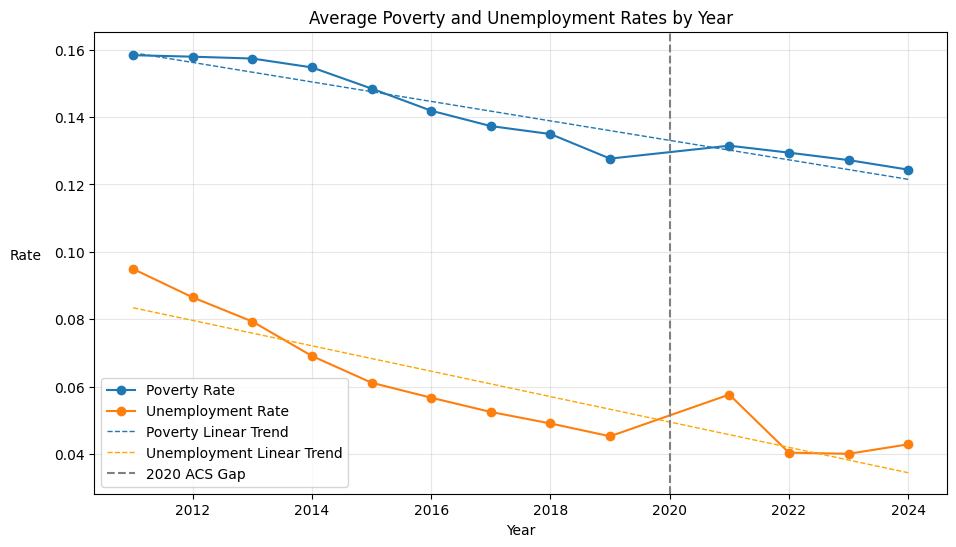

In [91]:
# Chart 1: Economic trends over time

plt.figure(figsize=(11, 6))

plt.plot(yearly_summary["year"], yearly_summary["avg_poverty_rate"], marker="o", label="Poverty Rate")
plt.plot(yearly_summary["year"], yearly_summary["avg_unemployment_rate"], marker="o", label="Unemployment Rate")

# Poverty rate trend line
#prepare X and y for sklearn
X1 = yearly_summary[["year"]]
y1 = yearly_summary["avg_poverty_rate"]

#Fit regression
linreg_model_pov = LinearRegression()
linreg_model_pov.fit(X1, y1)

y_pred_pov = linreg_model_pov.predict(X1)

# Unemployment rate trend line
#prepare X and y for sklearn
X2 = yearly_summary[["year"]]
y2 = yearly_summary["avg_unemployment_rate"]

#Fit regression
linreg_model_unemp = LinearRegression()
linreg_model_unemp.fit(X2, y2)

y_pred_unemp = linreg_model_unemp.predict(X2)

plt.plot(yearly_summary["year"],y_pred_pov,linestyle="--",linewidth=1, label="Poverty Linear Trend", color="C0")
plt.plot(yearly_summary["year"],y_pred_unemp,linestyle="--",linewidth=1, label="Unemployment Linear Trend", color="orange")

plt.axvline(2020, linestyle="--", color="gray", label="2020 ACS Gap")

plt.title("Average Poverty and Unemployment Rates by Year")
plt.xlabel("Year")
plt.ylabel("Rate", rotation=0, labelpad=20)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

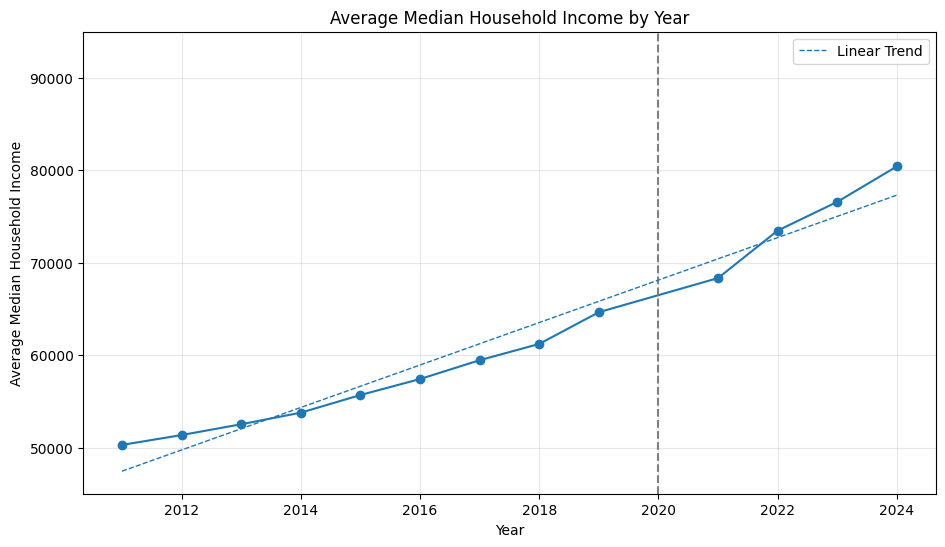

In [92]:
# Chart 2: Median household income trend

plt.figure(figsize=(11, 6))

plt.plot(yearly_summary["year"], yearly_summary["avg_income"], marker="o")

plt.axvline(2020, linestyle="--", color="gray")

# Unemployment rate trend line
#prepare X and y for sklearn
X1 = yearly_summary[["year"]]
y1 = yearly_summary["avg_income"]

#Fit regression
linreg_model_income = LinearRegression()
linreg_model_income.fit(X1, y1)

y_pred_income = linreg_model_income.predict(X1)

plt.plot(yearly_summary["year"],y_pred_income,linestyle="--",linewidth=1, label="Linear Trend", color="C0")

plt.title("Average Median Household Income by Year")
plt.xlabel("Year")
plt.ylabel("Average Median Household Income")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(45000, 95000)

plt.show()

### Interpretation

The first economic view establishes the recovery baseline. If income rose while poverty or unemployment remained elevated in some states, that would suggest uneven recovery. This distinction matters for public health and economic development organizations because higher income alone may not fully capture household vulnerability.

Linear trendlines are included to visualize the overall directional movement of rates across time. These lines are intended as descriptive summaries rather than predictive forecasting models.

### Economic Recovery Improved Faster Than Broader Social Vulnerability

At a national level, the data suggests that the United States experienced a meaningful economic recovery following COVID-19. Median household income increased steadily throughout the study period and accelerated in the post-pandemic years, while unemployment rates generally trended downward after the temporary spike following the pandemic disruption. Together, these trends point toward relatively strong labor market recovery and improving economic conditions overall.

However, the recovery appears more complicated when looking beyond employment and income alone. Poverty rates improved more slowly and remained relatively persistent even as unemployment declined. This suggests that returning to work did not immediately translate into full financial stability for many households. While labor markets recovered, broader economic vulnerability likely continued through ongoing affordability pressures, uneven wage growth, and lingering household stress.

For public health and economic development organizations, these findings highlight why recovery should be evaluated across multiple dimensions rather than through a single economic indicator. Strong employment numbers do not necessarily mean communities have fully recovered from the long-term social and economic impacts of the pandemic. These initial trends help motivate the deeper state-level and regional analysis explored throughout the remainder of the project.

## Social Recovery: Did Economic Improvement Translate Into Better Social Conditions?

This section adds social indicators: health insurance access, housing burden, overcrowding, and relationship stability. These measures help assess whether post-COVID recovery was broad-based or whether economic gains masked persistent stress in daily life.

In [93]:
# Groupby 3: Regional averages
regional_summary = (
    acs.groupby(["region", "period"])
    .agg(
        avg_income=("median_household_income", "mean"),
        avg_poverty_rate=("poverty_rate", "mean"),
        avg_uninsured_rate=("uninsured_rate", "mean"),
        avg_cost_burden_rate=("cost_burden_rate", "mean"),
        avg_overcrowding_rate=("overcrowding_rate", "mean"),
        avg_divorce_rate=("divorce_rate", "mean")
    )
    .round(4)
    .reset_index()
)

regional_summary

,region,period,avg_income,avg_poverty_rate,avg_uninsured_rate,avg_cost_burden_rate,avg_overcrowding_rate,avg_divorce_rate
0,Midwest,Post-COVID,"71,636.4792",0.1160,0.0033,0.4217,0.0134,0.0553
1,Midwest,Pre-COVID,"55,166.3889",0.1308,0.0036,0.4195,0.0138,0.0591
2,Northeast,Post-COVID,"84,628.4167",0.1057,0.0018,0.4725,0.0150,0.0553
3,Northeast,Pre-COVID,"63,780.8395",0.1173,0.0020,0.4720,0.0144,0.0601
4,Puerto Rico,Post-COVID,"24,795.7500",0.3978,0.0009,0.2960,0.0172,0.0795
5,Puerto Rico,Pre-COVID,"19,446.3333",0.4474,0.0016,0.3034,0.0266,0.0731
6,South,Post-COVID,"70,011.1176",0.1432,0.0033,0.4562,0.0170,0.0603
7,South,Pre-COVID,"52,725.6797",0.1635,0.0035,0.4446,0.0172,0.0630
8,West,Post-COVID,"80,655.9615",0.1144,0.0036,0.4697,0.0264,0.0491
9,West,Pre-COVID,"59,504.3077",0.1359,0.0048,0.4554,0.0292,0.0511


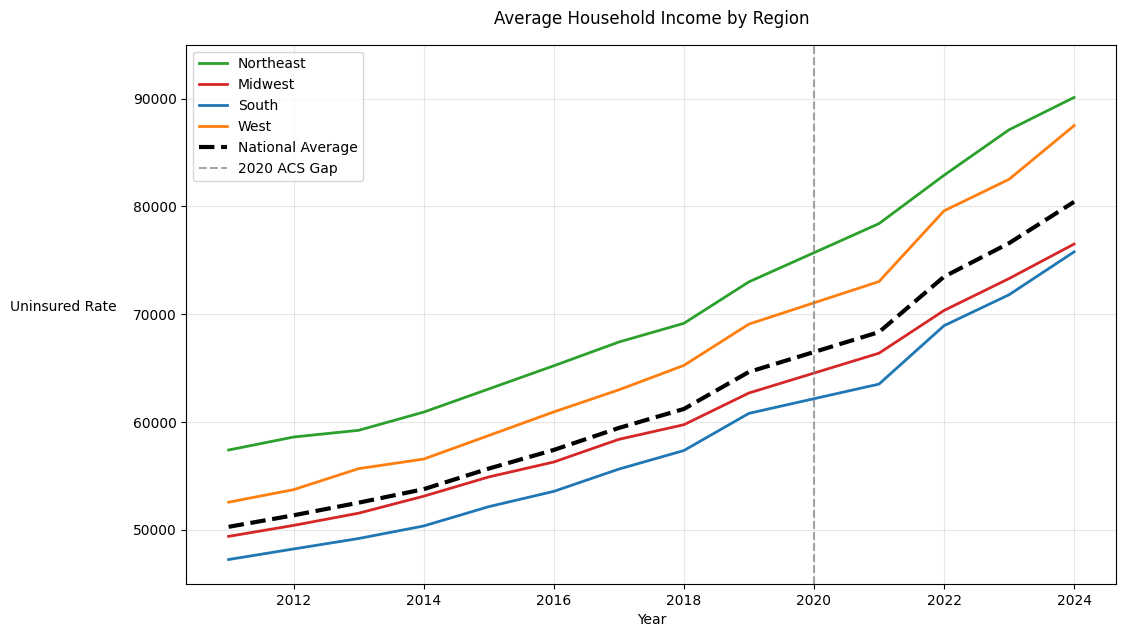

In [94]:
# Chart: Median income over time by region

# Custom colors for each region
region_colors = {
    "South": "C0",
    "West": "C1",
    "Northeast": "C2",
    "Midwest": "C3",
    "Puerto Rico": "C4"
}

# Regional yearly summary dataframe

regional_yearly = (acs.groupby(["region", "year"]).agg(avg_income=("median_household_income", "mean")).reset_index())

plt.figure(figsize=(12, 7))

regions = ["Northeast", "Midwest", "South", "West"]

# Regional lines
for region in regions:

    temp = regional_yearly[regional_yearly["region"] == region]

    plt.plot(
        temp["year"],
        temp["avg_income"],
        linewidth=2,
        label=region,
        color=region_colors[region]
    )

# National average line
plt.plot(
    yearly_summary["year"],
    yearly_summary["avg_income"],
    linestyle="--",
    linewidth=3,
    color="black",
    label="National Average"
)

# COVID reference line
plt.axvline(
    2020,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label="2020 ACS Gap"
)

plt.title("Average Household Income by Region",pad=15)
plt.xlabel("Year")
plt.ylim(45000, 95000)
plt.ylabel("Uninsured Rate",rotation=0,labelpad=50)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

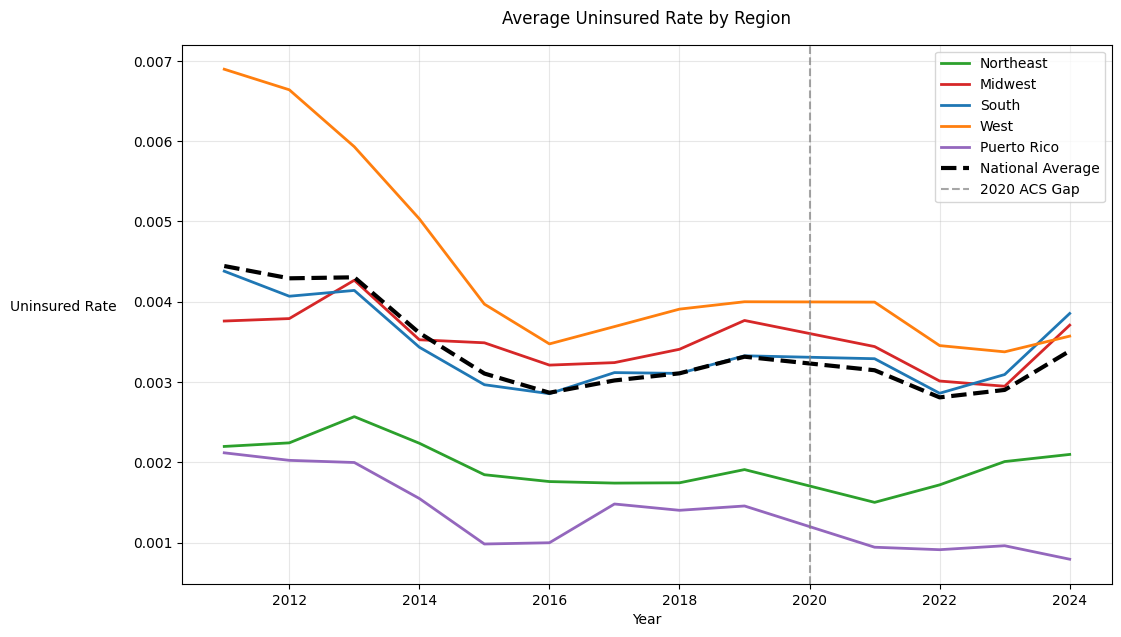

In [95]:
# Chart 3: Uninsured rate over time by region

# Custom colors for each region
region_colors = {
    "South": "C0",
    "West": "C1",
    "Northeast": "C2",
    "Midwest": "C3",
    "Puerto Rico": "C4"
}

# Regional yearly summary dataframe

regional_yearly = (acs.groupby(["region", "year"]).agg(avg_uninsured_rate=("uninsured_rate", "mean")).reset_index())

plt.figure(figsize=(12, 7))

regions = ["Northeast", "Midwest", "South", "West", "Puerto Rico"]

# Regional lines
for region in regions:

    temp = regional_yearly[regional_yearly["region"] == region]

    plt.plot(
        temp["year"],
        temp["avg_uninsured_rate"],
        linewidth=2,
        label=region,
        color=region_colors[region]
    )

# National average line
plt.plot(
    yearly_summary["year"],
    yearly_summary["avg_uninsured_rate"],
    linestyle="--",
    linewidth=3,
    color="black",
    label="National Average"
)

# COVID reference line
plt.axvline(
    2020,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label="2020 ACS Gap"
)

plt.title("Average Uninsured Rate by Region",pad=15)
plt.xlabel("Year")
plt.ylabel("Uninsured Rate",rotation=0,labelpad=50)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

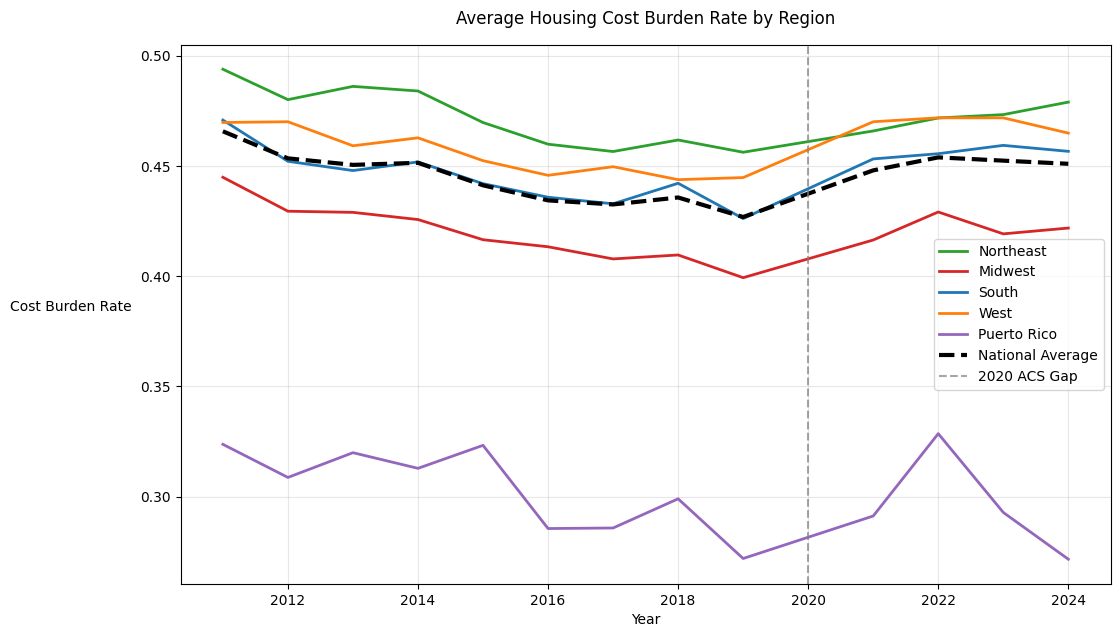

In [96]:
# Chart 4: Housing cost burden over time by region

# Custom colors for each region
region_colors = {
    "South": "C0",
    "West": "C1",
    "Northeast": "C2",
    "Midwest": "C3",
    "Puerto Rico": "C4"
}

# Regional yearly summary dataframe

regional_yearly = (acs.groupby(["region", "year"]).agg(avg_cost_burden_rate=("cost_burden_rate", "mean")).reset_index())

plt.figure(figsize=(12, 7))

regions = ["Northeast", "Midwest", "South", "West", "Puerto Rico"]

# Regional lines
for region in regions:

    temp = regional_yearly[regional_yearly["region"] == region]

    plt.plot(
        temp["year"],
        temp["avg_cost_burden_rate"],
        linewidth=2,
        label=region,
        color=region_colors[region]
    )

# National average line
plt.plot(
    yearly_summary["year"],
    yearly_summary["avg_cost_burden_rate"],
    linestyle="--",
    linewidth=3,
    color="black",
    label="National Average"
)

# COVID reference line
plt.axvline(
    2020,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label="2020 ACS Gap"
)

plt.title("Average Housing Cost Burden Rate by Region",pad=15)
plt.xlabel("Year")
plt.ylabel("Cost Burden Rate",rotation=0,labelpad=50)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

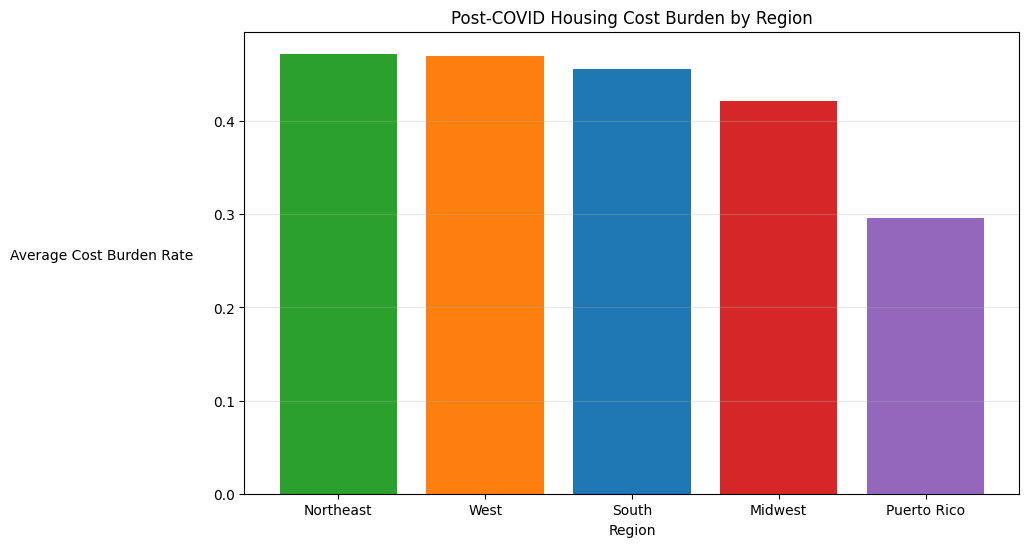

In [97]:
# Chart 5: Regional comparison of housing burden

# custom colors for each region
region_colors = {
    "South": "C0",
    "West": "C1",
    "Northeast": "C2",
    "Midwest": "C3",
    "Puerto Rico": "C4"
}

# Match colors to bars
regional_post = regional_summary[regional_summary["period"] == "Post-COVID"].sort_values(
    "avg_cost_burden_rate", ascending=False
)
bar_colors = regional_post["region"].map(region_colors)



plt.figure(figsize=(10, 6))

plt.bar(regional_post["region"], regional_post["avg_cost_burden_rate"], color = bar_colors)

plt.title("Post-COVID Housing Cost Burden by Region")
plt.xlabel("Region")
plt.ylabel("Average Cost Burden Rate",rotation= 0, labelpad=80)
plt.grid(axis="y", alpha=0.3)

plt.show()

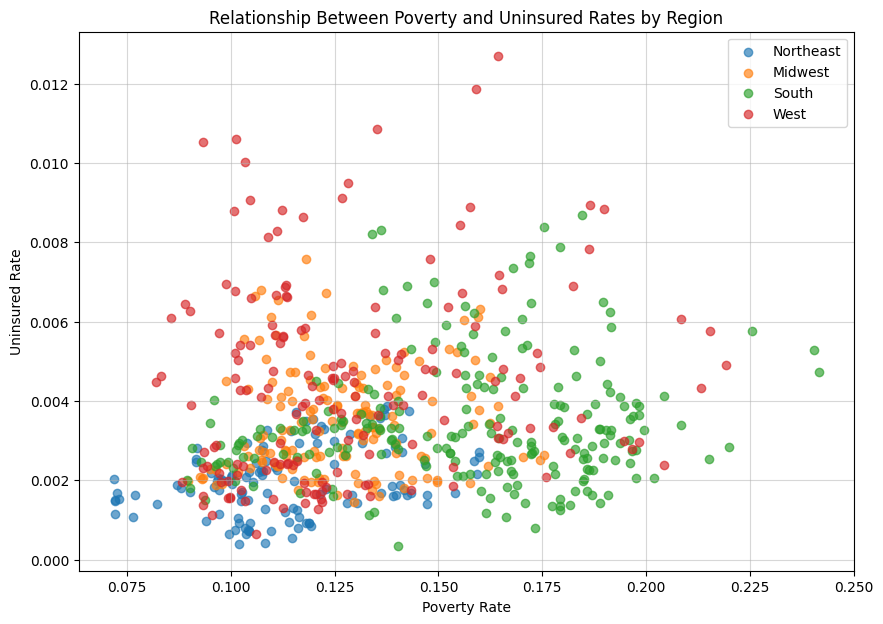

In [98]:
# Chart 6: Poverty vs uninsured rate by region

plt.figure(figsize=(10, 7))


for region in ["Northeast", "Midwest", "South", "West"]:

    temp = acs[acs["region"] == region]
    
    plt.scatter(
        temp["poverty_rate"],
        temp["uninsured_rate"],
        alpha=0.65,
        label=region
    )

plt.title("Relationship Between Poverty and Uninsured Rates by Region")
plt.xlabel("Poverty Rate")
plt.ylabel("Uninsured Rate")
plt.legend()
plt.grid(alpha=0.5)

plt.show()

Each point in the scatterplot represents a single state-year observation. Because the dataset spans multiple years, individual states appear multiple times throughout the figure, allowing the analysis to evaluate both regional clustering and changes over time in the relationship between poverty and uninsured rates.

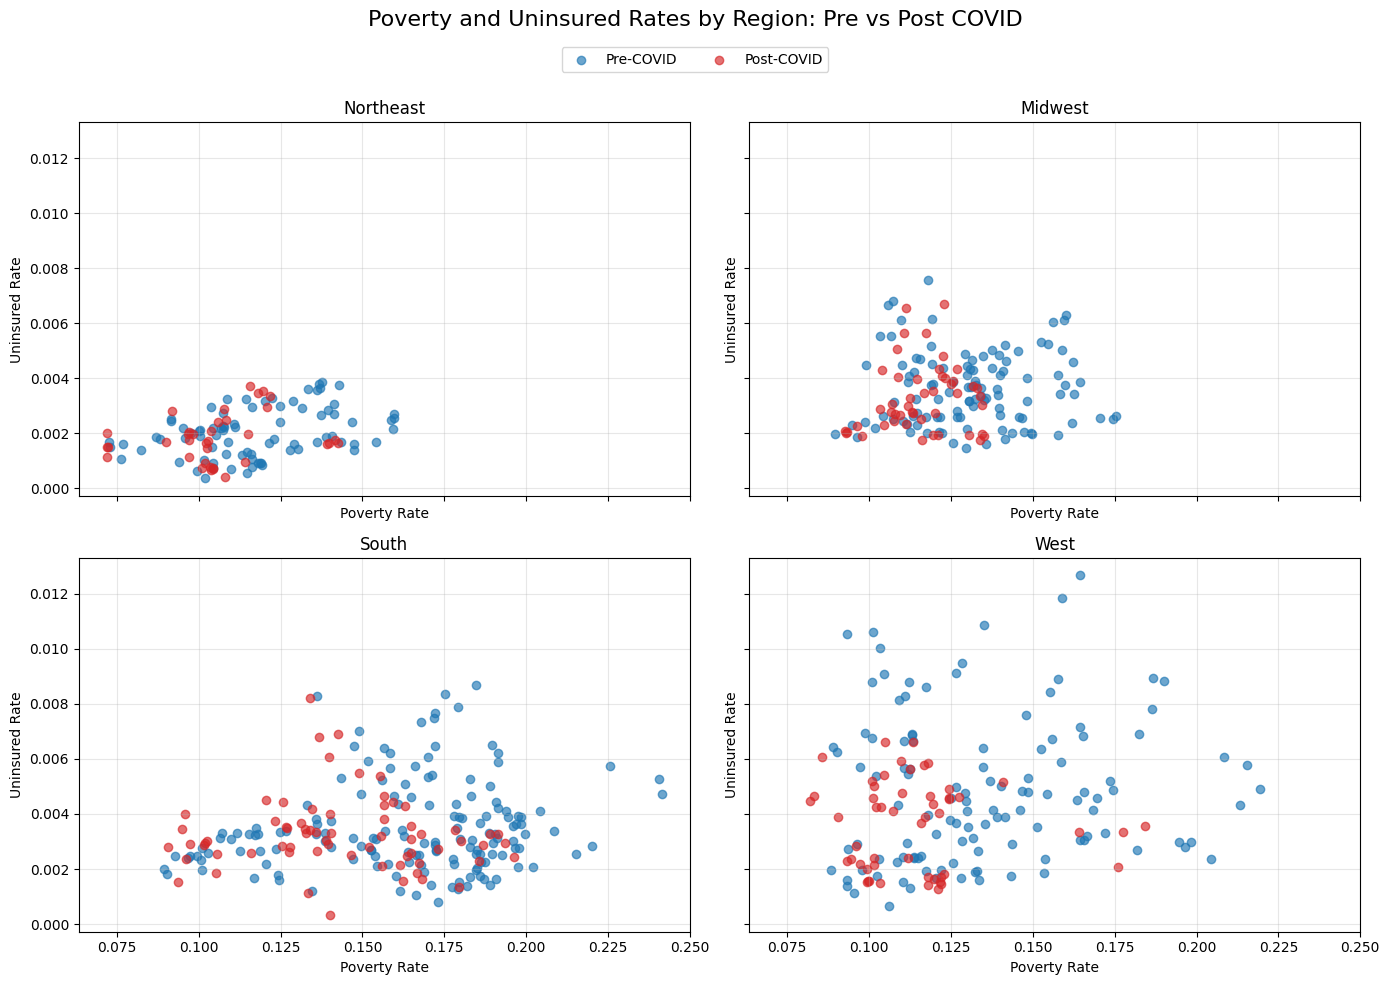

In [99]:
# Chart 7: Poverty vs uninsured rate by pre or post covid and by region (excluding puerto rico)

# Poverty vs uninsured rate by region
# Pre vs Post COVID shown with different colors

plot_df = acs.copy()

regions = ["Northeast", "Midwest", "South", "West"]

period_colors = {
    "Pre-COVID": "C0",
    "Post-COVID": "C3"
}

# 2x2 plot for main regions

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, region in enumerate(regions):

    ax = axes[i]

    region_df = plot_df[plot_df["region"] == region]

    for period in ["Pre-COVID", "Post-COVID"]:

        temp = region_df[region_df["period"] == period]

        ax.scatter(
            temp["poverty_rate"],
            temp["uninsured_rate"],
            alpha=0.65,
            label=period,
            color=period_colors[period]
        )

    ax.set_title(region, fontsize=12)
    ax.set_xlabel("Poverty Rate", fontsize=10)
    ax.set_ylabel("Uninsured Rate", fontsize=10)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(.5, .95)
)

fig.suptitle(
    "Poverty and Uninsured Rates by Region: Pre vs Post COVID",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

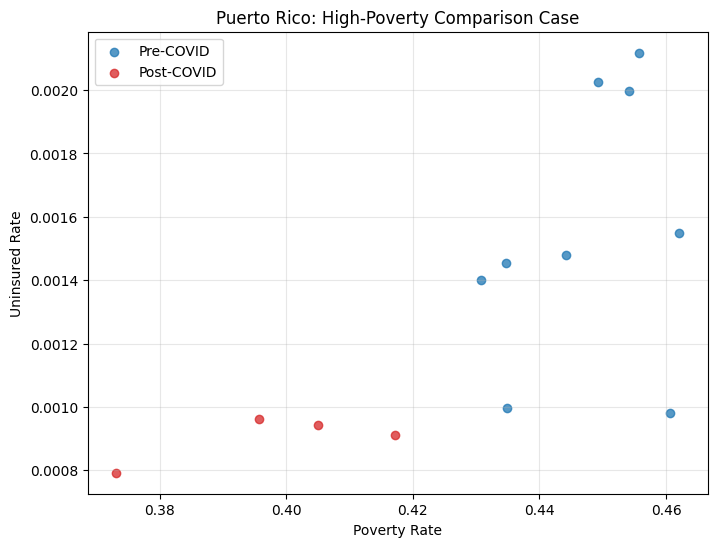

In [100]:
# Separate Puerto Rico plot

puerto_rico_df = plot_df[plot_df["region"] == "Puerto Rico"]

plt.figure(figsize=(8, 6))

for period in ["Pre-COVID", "Post-COVID"]:

    temp = puerto_rico_df[puerto_rico_df["period"] == period]

    plt.scatter(
        temp["poverty_rate"],
        temp["uninsured_rate"],
        alpha=0.75,
        label=period,
        color=period_colors[period]
    )

plt.title("Puerto Rico: High-Poverty Comparison Case")
plt.xlabel("Poverty Rate")
plt.ylabel("Uninsured Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Regional Recovery Patterns Suggest Uneven Social Resilience

Looking at the data regionally makes it clear that the post-COVID recovery did not happen evenly across the country. While household incomes increased across every region during the recovery period, broader measures tied to affordability and social vulnerability improved much more slowly and in some cases remained relatively persistent.

The regional housing burden trends show that affordability pressures remained elevated after COVID-19, especially in the Northeast and West. These regions consistently maintained some of the highest housing cost burden rates throughout the study period despite also reporting the highest average household incomes. This suggests that stronger incomes alone did not necessarily translate into stronger financial stability, particularly in higher-cost housing markets.

The South stood out in a different way. Compared to the other Census regions, Southern states generally experienced higher poverty and uninsured rates across much of the study period. The regional scatterplots also suggest a stronger relationship between poverty and uninsured rates in the South, indicating that economic vulnerability and healthcare access challenges may be more closely connected in the region. Although poverty rates improved somewhat following COVID-19, many states in the region still appeared to experience persistent affordability and healthcare-related vulnerability.

Puerto Rico emerged as a very distinct comparison case throughout the analysis. Even with slight improvements in poverty rates post-COVID, Puerto Rico continued to experience substantially higher poverty levels and much lower household incomes than any of the four major Census regions. At the same time, uninsured rates remained relatively low, likely reflecting differences in public insurance systems and healthcare access. This reinforces the idea that traditional economic indicators alone do not fully capture broader resilience or overall quality of life.

Overall, these findings suggest that economic recovery and broader social resilience do not always move together. Nationally, labor market conditions and household incomes improved following COVID-19, but affordability pressures, healthcare access, and broader vulnerability indicators continued to vary significantly across regions. For public health and economic development organizations, these findings highlight the importance of evaluating recovery through multiple dimensions rather than relying solely on a single economic metric.

## State-Level Change Analysis

Rather than only looking at national and regional averages, this section compares state-level changes between the pre-COVID and post-COVID periods to look deeper into state level impact

In [101]:
# State level change analysis

#groupby state, region and pre/post COVID
#calucate avaerage values for each metric within each period

pre_post_state = (
    acs.groupby(["state_name", "state_abbreviation", "region", "period"])
    .agg(
        #economic indicators
        income=("median_household_income", "mean"),
        poverty_rate=("poverty_rate", "mean"),
        unemployment_rate=("unemployment_rate", "mean"),
        education_rate=("education_rate", "mean"),
        #heathcare access indicaor
        uninsured_rate=("uninsured_rate", "mean"),
        #housing indicators
        cost_burden_rate=("cost_burden_rate", "mean"),
        overcrowding_rate=("overcrowding_rate", "mean"),
        #social indicator
        divorce_rate=("divorce_rate", "mean")
    )
    .reset_index()
)

#create dataframes for pre and post COVID periods
pre = pre_post_state[pre_post_state["period"] == "Pre-COVID"].copy()
post = pre_post_state[pre_post_state["period"] == "Post-COVID"].copy()


# merge pre and post COVID data together so each row contains both pre and post covid data for the state
state_change = pre.merge(post, on=["state_name", "state_abbreviation", "region"],suffixes=("_pre", "_post"))

#caluclate changes for metrics
change_metrics = ["income","poverty_rate","unemployment_rate","education_rate","uninsured_rate","cost_burden_rate","overcrowding_rate","divorce_rate"]

for metric in change_metrics:
    state_change[f"{metric}_change"] = state_change[f"{metric}_post"] - state_change[f"{metric}_pre"]

state_change["income_growth_pct"] = ( state_change["income_change"] / state_change["income_pre"])

#display the 10 states with highest income growth
state_change.sort_values("income_growth_pct", ascending=False).head(10)

,state_name,state_abbreviation,region,period_pre,income_pre,poverty_rate_pre,unemployment_rate_pre,education_rate_pre,uninsured_rate_pre,cost_burden_rate_pre,overcrowding_rate_pre,divorce_rate_pre,period_post,income_post,poverty_rate_post,unemployment_rate_post,education_rate_post,uninsured_rate_post,cost_burden_rate_post,overcrowding_rate_post,divorce_rate_post,income_change,poverty_rate_change,unemployment_rate_change,education_rate_change,uninsured_rate_change,cost_burden_rate_change,overcrowding_rate_change,divorce_rate_change,income_growth_pct
12,Idaho,ID,West,Pre-COVID,"50,262.5556",0.1423,0.0578,0.2653,0.0046,0.4306,0.0213,0.0509,Post-COVID,"73,841.7500",0.1057,0.0338,0.3204,0.0047,0.4433,0.0230,0.0476,"23,579.1944",-0.0365,-0.0240,0.0551,0.0001,0.0127,0.0017,-0.0034,0.4691
2,Arizona,AZ,West,Pre-COVID,"52,893.8889",0.1673,0.0745,0.2830,0.0064,0.4534,0.0308,0.0555,Post-COVID,"75,606.2500",0.1233,0.0469,0.3341,0.0050,0.4921,0.0289,0.0529,"22,712.3611",-0.0440,-0.0276,0.0511,-0.0014,0.0387,-0.0019,-0.0025,0.4294
9,Florida,FL,South,Pre-COVID,"50,045.2222",0.1538,0.0772,0.2833,0.0043,0.5336,0.0206,0.0700,Post-COVID,"70,852.7500",0.1255,0.0453,0.3454,0.0039,0.5680,0.0225,0.0633,"20,807.5278",-0.0283,-0.0319,0.0622,-0.0004,0.0344,0.0019,-0.0067,0.4158
48,Washington,WA,West,Pre-COVID,"65,461.4444",0.1214,0.0643,0.3421,0.0026,0.4632,0.0224,0.0488,Post-COVID,"92,386.7500",0.1005,0.0475,0.3998,0.0016,0.4781,0.0216,0.0453,"26,925.3056",-0.0210,-0.0168,0.0577,-0.0009,0.0150,-0.0007,-0.0035,0.4113
37,Oregon,OR,West,Pre-COVID,"55,519.8889",0.1486,0.0751,0.3199,0.0028,0.4906,0.0232,0.0533,Post-COVID,"78,149.7500",0.1207,0.0489,0.3704,0.0014,0.4955,0.0204,0.0505,"22,629.8611",-0.0280,-0.0262,0.0506,-0.0013,0.0049,-0.0028,-0.0028,0.4076
5,Colorado,CO,West,Pre-COVID,"64,452.1111",0.1156,0.0564,0.3944,0.0036,0.4867,0.0188,0.0439,Post-COVID,"90,395.0000",0.0952,0.0416,0.4613,0.0024,0.5050,0.0156,0.0409,"25,942.8889",-0.0204,-0.0147,0.0669,-0.0012,0.0183,-0.0032,-0.0030,0.4025
4,California,CA,West,Pre-COVID,"66,388.7778",0.1493,0.0801,0.3244,0.0029,0.5307,0.0537,0.0501,Post-COVID,"93,032.0000",0.1207,0.0622,0.3720,0.0017,0.5303,0.0499,0.0472,"26,643.2222",-0.0286,-0.0179,0.0475,-0.0011,-0.0005,-0.0038,-0.0029,0.4013
10,Georgia,GA,South,Pre-COVID,"52,454.2222",0.1680,0.0772,0.2987,0.0052,0.4647,0.0173,0.0552,Post-COVID,"73,504.7500",0.1321,0.0465,0.3526,0.0038,0.4834,0.0170,0.0520,"21,050.5278",-0.0359,-0.0307,0.0539,-0.0013,0.0187,-0.0003,-0.0031,0.4013
45,Utah,UT,West,Pre-COVID,"64,227.8889",0.1110,0.0479,0.3240,0.0075,0.4343,0.0283,0.0366,Post-COVID,"89,674.0000",0.0853,0.0331,0.3806,0.0048,0.4520,0.0228,0.0350,"25,446.1111",-0.0256,-0.0148,0.0566,-0.0027,0.0177,-0.0055,-0.0016,0.3962
26,Montana,MT,West,Pre-COVID,"49,777.8889",0.1426,0.0518,0.3056,0.0050,0.4090,0.0146,0.0596,Post-COVID,"69,256.0000",0.1148,0.0315,0.3509,0.0042,0.3968,0.0123,0.0560,"19,478.1111",-0.0277,-0.0204,0.0452,-0.0008,-0.0122,-0.0023,-0.0037,0.3913


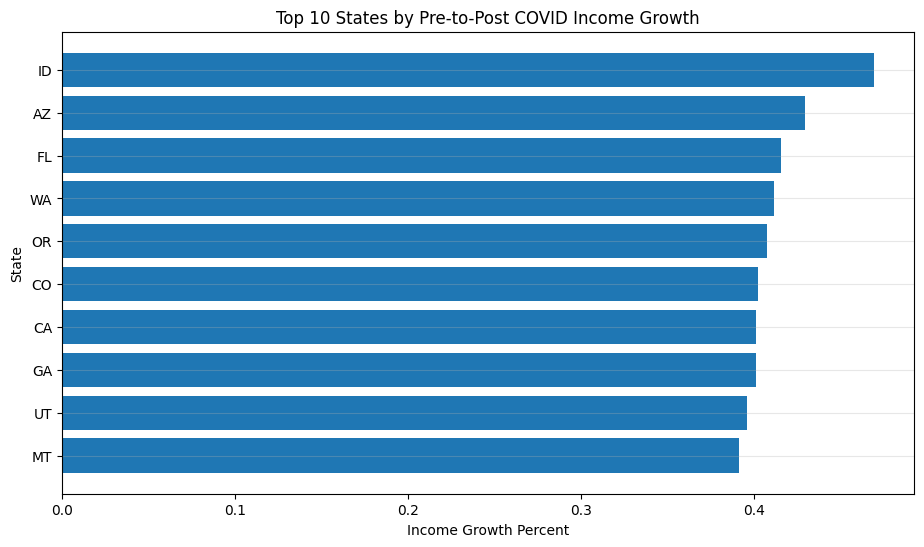

In [102]:
# Chart 7: Top income growth states

#get top income growth states
top_income_growth = state_change.sort_values("income_growth_pct", ascending=False).head(10)

#resort so that the top is at the top of horizontal bar chart
top_income_growth = top_income_growth.sort_values("income_growth_pct",ascending=True)

#plot the data
plt.figure(figsize=(11, 6))

plt.barh(top_income_growth["state_abbreviation"], top_income_growth["income_growth_pct"])

plt.title("Top 10 States by Pre-to-Post COVID Income Growth")
plt.ylabel("State")
plt.xlabel("Income Growth Percent")
plt.grid(axis="y", alpha=0.3)

plt.show()

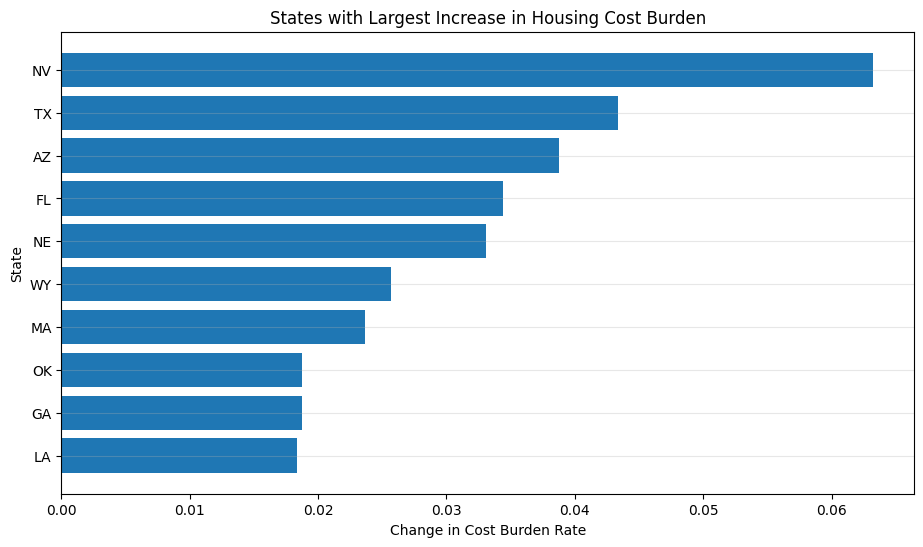

In [103]:
# Chart 8: States with largest increase in housing cost burden

#get states with largest increase
top_housing_stress = state_change.sort_values("cost_burden_rate_change", ascending=False).head(10)

#resort so that the highest values are at the top of the table
top_housing_stress = top_housing_stress.sort_values("cost_burden_rate_change", ascending=True)

plt.figure(figsize=(11, 6))

plt.barh(top_housing_stress["state_abbreviation"], top_housing_stress["cost_burden_rate_change"])

plt.title("States with Largest Increase in Housing Cost Burden")
plt.ylabel("State")
plt.xlabel("Change in Cost Burden Rate")
plt.grid(axis="y", alpha=0.3)

plt.show()

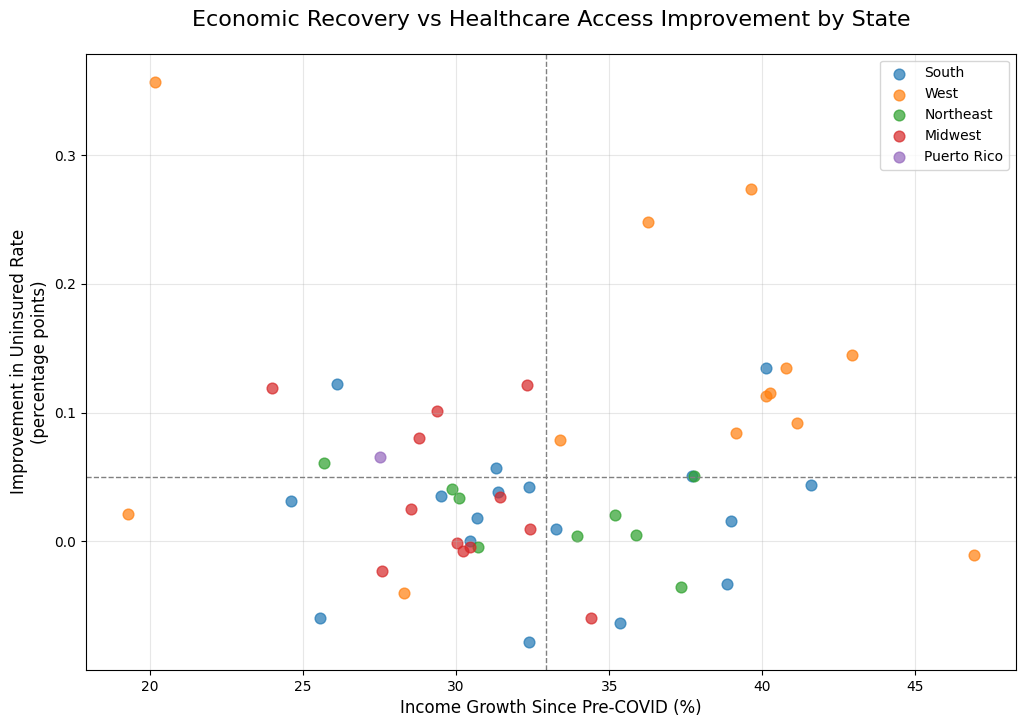

In [104]:
# Recovery quadrant chart

plt.figure(figsize=(12, 8))

# Plot by region
for region in state_change["region"].unique():

    temp = state_change[state_change["region"] == region]

    plt.scatter(
        temp["income_growth_pct"] * 100,
        -temp["uninsured_rate_change"] * 100,
        alpha=0.7,
        s=60,
        label=region,
        color=region_colors[region]
    )

# Average reference lines
x_avg = (state_change["income_growth_pct"] * 100).mean()
y_avg = (-state_change["uninsured_rate_change"] * 100).mean()

plt.axhline(y_avg,linestyle="--",color="gray",linewidth=1)
plt.axvline(x_avg,linestyle="--",color="gray",linewidth=1)
plt.title("Economic Recovery vs Healthcare Access Improvement by State",fontsize=16,pad=20)
plt.xlabel("Income Growth Since Pre-COVID (%)",fontsize=12)
plt.ylabel("Improvement in Uninsured Rate\n(percentage points)",fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Economic Recovery and Healthcare Access Did Not Improve Equally Across States

This chart helps show that post-COVID recovery looked very different depending on what outcome was being measured. While many states experienced strong household income growth following COVID-19, improvements in healthcare access were much more uneven.

States farther to the right on the chart generally experienced stronger economic recovery through higher income growth, while states higher on the chart saw larger improvements in uninsured rates. What stood out most was that those two outcomes did not always move together. Some states experienced strong economic gains but relatively limited improvement in healthcare access, while others made larger improvements in uninsured rates despite more moderate income growth.

The West appeared to experience some of the strongest overall recovery patterns, with many Western states clustering in the upper-right portion of the chart. In contrast, Southern states appeared more spread out, suggesting a less consistent relationship between economic recovery and healthcare access improvements across the region.

Overall, this chart highlights one of the main themes that kept appearing throughout the project: recovery after COVID-19 was multidimensional. Improvements in income, affordability, healthcare access, and broader social vulnerability did not happen at the same pace everywhere, and looking at only one metric would miss a large part of the story.

## Composite Social Resilience Index

To compare states across multiple indicators, this analysis creates a composite Social Resilience Index. The index rewards higher income and education while penalizing higher poverty, unemployment, uninsured rates, housing burden, overcrowding, divorce, and separation.

This is not intended to be a perfect measure of resilience. Instead, it is a transparent, interpretable framework for comparing relative state performance across several social and economic dimensions.

In [105]:
# 7. Social resillience index
# Make a copy so we preserve the original dataframe
index_df = acs.copy()

# Positive indicators where higher values suggest stronger resilience
positive_cols = ["median_household_income","education_rate"]

# Negative indicators where higher values suggest more social/economic stress
negative_cols = ["poverty_rate","unemployment_rate","uninsured_rate","cost_burden_rate","overcrowding_rate"]

# Standardize each variable so all indicators are on the same scale
for col in positive_cols + negative_cols:
    index_df[col + "_z"] = (index_df[col] - index_df[col].mean()) / index_df[col].std()

# combine positive indicators into one score
index_df["positive_resilience_score"] = (index_df[[col + "_z" for col in positive_cols]].mean(axis=1))

# combine the negative indicators into one stress score
index_df["negative_stress_score"] = (index_df[[col + "_z" for col in negative_cols]].mean(axis=1))

# Final index:
# higher positive score and lower stress score = stronger resilience
index_df["social_resilience_index"] = (index_df["positive_resilience_score"] -index_df["negative_stress_score"])

# Save the updated dataframe back to my original dataframe with the new columns
acs = index_df.copy()

# Rank states by average resilience across the full study period
resilience_by_state = (acs.groupby(["state_name", "state_abbreviation", "region"]).agg(avg_resilience=("social_resilience_index", "mean")).reset_index().sort_values("avg_resilience", ascending=False))

resilience_by_state.head(10)

,state_name,state_abbreviation,region,avg_resilience
8,District of Columbia,DC,South,2.6554
21,Massachusetts,MA,Northeast,1.8214
29,New Hampshire,NH,Northeast,1.5997
20,Maryland,MD,South,1.4841
6,Connecticut,CT,Northeast,1.2139
47,Virginia,VA,South,1.1735
30,New Jersey,NJ,Northeast,1.1490
46,Vermont,VT,Northeast,1.1445
5,Colorado,CO,West,1.0664
23,Minnesota,MN,Midwest,1.0114


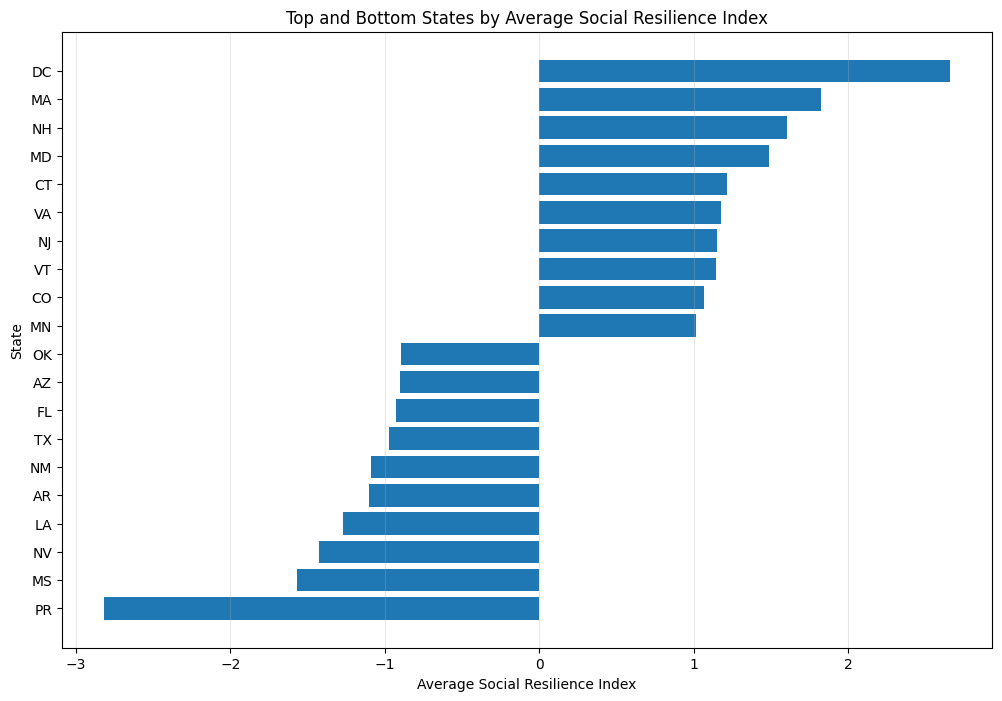

In [106]:
# Chart 10: Top and bottom resilience states

top_bottom_resilience = pd.concat([resilience_by_state.head(10),resilience_by_state.tail(10)])
top_bottom_resilience =top_bottom_resilience.sort_values( "avg_resilience",ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(top_bottom_resilience["state_abbreviation"],top_bottom_resilience["avg_resilience"])

plt.title("Top and Bottom States by Average Social Resilience Index")
plt.xlabel("Average Social Resilience Index")
plt.ylabel("State")
plt.grid(axis="x", alpha=0.3)

plt.show()

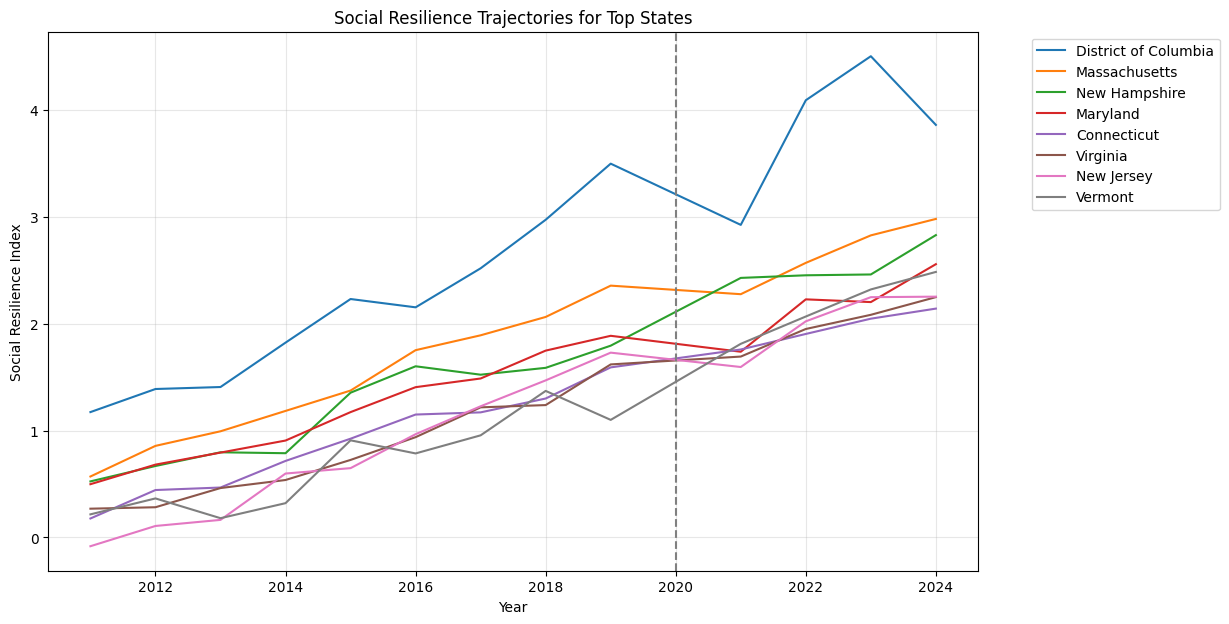

In [107]:
# Chart 11: Resilience trend for top states

top_states = resilience_by_state.head(8)["state_name"]

plt.figure(figsize=(12, 7))

for state in top_states:
    temp = acs[acs["state_name"] == state].sort_values("year")
    plt.plot(temp["year"],temp["social_resilience_index"],label=state)

plt.axvline(2020, linestyle="--", color="gray")
plt.title("Social Resilience Trajectories for Top States")
plt.xlabel("Year")
plt.ylabel("Social Resilience Index")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.show()

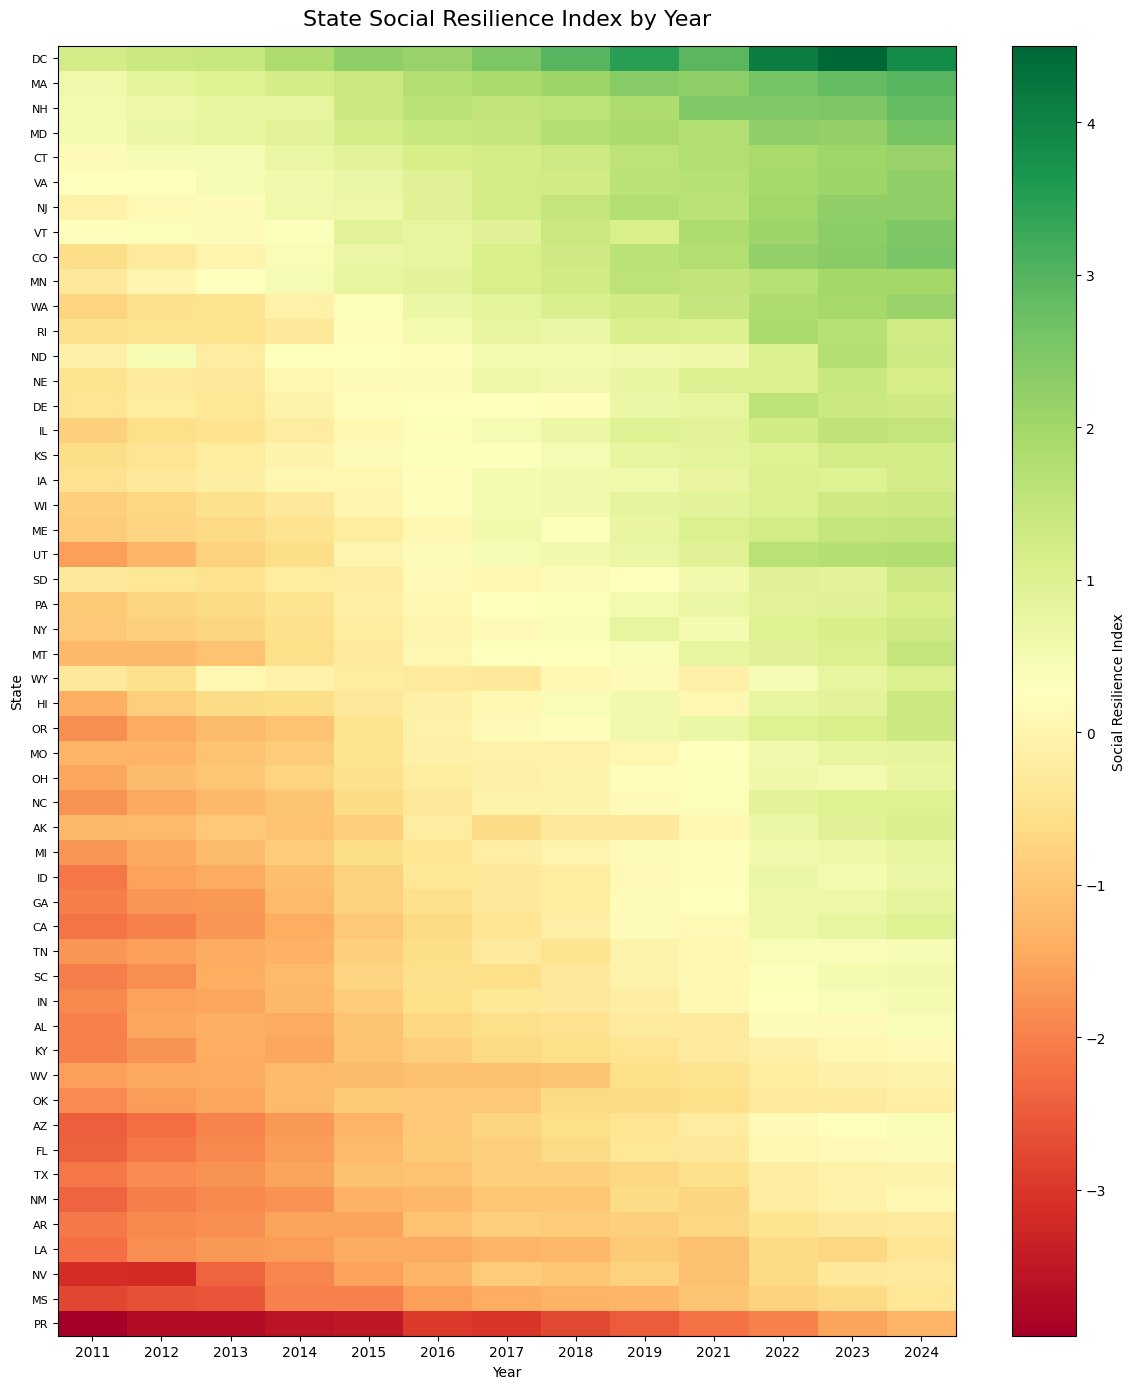

In [108]:
# Chart 12: Heatmap-style state-year resilience matrix using matplotlib

# Create heatmap dataframe
heatmap_df = acs.pivot_table(index="state_abbreviation",columns="year",values="social_resilience_index")

# Sort states by average resilience
heatmap_df["avg_resilience"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values("avg_resilience",ascending=False)

# Remove helper column
heatmap_df = heatmap_df.drop(columns="avg_resilience")

# Create figure
plt.figure(figsize=(12, 14))

plt.imshow(heatmap_df,aspect="auto",cmap="RdYlGn")   # red = lower resilience, green = higher)
plt.colorbar(label="Social Resilience Index")
plt.xticks(range(len(heatmap_df.columns)),heatmap_df.columns)
plt.yticks(range(len(heatmap_df.index)),heatmap_df.index,fontsize=8)
plt.title("State Social Resilience Index by Year",fontsize=16,pad=15)
plt.xlabel("Year")
plt.ylabel("State")
plt.tight_layout()

plt.show()

### The Social Resilience Index Shows That Recovery Looked Very Different Across States

To better understand how resilience changed over time, I created a Social Resilience Index that combines indicators tied to economic stability, healthcare access, and housing-related stress. Instead of focusing on a single variable, the index brings together income, education, poverty, unemployment, uninsured rates, housing cost burden, and overcrowding to get a broader picture of how states were performing socially and economically throughout the study period.

A few patterns stood out pretty quickly. States in the Northeast and the DC area consistently ranked near the top of the index across most years, while many Southern states remained toward the lower end even as overall national conditions improved. The heatmap also shows a broader national trend where many states gradually shift from darker reds and oranges into lighter yellow and green tones over time, suggesting gradual improvement in overall resilience across much of the country.

Puerto Rico continued to stand out as a very different comparison case throughout the analysis. Even though conditions improved somewhat over time, Puerto Rico consistently remained well below most states in overall resilience levels, reinforcing earlier findings that its economic and social challenges looked very different from the mainland United States.

Overall, this visualization helps reinforce one of the biggest themes of the project: resilience is multidimensional and highly uneven across geography. While many states improved over time, the pace and consistency of those improvements varied significantly across the country.

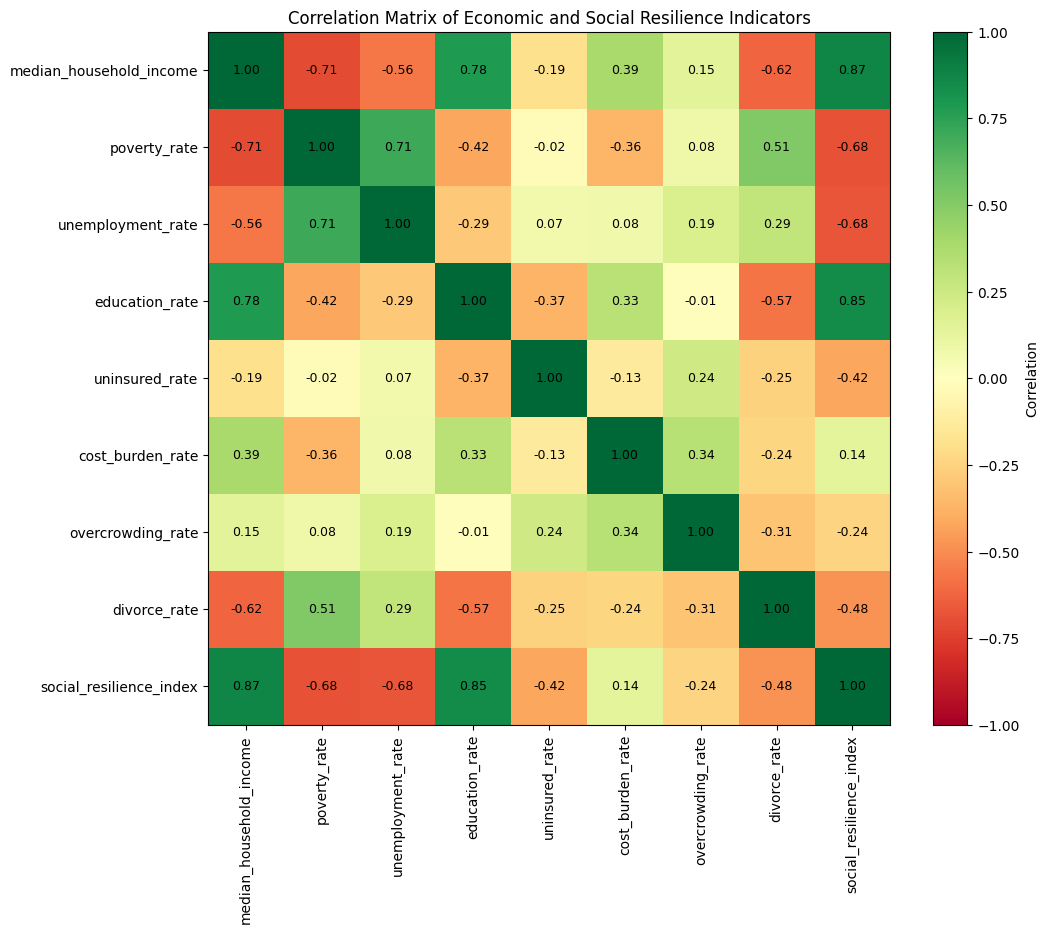

In [109]:
# Chart 13: Correlation matrix using matplotlib

corr_cols = [
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "education_rate",
    "uninsured_rate",
    "cost_burden_rate",
    "overcrowding_rate",
    "divorce_rate",
    "social_resilience_index"
]

corr = acs[corr_cols].corr()
plt.figure(figsize=(11, 9))
plt.imshow(corr, aspect="auto", cmap="RdYlGn",vmin=-1,vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
# Add correlation values inside cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j,i,f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9, color="black")
plt.title("Correlation Matrix of Economic and Social Resilience Indicators")
plt.show()


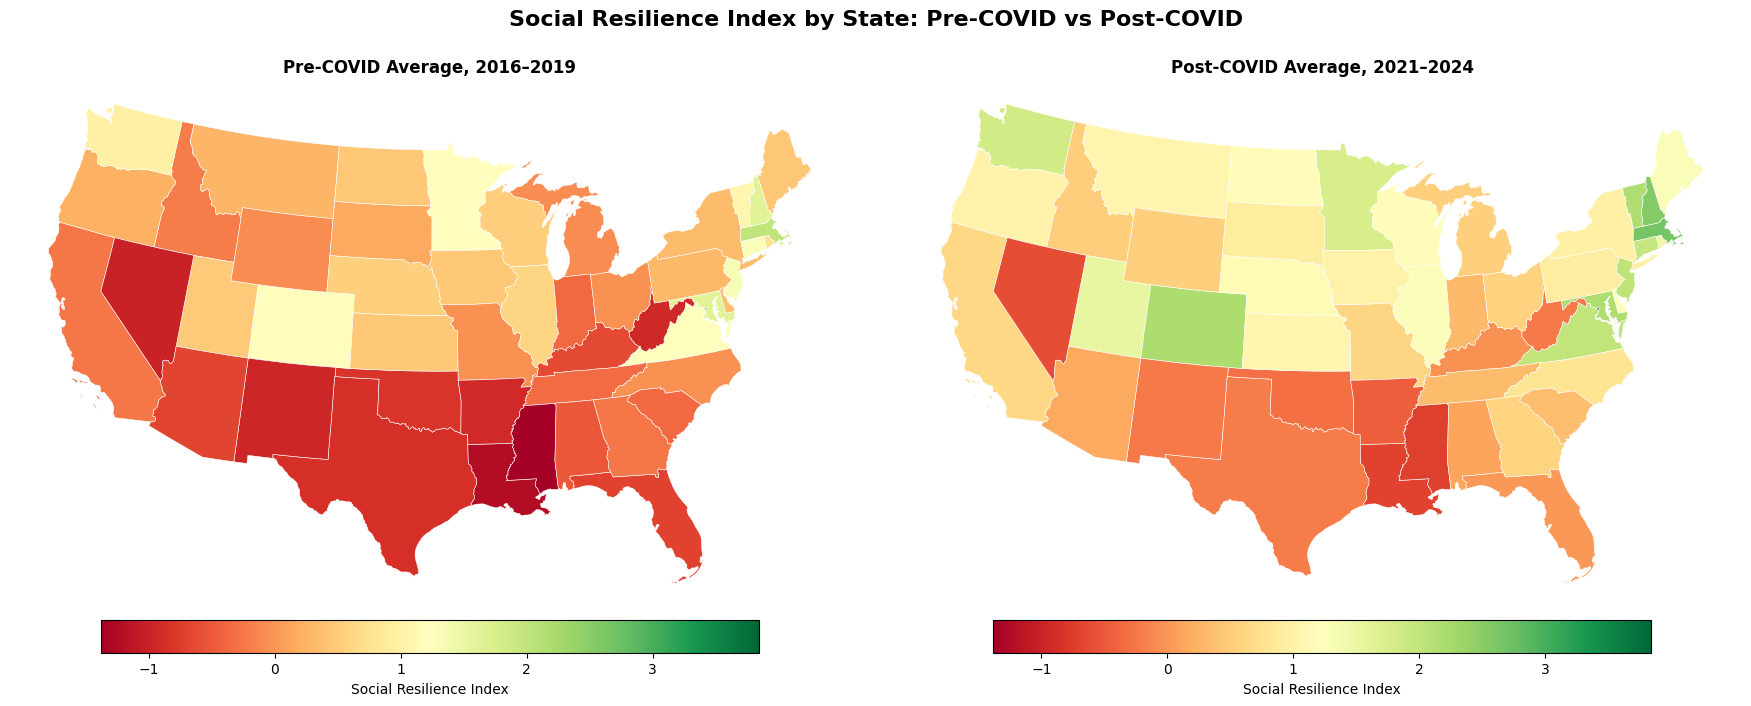

In [110]:
# Social Resilience index by state choropleth map

# Create pre-COVID and post-COVID resilience averages

pre_covid = (
    acs[acs["year"].between(2016, 2019)]
    .groupby(["state_name", "state_abbreviation"])["social_resilience_index"]
    .mean()
    .reset_index()
    .rename(columns={"social_resilience_index": "pre_covid_resilience"})
)

post_covid = (
    acs[acs["year"].between(2021, 2024)]
    .groupby(["state_name", "state_abbreviation"])["social_resilience_index"]
    .mean()
    .reset_index()
    .rename(columns={"social_resilience_index": "post_covid_resilience"})
)

# Load state map and merge data

states_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_state_20m.zip"
states_gdf = gpd.read_file(states_url)

states_df = pd.DataFrame(states_gdf)

map_df = pd.merge(states_df, pre_covid, left_on="STUSPS", right_on="state_abbreviation", how="left")
map_df = pd.merge( map_df, post_covid, left_on="STUSPS", right_on="state_abbreviation", how="left", suffixes=("_pre", "_post"))
map_df = gpd.GeoDataFrame(map_df, geometry="geometry", crs=states_gdf.crs)

# contiguous U.S. only
map_df = map_df[~map_df["STUSPS"].isin(["AK", "HI", "PR", "VI", "GU", "MP", "AS"])].copy()
map_df = map_df.to_crs("ESRI:102003")

# Set shared color scale

vmin = min(map_df["pre_covid_resilience"].min(), map_df["post_covid_resilience"].min())
vmax = max(map_df["pre_covid_resilience"].max(),map_df["post_covid_resilience"].max())

# Plot side-by-side maps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

fig.suptitle("Social Resilience Index by State: Pre-COVID vs Post-COVID",fontsize=16,fontweight="bold",y=1.03)

# Pre-COVID map
map_df.plot(
    column="pre_covid_resilience",
    cmap="RdYlGn",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    legend_kwds={
        "label": "Social Resilience Index",
        "orientation": "horizontal",
        "shrink": 0.75,
        "pad": 0.02
    },
    ax=axes[0]
)

axes[0].set_title("Pre-COVID Average, 2016–2019", fontsize=12, fontweight="bold")

axes[0].set_axis_off()

# Post-COVID map
map_df.plot(
    column="post_covid_resilience",
    cmap="RdYlGn",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    legend_kwds={
        "label": "Social Resilience Index",
        "orientation": "horizontal",
        "shrink": 0.75,
        "pad": 0.02
    },
    ax=axes[1]
)

axes[1].set_title("Post-COVID Average, 2021–2024", fontsize=12, fontweight="bold")

axes[1].set_axis_off()

plt.tight_layout()
plt.show()

### The Correlation Matrix Helps Show Which Indicators Tend to Move Together

The correlation matrix helps tie together many of the patterns that appeared throughout the earlier analysis. Overall, states with higher household incomes and stronger education outcomes also tended to have higher Social Resilience Index scores, while higher poverty and unemployment rates were strongly associated with lower resilience.

One of the clearest relationships was between income, education, and resilience, suggesting that states with stronger long-term economic and educational conditions generally experienced better overall social outcomes. Poverty and unemployment also showed a strong positive relationship with each other, reinforcing how closely connected different forms of economic vulnerability can be.

One interesting finding was that housing cost burden did not follow the same pattern as some of the other variables. Several higher-income and higher-resilience states still experienced relatively high housing burden rates, which supports earlier findings that stronger incomes do not necessarily eliminate affordability pressures, especially in more expensive housing markets.

Overall, the matrix helped validate many of the broader trends that appeared throughout the project and reinforced that resilience is shaped by multiple interconnected social and economic factors rather than a single variable alone.

## SQLite Analysis in Python

This section creates a SQLite database from the cleaned ACS dataset and runs a set of SQL queries directly in Python.

These SQL queries are designed to support the same analytical story as the Python EDA: state-level resilience, regional variation, pre/post change, and social vulnerability.

In [111]:
# sqlite setup
conn = sqlite3.connect("social_resilience.db")

acs.to_sql("acs", conn, if_exists="replace", index=False)
state_change.to_sql("state_change", conn, if_exists="replace", index=False)

#create function to run my queries
def run_query(query):
    return pd.read_sql_query(query, conn)

In [112]:
# Query 1: Preview cleaned ACS table
q1 = '''SELECT * FROM acs LIMIT 10;'''

run_query(q1)

,state_name,total_population,median_household_income,population_below_poverty,poverty_universe,bachelors_degree,masters_degree,professional_degree,doctorate_degree,education_universe,median_home_value,median_rent,employed,unemployed,labor_force,population_15_plus,never_married_male,never_married_female,married_male,married_female,separated_male,separated_female,divorced_male,divorced_female,widowed_male,widowed_female,spouse_absent_male,spouse_absent_female,insurance_universe,uninsured_male,uninsured_female,private_insurance,public_insurance,occupied_units,owner_occupied_units,renter_occupied_units,avg_owner_household_size,avg_renter_household_size,vacant_units,rent_30_34_pct_income,rent_35_39_pct_income,rent_40_49_pct_income,rent_50_plus_pct_income,overcrowded_owner_units,overcrowded_renter_units,workers_16_plus,work_from_home,public_transit_commuters,aggregate_travel_time,commuters_16_plus,state,year,state_abbreviation,region,period,poverty_rate,unemployment_rate,bachelors_plus,education_rate,rent_to_income_ratio,never_married_rate,married_rate,divorce_rate,separation_rate,widowed_rate,spouse_absent_rate,uninsured_rate,private_public_insurance_ratio,renter_rate,cost_burdened_renter_units,cost_burden_rate,overcrowding_rate,remote_work_rate,public_transit_rate,mean_commute_time,median_household_income_z,education_rate_z,poverty_rate_z,unemployment_rate_z,uninsured_rate_z,cost_burden_rate_z,overcrowding_rate_z,positive_resilience_score,negative_stress_score,social_resilience_index
0,Alabama,"4,802,740.0000","41,415.0000","892,483.0000","4,687,363.0000","443,488.0000","190,977.0000","43,117.0000","32,950.0000","3,193,078.0000","122,700.0000",687.0000,"2,240,441.0000","259,346.0000","2,255,995.0000","3,874,758.0000","596,130.0000","529,806.0000","911,542.0000","901,278.0000","40,483.0000","63,147.0000","53,094.0000","219,928.0000","43,436.0000","36,513.0000","83,919.0000","99,660.0000","4,720,067.0000","7,693.0000","7,790.0000","185,616.0000","185,616.0000","1,844,546.0000","1,289,217.0000","555,329.0000",2.5700,2.4700,"337,653.0000","44,984.0000","35,018.0000","45,745.0000","133,883.0000","10,682.0000","15,295.0000","1,953,274.0000","51,126.0000","9,329.0000","45,529,580.0000","1,902,148.0000",1,2011,AL,South,Pre-COVID,0.1904,0.1150,"710,532.0000",0.2225,0.1991,0.2906,0.4679,0.0705,0.0267,0.0206,0.0474,0.0033,1.0000,0.3011,"259,630.0000",0.4675,0.0141,0.0262,0.0048,23.9359,-1.3405,-1.4059,0.9603,2.1657,-0.0684,0.4616,-0.4891,-1.3732,0.6060,-1.9792
1,Alaska,"722,718.0000","67,825.0000","73,905.0000","706,860.0000","77,153.0000","29,269.0000","8,000.0000","6,039.0000","456,862.0000","238,300.0000","1,049.0000","377,710.0000","33,367.0000","394,406.0000","565,162.0000","105,171.0000","77,471.0000","129,991.0000","129,759.0000","5,827.0000","5,828.0000","5,370.0000","15,959.0000","12,546.0000","7,177.0000","18,373.0000","13,005.0000","699,272.0000","3,742.0000","2,602.0000","33,525.0000","33,525.0000","257,330.0000","162,312.0000","95,018.0000",2.7900,2.5700,"53,852.0000","8,235.0000","6,387.0000","7,073.0000","16,881.0000","5,934.0000","5,404.0000","348,777.0000","16,875.0000","6,474.0000","6,102,335.0000","331,902.0000",2,2011,AK,West,Pre-COVID,0.1046,0.0846,"120,461.0000",0.2637,0.1856,0.3232,0.4596,0.0377,0.0206,0.0349,0.0555,0.0091,1.0000,0.3692,"38,576.0000",0.4060,0.0441,0.0484,0.0186,18.3860,0.3848,-0.8074,-0.7041,0.9763,3.0151,-0.8551,2.5975,-0.2113,1.0060,-1.2173
2,Arizona,"6,482,505.0000","46,709.0000","1,203,501.0000","6,336,449.0000","719,546.0000","291,892.0000","64,212.0000","43,548.0000","4,211,223.0000","153,800.0000",850.0000,"3,025,208.0000","337,217.0000","3,040,762.0000","5,129,409.0000","907,782.0000","740,052.0000","1,157,394.0000","1,133,403.0000","44,118.0000","58,280.0000","67,841.0000","218,334.0000","84,800.0000","71,717.0000","128,918.0000","129,997.0000","6,378,280.0000","32,064.0000","24,287.0000","273,955.0000","273,955.0000","2,356,055.0000","1,501,528.0000","854,527.0000",2.6700,2.7200,"508,305.0000

In [113]:
# Query 2: Count observations by year
q2 = '''SELECT year, COUNT(*) AS row_count, COUNT(DISTINCT state_name) 
            AS unique_states
                FROM acs
                    GROUP BY year
                        ORDER BY year;'''

run_query(q2)

,year,row_count,unique_states
0,2011,52,52
1,2012,52,52
2,2013,52,52
3,2014,52,52
4,2015,52,52
5,2016,52,52
6,2017,52,52
7,2018,52,52
8,2019,52,52
9,2021,52,52


All years have 52 inputs for the 50 states + DC and PR

In [114]:
# Query 3: Average economic conditions by period
q3 = '''SELECT period, AVG(median_household_income) AS avg_income, AVG(poverty_rate) AS avg_poverty_rate, AVG(unemployment_rate) AS avg_unemployment_rate
            FROM acs
                GROUP BY period;'''

run_query(q3)

,period,avg_income,avg_poverty_rate,avg_unemployment_rate
0,Post-COVID,"74,707.8029",0.1282,0.0453
1,Pre-COVID,"56,256.9829",0.1465,0.0661


In [115]:
# Query 4: Average social conditions by period
q4 = '''SELECT period, AVG(uninsured_rate) AS avg_uninsured_rate, AVG(cost_burden_rate) AS avg_cost_burden_rate, AVG(overcrowding_rate) AS avg_overcrowding_rate, AVG(divorce_rate) AS avg_divorce_rate
            FROM acs
                GROUP BY period;'''

run_query(q4)

,period,avg_uninsured_rate,avg_cost_burden_rate,avg_overcrowding_rate,avg_divorce_rate
0,Post-COVID,0.0031,0.4513,0.0182,0.0558
1,Pre-COVID,0.0036,0.4436,0.0191,0.0588


In [116]:
# Query 5: Join pre and post poverty by state

q5 = '''
SELECT pre.state_abbreviation, AVG(pre.poverty_rate) AS pre_poverty_rate, AVG(post.poverty_rate) AS post_poverty_rate, AVG(post.poverty_rate) - AVG(pre.poverty_rate) AS poverty_rate_change
    FROM acs AS pre
        JOIN acs AS post ON pre.state_abbreviation = post.state_abbreviation
            WHERE pre.period = 'Pre-COVID' AND post.period = 'Post-COVID'
                GROUP BY pre.state_abbreviation
                    ORDER BY poverty_rate_change DESC;'''

run_query(q5)

,state_abbreviation,pre_poverty_rate,post_poverty_rate,poverty_rate_change
0,AK,0.1038,0.1050,0.0012
1,HI,0.1039,0.1037,-0.0002
2,MD,0.0969,0.0961,-0.0008
3,WY,0.1121,0.1113,-0.0009
4,ND,0.1112,0.1087,-0.0025
5,CT,0.1038,0.1010,-0.0028
6,NJ,0.1040,0.0971,-0.0069
7,LA,0.1968,0.1894,-0.0074
8,MA,0.1098,0.1022,-0.0076
9,IA,0.1194,0.1118,-0.0076


In [117]:
# Query 6: Join pre and post uninsured rates by state
q6 = '''SELECT pre.state_abbreviation, AVG(pre.uninsured_rate) AS pre_uninsured_rate, AVG(post.uninsured_rate) AS post_uninsured_rate, AVG(post.uninsured_rate) - AVG(pre.uninsured_rate) AS uninsured_rate_change
            FROM acs AS pre
                JOIN acs AS post ON pre.state_abbreviation = post.state_abbreviation
                    WHERE pre.period = 'Pre-COVID' AND post.period = 'Post-COVID'
                        GROUP BY pre.state_abbreviation
                            ORDER BY uninsured_rate_change DESC;'''

run_query(q6)

,state_abbreviation,pre_uninsured_rate,post_uninsured_rate,uninsured_rate_change
0,AR,0.0034,0.0042,0.0008
1,DC,0.0013,0.0019,0.0006
2,MD,0.0023,0.0029,0.0006
3,SD,0.0045,0.0051,0.0006
4,HI,0.0017,0.0021,0.0004
5,VT,0.0011,0.0015,0.0004
6,TN,0.0030,0.0034,0.0003
7,IA,0.0024,0.0026,0.0002
8,ID,0.0046,0.0047,0.0001
9,IL,0.0020,0.0020,0.0001


In [118]:
# Query 7: average resilience and income by state
q7='''SELECT state_abbreviation, AVG(social_resilience_index) AS avg_resilience, AVG(median_household_income) AS avg_income
        FROM acs
            GROUP BY state_abbreviation
                ORDER BY avg_resilience DESC;'''
run_query(q7)

,state_abbreviation,avg_resilience,avg_income
0,DC,2.6554,"83,764.1538"
1,MA,1.8214,"80,148.6923"
2,NH,1.5997,"76,870.0000"
3,MD,1.4841,"83,069.6154"
4,CT,1.2139,"77,247.4615"
5,VA,1.1735,"73,460.9231"
6,NJ,1.1490,"81,911.7692"
7,VT,1.1445,"62,986.3846"
8,CO,1.0664,"72,434.5385"
9,MN,1.0114,"70,206.6923"


In [119]:
# Query 8: Window function ranking states by resilience within each year
q8 = ''' SELECT year, state_abbreviation, social_resilience_index, RANK() OVER (PARTITION BY year 
            ORDER BY social_resilience_index DESC) AS yearly_resilience_rank
                FROM acs
                    ORDER BY year, yearly_resilience_rank;'''

run_query(q8)

,year,state_abbreviation,social_resilience_index,yearly_resilience_rank
0,2011,DC,1.1722,1
1,2011,MA,0.5700,2
2,2011,NH,0.5242,3
3,2011,MD,0.4980,4
4,2011,VA,0.2690,5
...,...,...,...,...
671,2024,NV,-0.2757,48
672,2024,AR,-0.2804,49
673,2024,MS,-0.3573,50
674,2024,LA,-0.4068,51


In [120]:
# Query 9: Window function calculating year-over-year income change
q9 = '''SELECT state_abbreviation, year, median_household_income, median_household_income - LAG(median_household_income) 
            OVER (PARTITION BY state_abbreviation ORDER BY year) AS income_change_from_prior_year
                FROM acs
                    ORDER BY state_abbreviation, year;'''

run_query(q9)

,state_abbreviation,year,median_household_income,income_change_from_prior_year
0,AK,2011,"67,825.0000",NaN
1,AK,2012,"67,712.0000",-113.0000
2,AK,2013,"72,237.0000","4,525.0000"
3,AK,2014,"71,583.0000",-654.0000
4,AK,2015,"73,355.0000","1,772.0000"
...,...,...,...,...
671,WY,2019,"65,003.0000","3,419.0000"
672,WY,2021,"65,204.0000",201.0000
673,WY,2022,"70,042.0000","4,838.0000"
674,WY,2023,"72,415.0000","2,373.0000"


In [121]:
# Query 10: Subquery for above-average poverty
q10 = '''SELECT state_abbreviation, year, poverty_rate
            FROM acs
                WHERE poverty_rate > ( SELECT AVG(poverty_rate) FROM acs)
                    ORDER BY poverty_rate DESC;'''

run_query(q10)

,state_abbreviation,year,poverty_rate
0,PR,2014,0.4621
1,PR,2015,0.4606
2,PR,2011,0.4558
3,PR,2013,0.4542
4,PR,2012,0.4493
...,...,...,...
248,MI,2017,0.1416
249,WA,2013,0.1415
250,ME,2014,0.1413
251,ME,2011,0.1413


In [122]:
# Query 11: Subquery for above-average housing burden
q11 = ''' SELECT state_abbreviation, year, cost_burden_rate
            FROM acs
                WHERE cost_burden_rate > ( SELECT AVG(cost_burden_rate)FROM acs )
                    ORDER BY cost_burden_rate DESC;'''

run_query(q11)

,state_abbreviation,year,cost_burden_rate
0,FL,2024,0.5814
1,FL,2023,0.5788
2,FL,2022,0.5627
3,FL,2011,0.5619
4,NV,2024,0.5491
...,...,...,...
359,TN,2023,0.4470
360,PA,2022,0.4468
361,MO,2013,0.4465
362,MI,2017,0.4465


In [123]:
# Query 12: Regional resilience ranking
q12 = '''
SELECT
    region,
    AVG(social_resilience_index) AS avg_resilience,
    AVG(uninsured_rate) AS avg_uninsured_rate,
    AVG(cost_burden_rate) AS avg_cost_burden_rate
FROM acs
GROUP BY region
ORDER BY avg_resilience DESC;
'''

run_query(q12)

,region,avg_resilience,avg_uninsured_rate,avg_cost_burden_rate
0,Northeast,0.8989,0.0020,0.4722
1,Midwest,0.2033,0.0035,0.4202
2,West,-0.1948,0.0045,0.4598
3,South,-0.3047,0.0034,0.4482
4,Puerto Rico,-2.8167,0.0014,0.3011


## Modeling

The models created are not intended to produce perfect predictions but rather help test whether the engineered features are meaningfully related to the outcomes that matter to our target audience.

We created two models:

1. A linear regression model predicting uninsured rate.
2. A logistic regression model predicting whether a state-year has above-median social resilience.

Both models use engineered indicators developed earlier in the analysis.

In [124]:
# 9. MODEL 1: Linear regression
# Predict uninsured rate

linear_model_df = acs.copy()

X = linear_model_df[[ "poverty_rate", "unemployment_rate", "education_rate", "median_household_income", "rent_to_income_ratio", "cost_burden_rate", "overcrowding_rate"]]

y = linear_model_df["uninsured_rate"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

linear_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R-squared"],
    "value": [
        mean_absolute_error(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred)),
        r2_score(y_test, y_pred)
    ]
})

linear_metrics

,metric,value
0,MAE,0.0013
1,RMSE,0.0017
2,R-squared,0.2243


In [125]:
linear_coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": linear_model.coef_
}).sort_values("coefficient", ascending=False)

linear_coefficients

,feature,coefficient
6,overcrowding_rate,0.0819
1,unemployment_rate,0.0226
3,median_household_income,0.0000
5,cost_burden_rate,-0.0086
2,education_rate,-0.0108
0,poverty_rate,-0.0115
4,rent_to_income_ratio,-0.0178


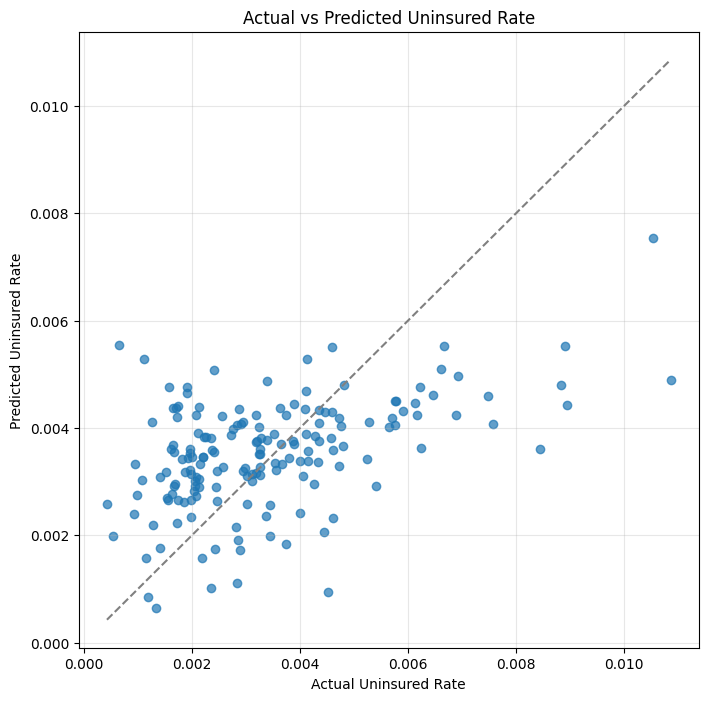

In [126]:
# Chart 14: Actual vs predicted uninsured rate

plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="gray")

plt.title("Actual vs Predicted Uninsured Rate")
plt.xlabel("Actual Uninsured Rate")
plt.ylabel("Predicted Uninsured Rate")
plt.grid(alpha=0.3)

plt.show()

### The Linear Regression Model Captured General Trends but Has Limited Predictive Strength

The actual vs predicted uninsured rate plot suggests that the linear regression model was able to capture some of the broader directional patterns in the data, but overall predictive performance remained fairly limited. While there is still a general upward relationship between actual and predicted uninsured rates, many observations remain dispersed around the perfect prediction reference line.

The model produced an R-squared value of approximately 0.22, meaning the model explained about 22% of the variation in uninsured rates across state-years. This suggests that although the engineered socioeconomic features are related to healthcare access outcomes, a large portion of the variation is still being driven by additional factors not fully captured in the dataset.

At the same time, the MAE and RMSE values remained relatively small in absolute terms because uninsured rates themselves are measured on a fairly small scale. Overall, the model is best interpreted as an explanatory tool used to evaluate broader relationships between socioeconomic conditions and healthcare access rather than as a highly accurate forecasting model.

In [127]:
# 10. Model 2: Logistic regression
# Predict high social resilience

acs["high_resilience"] = (acs["social_resilience_index"] > acs["social_resilience_index"].median()).astype(int)
logit_df = acs.copy()
X = logit_df[[ "poverty_rate", "unemployment_rate", "education_rate", "uninsured_rate", "cost_burden_rate", "overcrowding_rate", "divorce_rate"]]
y = logit_df["high_resilience"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_train_scaled, y_train)

y_pred = logit_model.predict(X_test_scaled)

logit_metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

logit_metrics

,metric,value
0,Accuracy,0.9290
1,Precision,0.9091
2,Recall,0.9524
3,F1 Score,0.9302


In [128]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Confusion Matrix
[[77  8]
 [ 4 80]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        85
           1       0.91      0.95      0.93        84

    accuracy                           0.93       169
   macro avg       0.93      0.93      0.93       169
weighted avg       0.93      0.93      0.93       169



In [129]:
logit_coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logit_model.coef_[0]
}).sort_values("coefficient", ascending=False)

logit_coefficients

,feature,coefficient
2,education_rate,3.9517
6,divorce_rate,-0.3220
4,cost_burden_rate,-0.4441
5,overcrowding_rate,-0.8506
3,uninsured_rate,-1.3018
1,unemployment_rate,-2.0588
0,poverty_rate,-2.6508


### The Logistic Regression Model Helped Identify Which Factors Were Most Associated With Higher Resilience

The logistic regression model performed much more strongly than the linear regression model and was able to classify above- versus below-median resilience outcomes with relatively high accuracy. Looking at the model coefficients also helped highlight which variables appeared to have the strongest relationship with overall resilience.

Education rate had the strongest positive relationship with resilience by a fairly large margin. States with higher educational attainment were much more likely to be classified as higher-resilience observations, reinforcing a pattern that appeared consistently throughout the earlier analysis. This suggests that education may play an important role in broader economic stability, healthcare access, and long-term social resilience.

On the other hand, poverty rate and unemployment rate showed some of the strongest negative relationships with resilience. Higher levels of economic vulnerability were strongly associated with lower resilience outcomes overall, which aligns closely with many of the earlier regional and correlation findings. Uninsured rates, housing cost burden, and overcrowding also showed negative relationships with resilience, although the strength of those relationships was more moderate.

Overall, the model reinforces one of the biggest themes that emerged throughout the project: stronger resilience outcomes tended to be associated with higher education and lower levels of economic and social vulnerability across multiple dimensions.

### Changes in Marital relationships


# Section: Relationship & Marital Status Shifts Before and After COVID-19

## Why This Matters
COVID-19 reshaped household structure in ways that economic indicators alone cannot capture. Lockdowns, job loss, grief, and prolonged stress all had implications for how people formed, maintained, and dissolved relationships. This section examines whether COVID-19 was associated with meaningful shifts in marriage, divorce, separation, and single-person household formation across U.S. states.

## Variables Used
All rates are derived from the ACS marital status table (B12001) and are already computed in the `acs` dataframe:

| Rate | Definition |
|---|---|
| `married_rate` | (married_male + married_female) / population_15_plus |
| `divorce_rate` | (divorced_male + divorced_female) / population_15_plus |
| `separation_rate` | (separated_male + separated_female) / population_15_plus |
| `never_married_rate` | (never_married_male + never_married_female) / population_15_plus |
| `widowed_rate` | (widowed_male + widowed_female) / population_15_plus |
| `spose_absent_rate` | (spouse absent female + male) / population_15_plus |

The `acs` dataframe has already been constructed and all derived rates computed, as done in the Feature Engineering section above.

## Part 1: National Trends in Relationship Status Over Time

Before comparing pre- and post-COVID periods, we first look at how all five relationship status rates moved across the full study period (2011–2024). This establishes whether any COVID-era shifts represent a break from longer-run trends or are simply a continuation of pre-existing patterns.

In [130]:
# National average relationship rates by year
rel_yearly = (
    acs.groupby("year")
    .agg(
        avg_married_rate=("married_rate", "mean"),
        avg_divorce_rate=("divorce_rate", "mean"),
        avg_separation_rate=("separation_rate", "mean"),
        avg_never_married_rate=("never_married_rate", "mean"),
        avg_widowed_rate=("widowed_rate", "mean"),
        avg_spouse_absent_rate=("spouse_absent_rate", "mean")
    )
    .round(4)
    .reset_index()
)

rel_yearly

,year,avg_married_rate,avg_divorce_rate,avg_separation_rate,avg_never_married_rate,avg_widowed_rate,avg_spouse_absent_rate
0,2011,0.4642,0.0598,0.0200,0.3173,0.0241,0.0440
1,2012,0.4609,0.0596,0.0196,0.3195,0.0239,0.0435
2,2013,0.4582,0.0591,0.0194,0.3230,0.0255,0.0449
3,2014,0.4556,0.0590,0.0188,0.3253,0.0259,0.0447
4,2015,0.4548,0.0590,0.0183,0.3284,0.0242,0.0425
5,2016,0.4529,0.0588,0.0179,0.3305,0.0245,0.0424
6,2017,0.4563,0.0581,0.0173,0.3296,0.0244,0.0417
7,2018,0.4555,0.0579,0.0168,0.3312,0.0251,0.0420
8,2019,0.4554,0.0581,0.0162,0.3318,0.0245,0.0407
9,2021,0.4595,0.0556,0.0153,0.3357,0.0226,0.0379


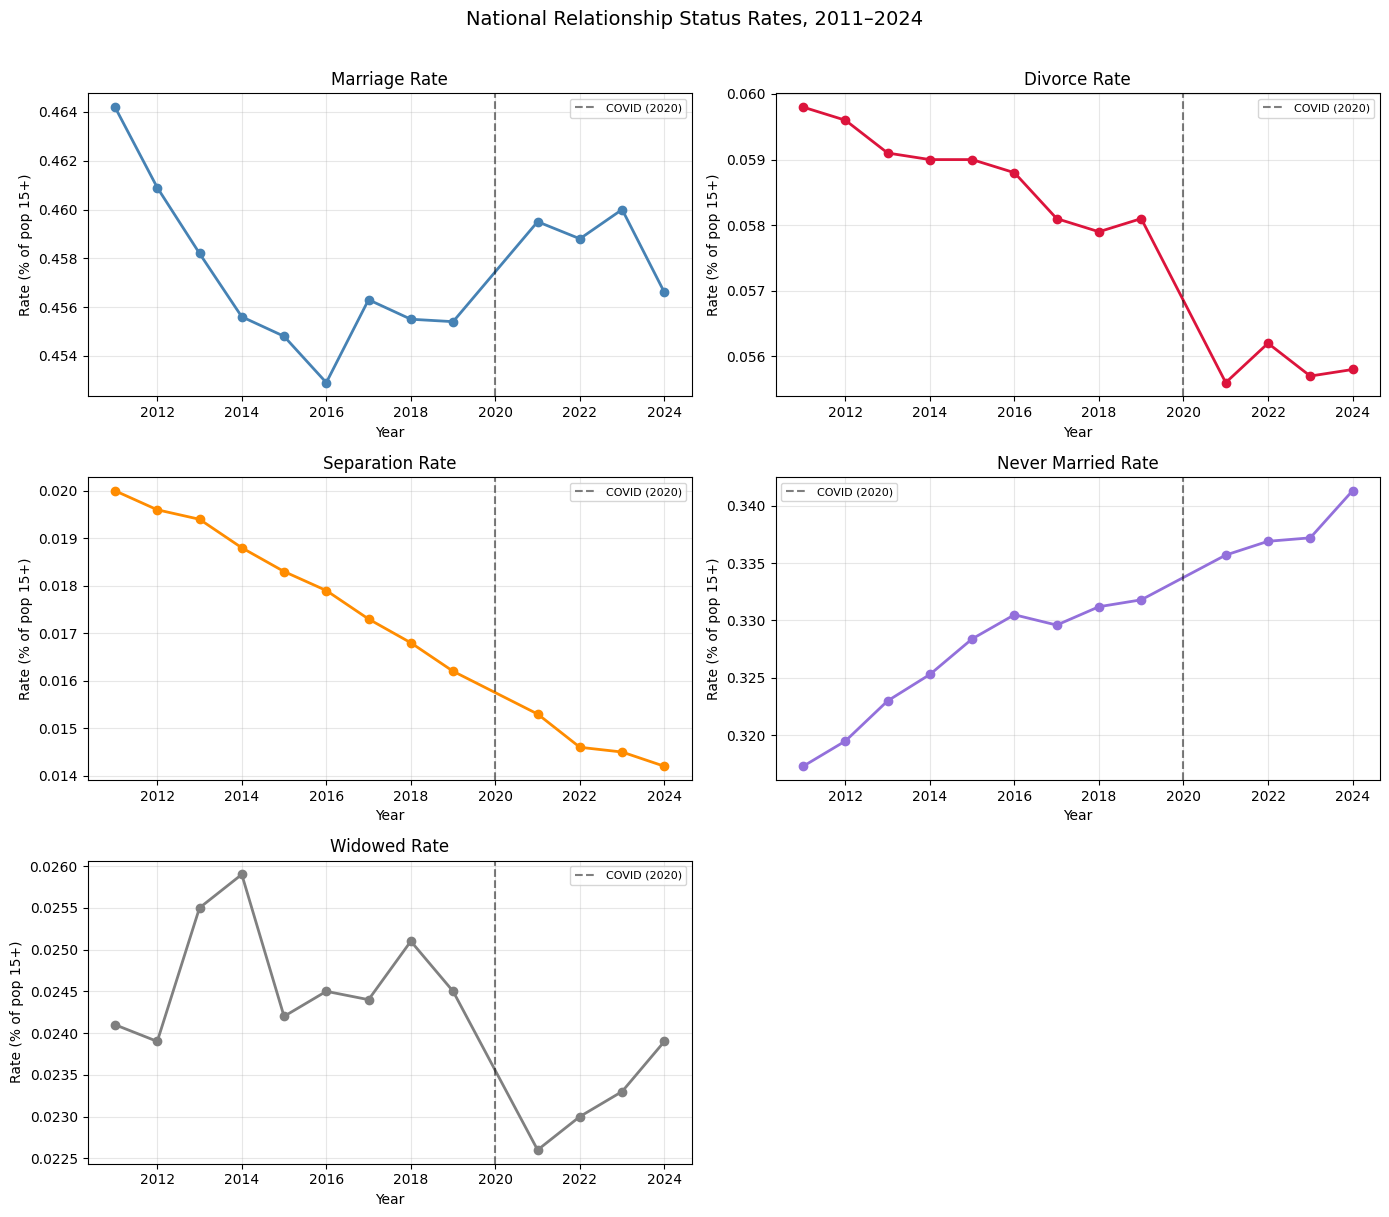

In [131]:
# Chart: All five relationship rates over time
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

metrics = [
    ("avg_married_rate", "Marriage Rate", "steelblue"),
    ("avg_divorce_rate", "Divorce Rate", "crimson"),
    ("avg_separation_rate", "Separation Rate", "darkorange"),
    ("avg_never_married_rate", "Never Married Rate", "mediumpurple"),
    ("avg_widowed_rate", "Widowed Rate", "gray")
]

for i, (col, label, color) in enumerate(metrics):
    ax = axes[i]
    ax.plot(rel_yearly["year"], rel_yearly[col], marker="o", color=color, linewidth=2)
    ax.axvline(x=2020, linestyle="--", color="black", alpha=0.5, label="COVID (2020)")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Rate (% of pop 15+)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle("National Relationship Status Rates, 2011–2024", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation
Marriage Rate - Declined steadily pre-COVID, then bounced slightly post-2021. The pre-COVID drop reflects a long-running structural shift: younger generations are delaying or forgoing marriage due to student debt, housing costs, and changing social norms. The post-COVID uptick may reflect "pandemic-deferred" weddings finally happening once restrictions lifted.

Divorce Rate - Consistent decline across the full period, steepening after 2020. Counterintuitively, divorce fell during COVID - courts closed, people couldn't physically separate households, and financial uncertainty made splitting up economically unviable for many couples. The continued decline post-COVID may reflect that couples who stayed together through the pandemic were more likely to remain married.

Separation Rate - Long, steady decline throughout. Separation (informal, no legal process) has been gradually replaced by formal divorce as legal access improved and stigma decreased, so fewer people stay in the limbo of separation long-term.

Never Married Rate - Rising continuously, uninterrupted by COVID. This is a generational structural shift - millennials and Gen Z are choosing to remain single longer or permanently, driven by financial independence, housing unaffordability, and changing attitudes toward partnership.

Widowed Rate - Sharp drop right at 2020, then gradual recovery. This is the most direct COVID mortality signal: excess deaths disproportionately took older men (who are more likely to be widowers' spouses), but the widowed population itself also died at elevated rates during COVID, mechanically reducing the widowed count before it rebounded.


## Part 2: Pre- vs. Post-COVID Comparison

We compare average relationship rates across the pre-COVID period (2011–2019) and post-COVID recovery period (2021–2024) at both the national and regional level.

In [132]:
# National pre vs post COVID averages
period_rel = (
    acs.groupby("period")
    .agg(
        avg_married_rate=("married_rate", "mean"),
        avg_divorce_rate=("divorce_rate", "mean"),
        avg_separation_rate=("separation_rate", "mean"),
        avg_never_married_rate=("never_married_rate", "mean"),
        avg_widowed_rate=("widowed_rate", "mean")
    )
    .round(4)
    .reset_index()
)

period_rel

,period,avg_married_rate,avg_divorce_rate,avg_separation_rate,avg_never_married_rate,avg_widowed_rate
0,Post-COVID,0.4587,0.0558,0.0147,0.3378,0.0232
1,Pre-COVID,0.4571,0.0588,0.0182,0.3263,0.0247


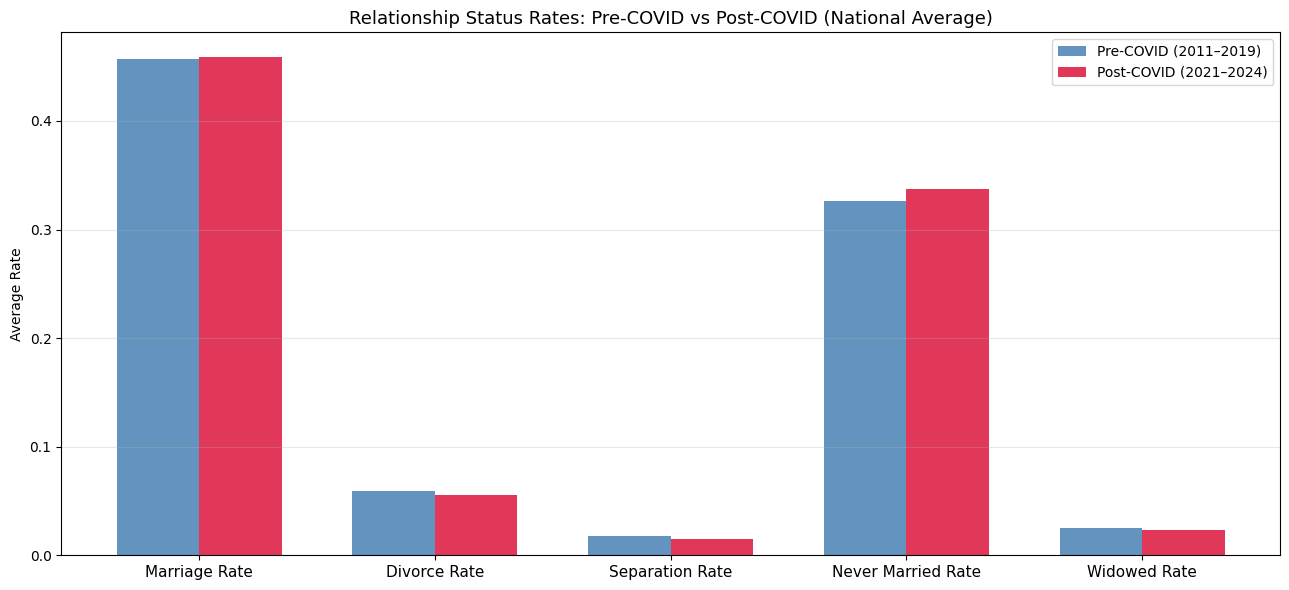

In [133]:
# Grouped bar chart: Pre vs Post COVID comparison for all five rates
rate_cols = ["avg_married_rate", "avg_divorce_rate", "avg_separation_rate",
             "avg_never_married_rate", "avg_widowed_rate"]
labels = ["Marriage Rate", "Divorce Rate", "Separation Rate",
          "Never Married Rate", "Widowed Rate"]

pre = period_rel[period_rel["period"] == "Pre-COVID"][rate_cols].values[0]
post = period_rel[period_rel["period"] == "Post-COVID"][rate_cols].values[0]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars_pre = ax.bar(x - width/2, pre, width, label="Pre-COVID (2011–2019)", color="steelblue", alpha=0.85)
bars_post = ax.bar(x + width/2, post, width, label="Post-COVID (2021–2024)", color="crimson", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Average Rate")
ax.set_title("Relationship Status Rates: Pre-COVID vs Post-COVID (National Average)", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [134]:
# Regional breakdown: Pre vs Post COVID relationship rates
regional_rel = (
    acs.groupby(["region", "period"])
    .agg(
        avg_married_rate=("married_rate", "mean"),
        avg_divorce_rate=("divorce_rate", "mean"),
        avg_separation_rate=("separation_rate", "mean"),
        avg_never_married_rate=("never_married_rate", "mean"),
        avg_widowed_rate=("widowed_rate", "mean")
    )
    .round(4)
    .reset_index()
)

regional_rel

,region,period,avg_married_rate,avg_divorce_rate,avg_separation_rate,avg_never_married_rate,avg_widowed_rate
0,Midwest,Post-COVID,0.4798,0.0553,0.0114,0.3284,0.0183
1,Midwest,Pre-COVID,0.4833,0.0591,0.0133,0.3142,0.0195
2,Northeast,Post-COVID,0.4564,0.0553,0.0139,0.3475,0.0226
3,Northeast,Pre-COVID,0.4538,0.0601,0.0164,0.3383,0.0229
4,Puerto Rico,Post-COVID,0.3138,0.0795,0.0208,0.4243,0.0190
5,Puerto Rico,Pre-COVID,0.3454,0.0731,0.0273,0.3951,0.0226
6,South,Post-COVID,0.4470,0.0603,0.0181,0.3393,0.0236
7,South,Pre-COVID,0.4388,0.0630,0.0236,0.3315,0.0258
8,West,Post-COVID,0.4673,0.0491,0.0133,0.3311,0.0280
9,West,Pre-COVID,0.4676,0.0511,0.0164,0.3170,0.0294


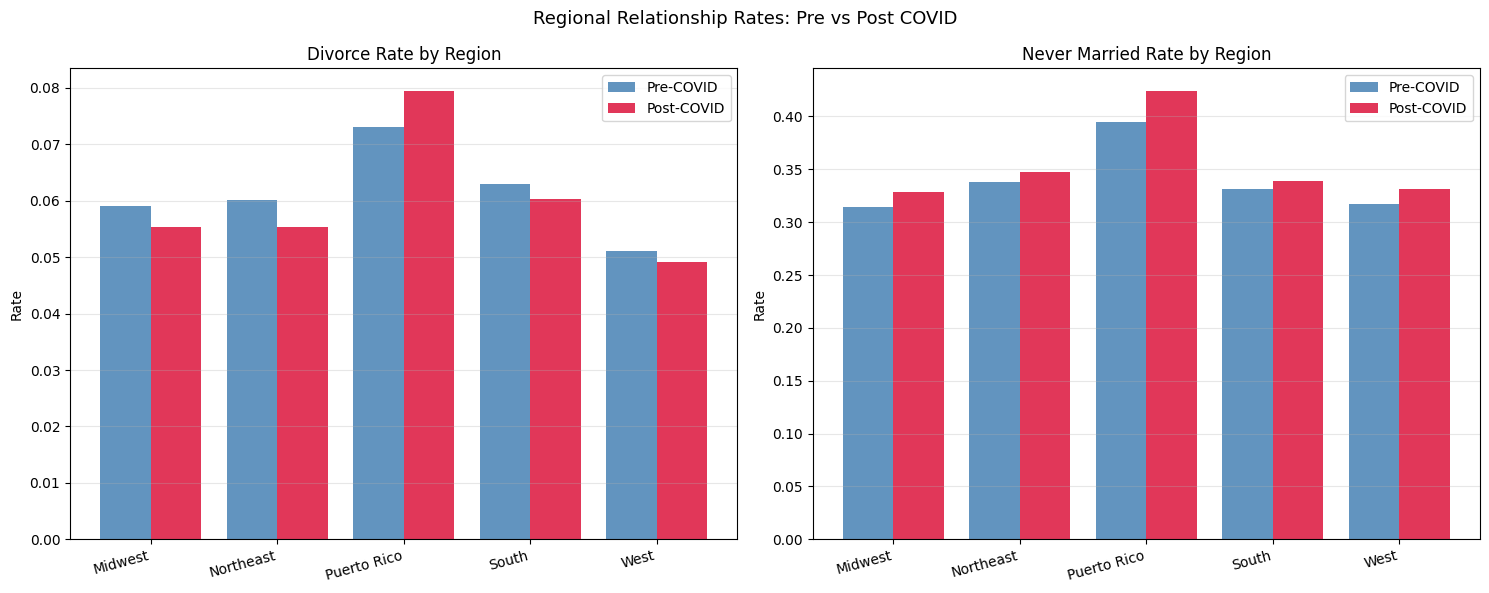

In [135]:
# Faceted bar chart: divorce and never-married rates by region, pre vs post
regions = regional_rel["region"].unique()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

for ax, (metric, title) in zip(axes, [
    ("avg_divorce_rate", "Divorce Rate by Region"),
    ("avg_never_married_rate", "Never Married Rate by Region")
]):
    pre_vals = regional_rel[regional_rel["period"] == "Pre-COVID"].set_index("region")[metric]
    post_vals = regional_rel[regional_rel["period"] == "Post-COVID"].set_index("region")[metric]
    
    x = np.arange(len(regions))
    ax.bar(x - 0.2, pre_vals.reindex(regions), 0.4, label="Pre-COVID", color="steelblue", alpha=0.85)
    ax.bar(x + 0.2, post_vals.reindex(regions), 0.4, label="Post-COVID", color="crimson", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(regions, rotation=15, ha="right")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Rate")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Regional Relationship Rates: Pre vs Post COVID", fontsize=13)
plt.tight_layout()
plt.show()

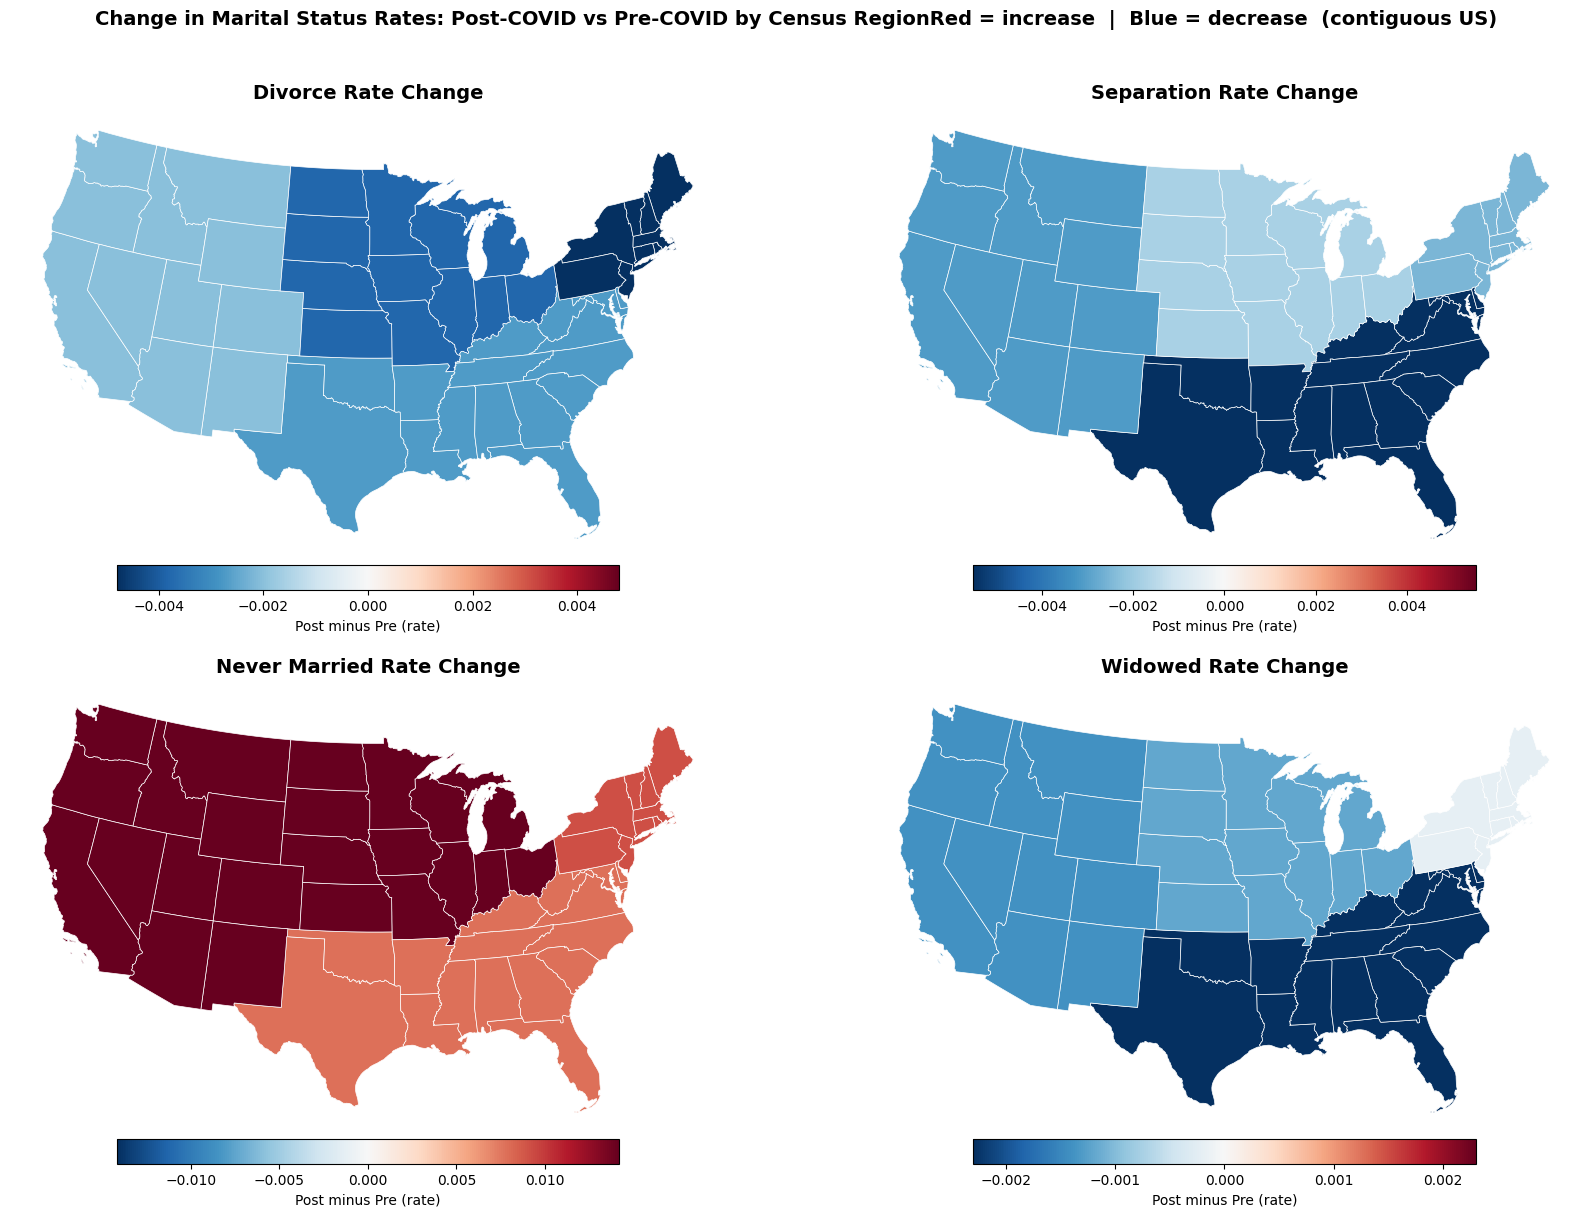

In [136]:
# US choropleth maps: Pre vs Post-COVID change in marital status rates by Census region


# Load US state boundaries (Census Bureau simplified shapefile)
states_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_state_20m.zip"
states_gdf = gpd.read_file(states_url)
states_gdf["region"] = states_gdf["STUSPS"].map(region_map)  # defined in block 143

# Compute Pre- and Post-COVID region averages, then take the difference
rate_cols = ["divorce_rate", "separation_rate", "never_married_rate", "widowed_rate"]

period_avg = (
    acs.groupby(["region", "period"])[rate_cols]
    .mean()
    .reset_index()
)

pre  = period_avg[period_avg["period"] == "Pre-COVID"].set_index("region")[rate_cols]
post = period_avg[period_avg["period"] == "Post-COVID"].set_index("region")[rate_cols]
delta = (post - pre).round(4).reset_index()

# Merge change values onto state geometries
states_merged = states_gdf.merge(delta, on="region", how="left")

# Contiguous 48 + DC, projected to Albers Equal Area
contiguous = states_merged[
    ~states_merged["STUSPS"].isin(["AK", "HI", "PR", "VI", "GU", "MP", "AS"])
].to_crs("ESRI:102003")

metrics = [
    ("divorce_rate",       "Divorce Rate Change",       "RdBu_r"),
    ("separation_rate",    "Separation Rate Change",    "RdBu_r"),
    ("never_married_rate", "Never Married Rate Change", "RdBu_r"),
    ("widowed_rate",       "Widowed Rate Change",       "RdBu_r"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, (col, title, cmap) in zip(axes.flatten(), metrics):
    max_abs = contiguous[col].abs().max()
    contiguous.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        vmin=-max_abs,
        vmax=max_abs,
        legend=True,
        legend_kwds={"label": "Post minus Pre (rate)", "orientation": "horizontal", "shrink": 0.55, "pad": 0.01},
        edgecolor="white",
        linewidth=0.5,
        missing_kwds={"color": "lightgrey", "label": "No data"},
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8)
    ax.set_axis_off()

plt.suptitle(
    "Change in Marital Status Rates: Post-COVID vs Pre-COVID by Census Region"    
    "Red = increase  |  Blue = decrease  (contiguous US)",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()


### Analysis
Marriage ticked up slightly post-COVID while divorce and separation both fell. This is consistent with COVID filtering out more fragile relationships before they formally dissolved, and economic uncertainty keeping households together out of financial necessity. The never-married rate rose meaningfully, reinforcing that the "staying single" trend accelerated rather than reversed during the pandemic years.


## Part 3: State-Level Changes - Who Shifted the Most?

While national and regional averages tell a broad story, the most actionable insights come from understanding which specific states saw the largest pre- to post-COVID shifts in relationship patterns. We compute the change in divorce rate and never-married rate for each state and rank them.

Below is  SQL Analysis: State-level divorce, never-married, and widowed rate changes pre vs post COVID Joins the ACS table to itself splitting by period to compute the change in divorce, never-married, and widowed rate per state. 

In [137]:
q_divorce_state = '''
SELECT
    pre.state_abbreviation,
    pre.region,
    ROUND(AVG(pre.divorce_rate), 4)           AS pre_divorce_rate,
    ROUND(AVG(post.divorce_rate), 4)          AS post_divorce_rate,
    ROUND(AVG(post.divorce_rate)
        - AVG(pre.divorce_rate), 4)           AS divorce_change,
    ROUND(AVG(pre.never_married_rate), 4)     AS pre_never_married_rate,
    ROUND(AVG(post.never_married_rate), 4)    AS post_never_married_rate,
    ROUND(AVG(post.never_married_rate)
        - AVG(pre.never_married_rate), 4)     AS never_married_change,
    ROUND(AVG(pre.widowed_rate), 4)           AS pre_widowed_rate,
    ROUND(AVG(post.widowed_rate), 4)          AS post_widowed_rate,
    ROUND(AVG(post.widowed_rate)
        - AVG(pre.widowed_rate), 4)           AS widowed_change
FROM acs AS pre
JOIN acs AS post
    ON pre.state_abbreviation = post.state_abbreviation
WHERE pre.period  = 'Pre-COVID'
  AND post.period = 'Post-COVID'
GROUP BY pre.state_abbreviation, pre.region
ORDER BY divorce_change DESC
LIMIT 5;
'''

divorce_state_sql = run_query(q_divorce_state)
divorce_state_sql

,state_abbreviation,region,pre_divorce_rate,post_divorce_rate,divorce_change,pre_never_married_rate,post_never_married_rate,never_married_change,pre_widowed_rate,post_widowed_rate,widowed_change
0,PR,Puerto Rico,0.0731,0.0795,0.0065,0.3951,0.4243,0.0292,0.0226,0.0190,-0.0036
1,WY,West,0.0532,0.0551,0.0019,0.2727,0.2794,0.0066,0.0197,0.0193,-0.0004
2,DE,South,0.0607,0.0623,0.0016,0.3362,0.3335,-0.0027,0.0238,0.0222,-0.0016
3,AK,West,0.0382,0.0392,0.0010,0.3429,0.3455,0.0026,0.0413,0.0368,-0.0045
4,NH,Northeast,0.0553,0.0548,-0.0005,0.2961,0.3063,0.0102,0.0177,0.0196,0.0019


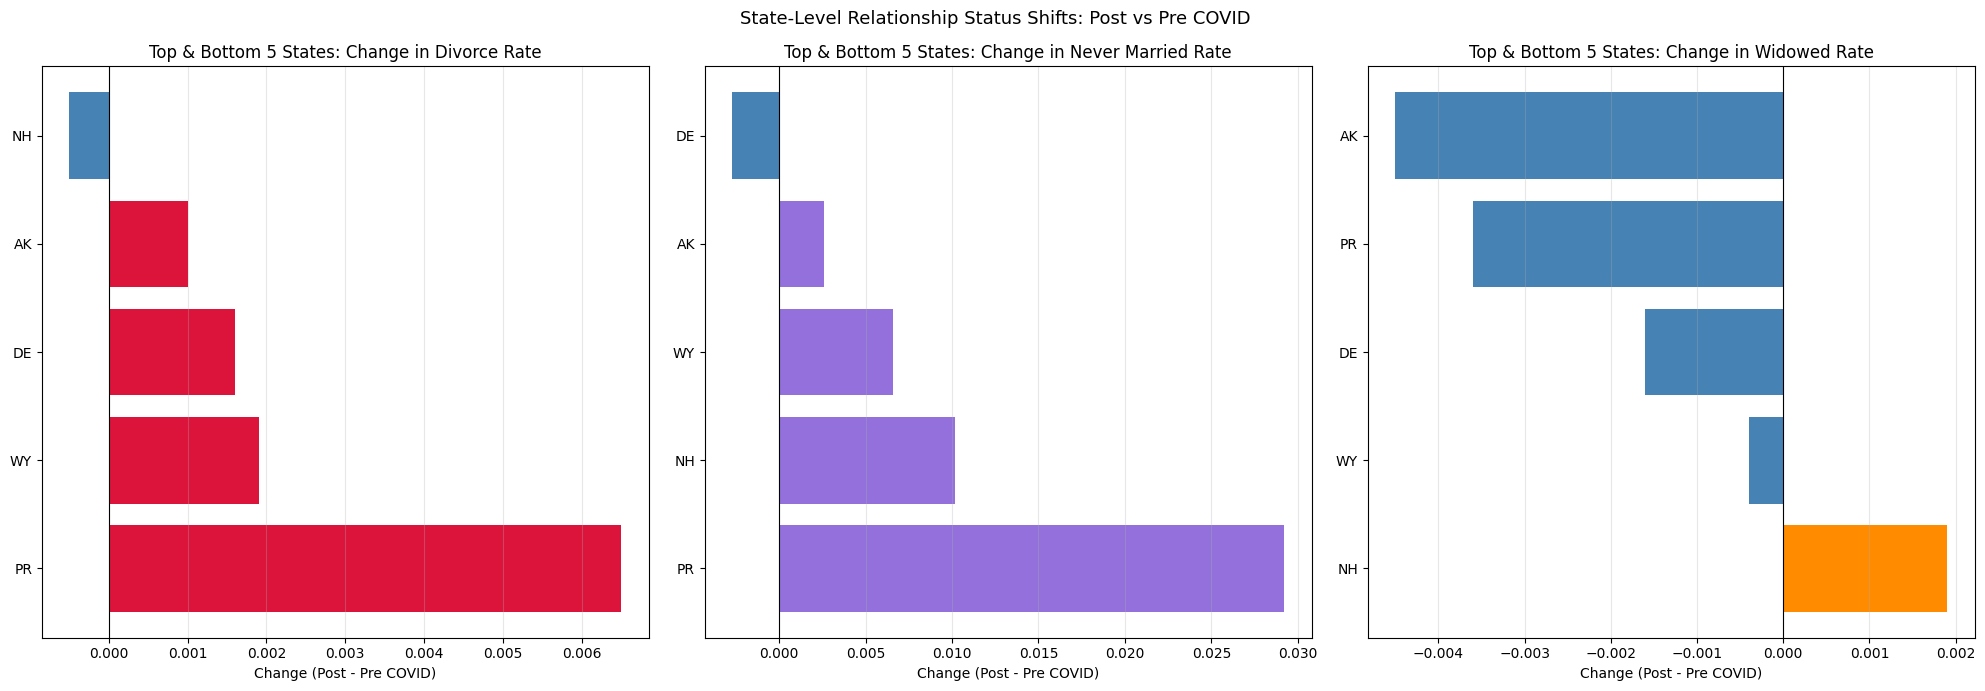

In [138]:
# Visualize SQL output: top and bottom 5 states by divorce, never-married, and widowed change
divorce_ranked = divorce_state_sql.sort_values("divorce_change", ascending=False)
divorce_top_bottom = pd.concat([divorce_ranked.tail(5), divorce_ranked.head(5)])

nm_ranked = divorce_state_sql.sort_values("never_married_change", ascending=False)
nm_top_bottom = pd.concat([nm_ranked.tail(5), nm_ranked.head(5)])

widowed_ranked = divorce_state_sql.sort_values("widowed_change", ascending=False)
widowed_top_bottom = pd.concat([widowed_ranked.tail(5), widowed_ranked.head(5)])

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Divorce change
colors_d = ["crimson" if v > 0 else "steelblue" for v in divorce_top_bottom["divorce_change"]]
axes[0].barh(divorce_top_bottom["state_abbreviation"], divorce_top_bottom["divorce_change"], color=colors_d)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Top & Bottom 5 States: Change in Divorce Rate")
axes[0].set_xlabel("Change (Post - Pre COVID)")
axes[0].grid(axis="x", alpha=0.3)

# Never married change
colors_nm = ["mediumpurple" if v > 0 else "steelblue" for v in nm_top_bottom["never_married_change"]]
axes[1].barh(nm_top_bottom["state_abbreviation"], nm_top_bottom["never_married_change"], color=colors_nm)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Top & Bottom 5 States: Change in Never Married Rate")
axes[1].set_xlabel("Change (Post - Pre COVID)")
axes[1].grid(axis="x", alpha=0.3)

# Widowed change
colors_w = ["darkorange" if v > 0 else "steelblue" for v in widowed_top_bottom["widowed_change"]]
axes[2].barh(widowed_top_bottom["state_abbreviation"], widowed_top_bottom["widowed_change"], color=colors_w)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Top & Bottom 5 States: Change in Widowed Rate")
axes[2].set_xlabel("Change (Post - Pre COVID)")
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle("State-Level Relationship Status Shifts: Post vs Pre COVID", fontsize=13)
plt.tight_layout()
plt.show()

In [139]:
# State-level: average rate in each period
state_pre = (
    acs[acs["period"] == "Pre-COVID"]
    .groupby("state_abbreviation")
    .agg(
        pre_divorce=("divorce_rate", "mean"),
        pre_never_married=("never_married_rate", "mean"),
        pre_married=("married_rate", "mean"),
        pre_separation=("separation_rate", "mean"),
        pre_widowed=("widowed_rate", "mean")
    )
)

state_post = (
    acs[acs["period"] == "Post-COVID"]
    .groupby("state_abbreviation")
    .agg(
        post_divorce=("divorce_rate", "mean"),
        post_never_married=("never_married_rate", "mean"),
        post_married=("married_rate", "mean"),
        post_separation=("separation_rate", "mean"),
        post_widowed=("widowed_rate", "mean")
    )
)

# Join and compute changes
state_rel_change = state_pre.join(state_post)
state_rel_change["divorce_change"] = (state_rel_change["post_divorce"] - state_rel_change["pre_divorce"]).round(4)
state_rel_change["never_married_change"] = (state_rel_change["post_never_married"] - state_rel_change["pre_never_married"]).round(4)
state_rel_change["married_change"] = (state_rel_change["post_married"] - state_rel_change["pre_married"]).round(4)
state_rel_change["separation_change"] = (state_rel_change["post_separation"] - state_rel_change["pre_separation"]).round(4)
state_rel_change["widowed_change"] = (state_rel_change["post_widowed"] - state_rel_change["pre_widowed"]).round(4)

state_rel_change = state_rel_change.reset_index()
state_rel_change.head(10)

,state_abbreviation,pre_divorce,pre_never_married,pre_married,pre_separation,pre_widowed,post_divorce,post_never_married,post_married,post_separation,post_widowed,divorce_change,never_married_change,married_change,separation_change,widowed_change
0,AK,0.0382,0.3429,0.4430,0.0181,0.0413,0.0392,0.3455,0.4529,0.0148,0.0368,0.0010,0.0026,0.0099,-0.0033,-0.0045
1,AL,0.0704,0.3055,0.4525,0.0242,0.0223,0.0681,0.3170,0.4559,0.0179,0.0227,-0.0023,0.0115,0.0033,-0.0062,0.0004
2,AR,0.0691,0.2783,0.4729,0.0234,0.0235,0.0661,0.2966,0.4718,0.0183,0.0204,-0.0030,0.0184,-0.0011,-0.0051,-0.0031
3,AZ,0.0555,0.3320,0.4417,0.0180,0.0284,0.0529,0.3411,0.4525,0.0135,0.0263,-0.0025,0.0091,0.0107,-0.0045,-0.0021
4,CA,0.0501,0.3695,0.4261,0.0216,0.0377,0.0472,0.3839,0.4262,0.0181,0.0368,-0.0029,0.0144,0.0002,-0.0035,-0.0008
5,CO,0.0439,0.3170,0.4784,0.0150,0.0259,0.0409,0.3323,0.4828,0.0121,0.0233,-0.0030,0.0154,0.0045,-0.0030,-0.0027
6,CT,0.0583,0.3465,0.4510,0.0132,0.0230,0.0536,0.3624,0.4444,0.0117,0.0239,-0.0047,0.0160,-0.0066,-0.0015,0.0009
7,DC,0.0432,0.5691,0.2454,0.0216,0.0319,0.0379,0.5518,0.2837,0.0144,0.0258,-0.0054,-0.0173,0.0383,-0.0072,-0.0062
8,DE,0.0607,0.3362,0.4475,0.0173,0.0238,0.0623,0.3335,0.4630,0.0138,0.0222,0.0016,-0.0027,0.0156,-0.0035,-0.0016
9,FL,0.0700,0.3165,0.4258,0.0235,0.0331,0.0633,0.3165,0.4494,0.0179,0.0300,-0.0067,-0.0000,0.0236,-0.0056,-0.0031


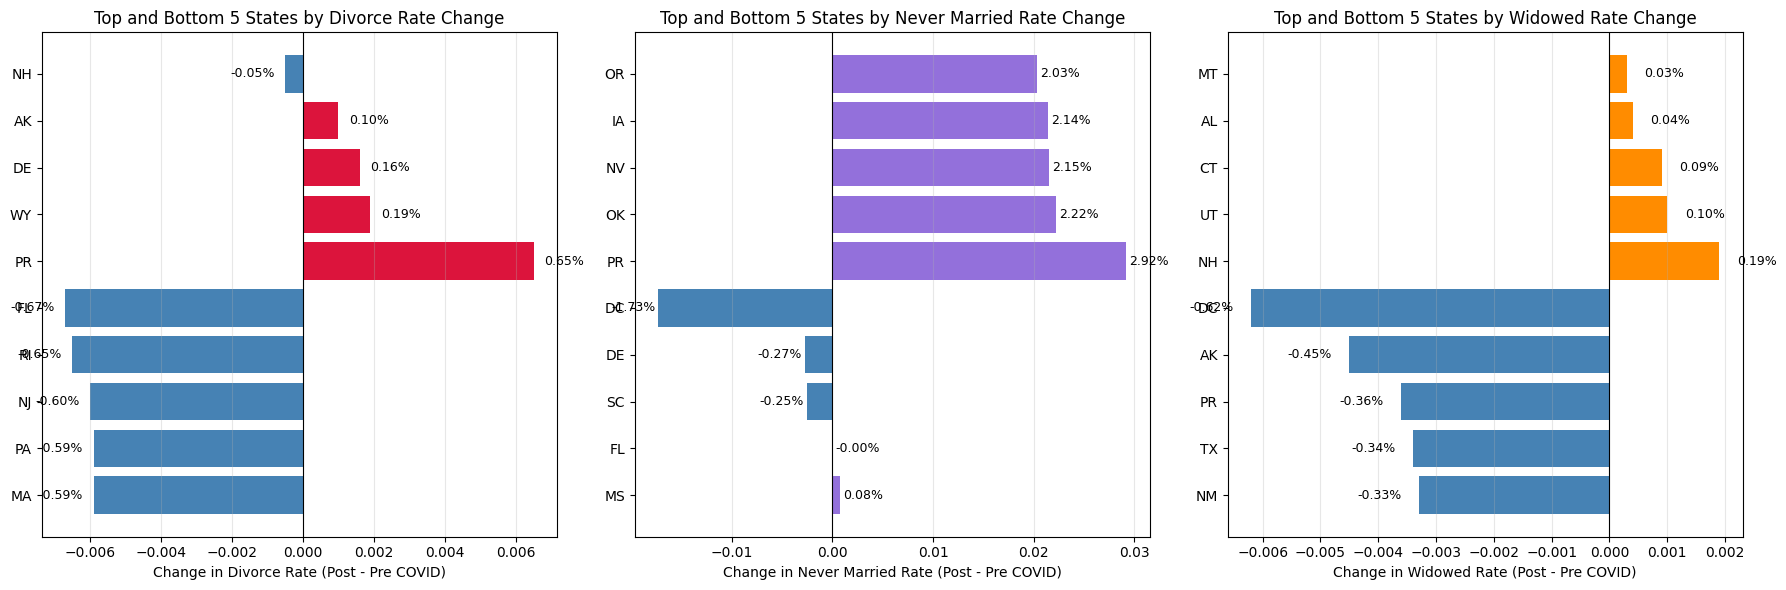

In [140]:
# Part 3 combined charts: divorce, never-married, and widowed rate changes side by side
divorce_ranked = state_rel_change.sort_values("divorce_change", ascending=False)
divorce_top_bottom = pd.concat([divorce_ranked.tail(5), divorce_ranked.head(5)])

nm_ranked = state_rel_change.sort_values("never_married_change", ascending=False)
nm_top_bottom = pd.concat([nm_ranked.tail(5), nm_ranked.head(5)])

widowed_ranked = state_rel_change.sort_values("widowed_change", ascending=False)
widowed_top_bottom = pd.concat([widowed_ranked.tail(5), widowed_ranked.head(5)])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

plots = [
    (divorce_top_bottom, "divorce_change", "Change in Divorce Rate (Post - Pre COVID)", "Top and Bottom 5 States by Divorce Rate Change", ["crimson" if v > 0 else "steelblue" for v in divorce_top_bottom["divorce_change"]]),
    (nm_top_bottom, "never_married_change", "Change in Never Married Rate (Post - Pre COVID)", "Top and Bottom 5 States by Never Married Rate Change", ["mediumpurple" if v > 0 else "steelblue" for v in nm_top_bottom["never_married_change"]]),
    (widowed_top_bottom, "widowed_change", "Change in Widowed Rate (Post - Pre COVID)", "Top and Bottom 5 States by Widowed Rate Change", ["darkorange" if v > 0 else "steelblue" for v in widowed_top_bottom["widowed_change"]])
]

for ax, (df, col, xlabel, title, colors) in zip(axes, plots):
    bars = ax.barh(df["state_abbreviation"], df[col], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="x", alpha=0.3)
    for bar, value in zip(bars, df[col]):
        x = value + (0.0003 if value >= 0 else -0.0003)
        ha = "left" if value >= 0 else "right"
        ax.text(x, bar.get_y() + bar.get_height() / 2, f"{value:.2%}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()


# Factors affecting divorce and marriage rates


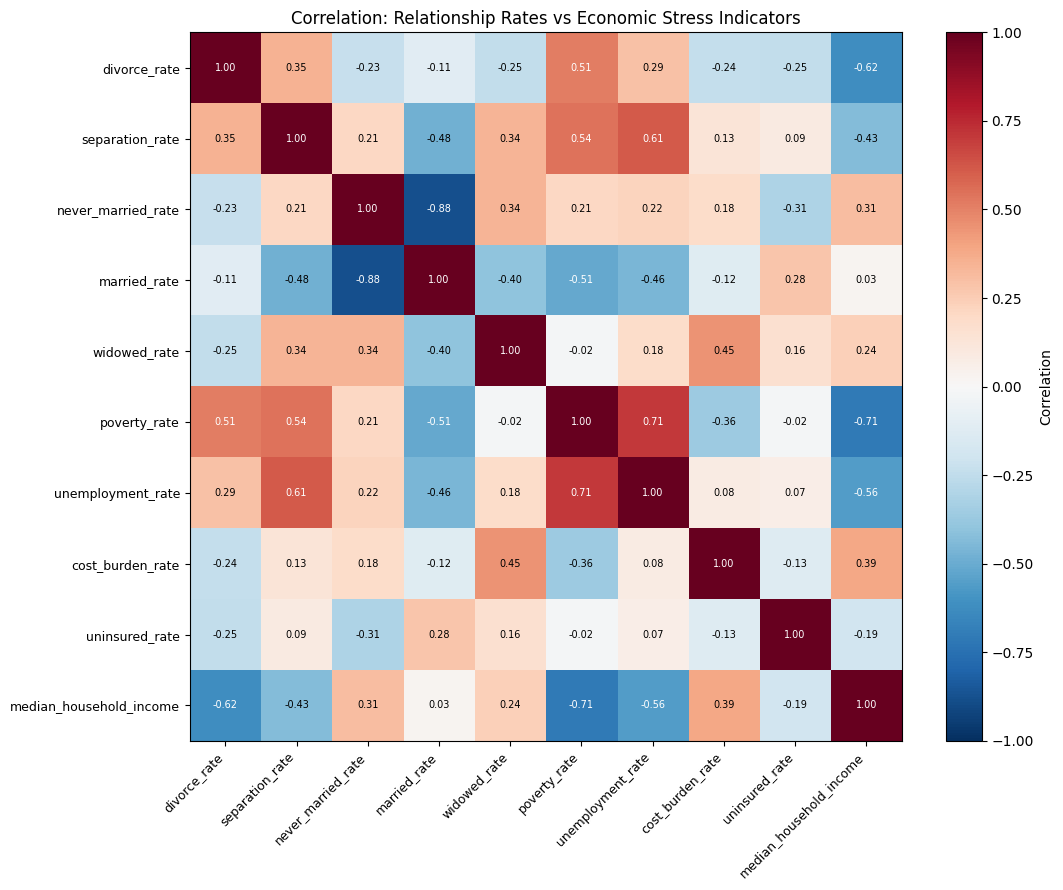

In [141]:
# Correlation matrix: relationship rates vs economic stress indicators
corr_cols = [
    "divorce_rate", "separation_rate", "never_married_rate", "married_rate", "widowed_rate",
    "poverty_rate", "unemployment_rate", "cost_burden_rate", "uninsured_rate", "median_household_income"
]

corr_matrix = acs[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 9))

# Manual heatmap using matplotlib
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Correlation")

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotate with values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(val) > 0.5 else "black")

ax.set_title("Correlation: Relationship Rates vs Economic Stress Indicators", fontsize=12)
plt.tight_layout()
plt.show()

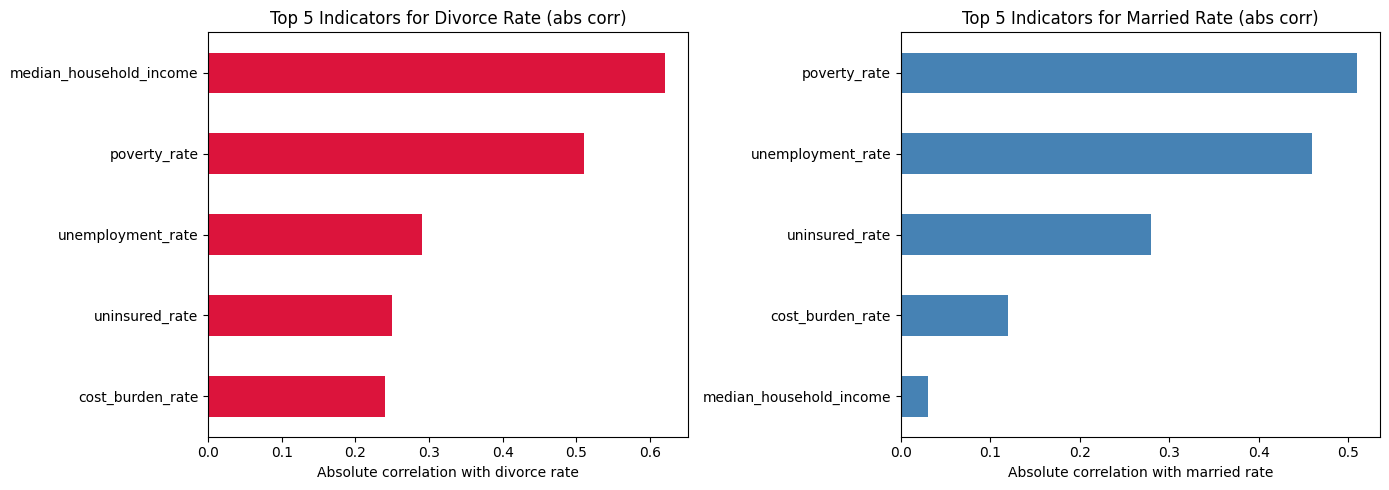

In [142]:
# Identify the top 5 strongest indicators for divorce rate and married rate
indicator_cols = ["poverty_rate", "unemployment_rate", "cost_burden_rate", "uninsured_rate", "median_household_income"]

divorce_corr = corr_matrix.loc["divorce_rate", indicator_cols].abs().sort_values(ascending=False).head(5)
married_corr = corr_matrix.loc["married_rate", indicator_cols].abs().sort_values(ascending=False).head(5)

top5_side = pd.DataFrame({
    "Divorce Indicator": divorce_corr.index,
    "Divorce | abs(corr)": divorce_corr.values,
    "Married Indicator": married_corr.index,
    "Married | abs(corr)": married_corr.values
})

top5_side

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

divorce_corr.sort_values().plot.barh(ax=axes[0], color="crimson", title="Top 5 Indicators for Divorce Rate (abs corr)")
axes[0].set_xlabel("Absolute correlation with divorce rate")

married_corr.sort_values().plot.barh(ax=axes[1], color="steelblue", title="Top 5 Indicators for Married Rate (abs corr)")
axes[1].set_xlabel("Absolute correlation with married rate")

plt.tight_layout()
plt.show()

# Suggested chart: a pair of side-by-side horizontal bar charts comparing absolute correlation strength for top indicators of divorce and married rates.


### Interpretation

Divorce and separation track poverty and unemployment. Divorce correlates 0.51 with poverty and 0.29 with unemployment; separation is even stronger at 0.54 and 0.61. States with more economic stress have more household instability, and separation in particular appears to be a stress behavior, not just a legal process.

Higher income is strongly protective against divorce and separation. Median household income sits at -0.62 with divorce and -0.43 with separation. Wealthier states have more stable marriages, likely because financial security removes one of the primary drivers of relationship breakdown.

Never-married rises with income (0.31). This seems counterintuitive but reflects the demographic reality that higher-income, urban, educated states have younger populations staying single longer by choice, not necessity.

Married rate falls with poverty (-0.51). Lower-income states have lower marriage rates, reinforcing that formal marriage has increasingly become associated with economic stability rather than a pathway to it.

Cost burden and widowed rate correlate (0.45). States with more housing-stressed renters also have older populations bearing more widow/widower status, likely reflecting geographic concentration of older, lower-income households.

Uninsured rate is a stronger predictor of marriage formation than of divorce specifically, which is its own interesting finding: insurance access (or lack of it) shapes whether people enter marriages more than whether existing ones break down.

## Part 5: Stacked Composition View - How Did Household Status Mix Change?

Rather than looking at rates independently, this chart stacks all five relationship statuses to show how the overall composition of the adult population shifted nationally between the pre- and post-COVID periods. This gives a fuller picture of household structure change.

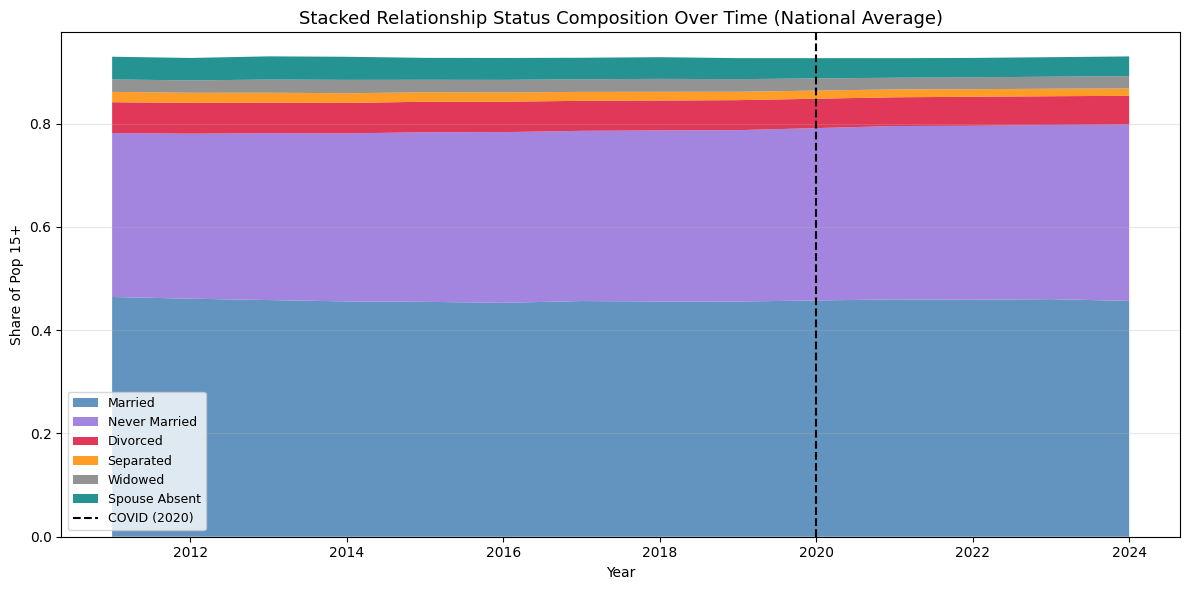

In [143]:
# Stacked area chart: relationship status composition over time (national average)
rel_stack = rel_yearly[
    ["year", "avg_married_rate", "avg_never_married_rate",
     "avg_divorce_rate", "avg_separation_rate", "avg_widowed_rate",
     "avg_spouse_absent_rate"]
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    rel_stack["year"],
    rel_stack["avg_married_rate"],
    rel_stack["avg_never_married_rate"],
    rel_stack["avg_divorce_rate"],
    rel_stack["avg_separation_rate"],
    rel_stack["avg_widowed_rate"],
    rel_stack["avg_spouse_absent_rate"],
    labels=["Married", "Never Married", "Divorced", "Separated", "Widowed", "Spouse Absent"],
    colors=["steelblue", "mediumpurple", "crimson", "darkorange", "gray", "teal"],
    alpha=0.85
)

ax.axvline(x=2020, linestyle="--", color="black", linewidth=1.5, label="COVID (2020)")
ax.set_title("Stacked Relationship Status Composition Over Time (National Average)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Share of Pop 15+")
ax.legend(loc="lower left", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Part 6: Marriage Stability vs Poverty

In this section we created  a marital instability metric and examined its relationship with economic stress, specifically poverty.

Change in Marital Instability Rate (Post minus Pre-COVID):
     region  instability_change
    Midwest             -0.0086
  Northeast             -0.0100
Puerto Rico             -0.0102
      South             -0.0160
       West             -0.0097


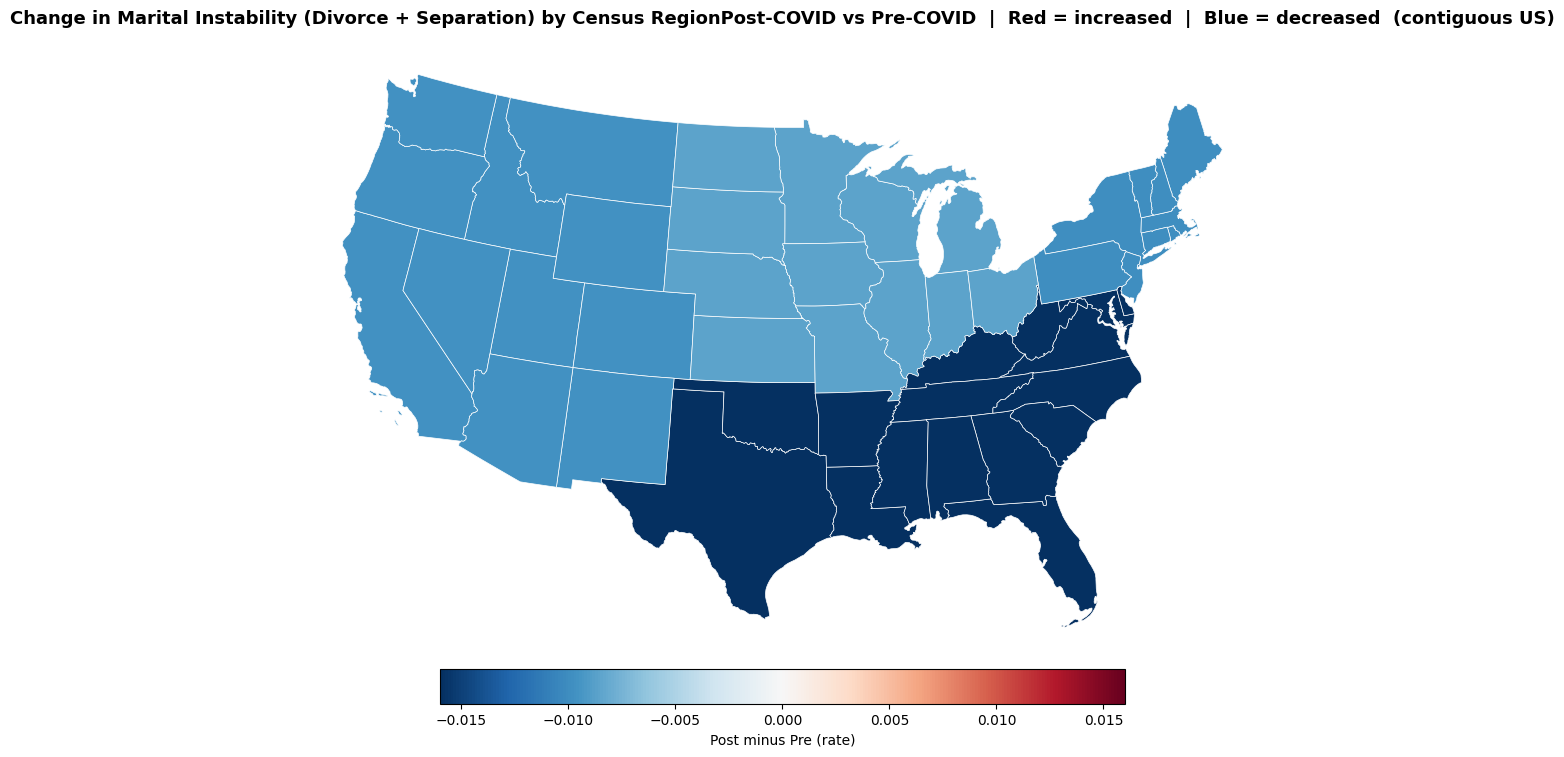

In [156]:
# Marital instability: Pre vs Post-COVID change by Census region (geopandas choropleth)
import geopandas as gpd
import matplotlib.pyplot as plt

acs["instability_rate"] = acs["divorce_rate"] + acs["separation_rate"] + acs["spouse_absent_rate"]

# Average instability per region for each period
instability_periods = (
    acs.groupby(["region", "period"])["instability_rate"]
    .mean()
    .reset_index()
)

pre  = instability_periods[instability_periods["period"] == "Pre-COVID"].set_index("region")["instability_rate"]
post = instability_periods[instability_periods["period"] == "Post-COVID"].set_index("region")["instability_rate"]
instability_delta = (post - pre).round(4).rename("instability_change").reset_index()

print("Change in Marital Instability Rate (Post minus Pre-COVID):")
print(instability_delta.to_string(index=False))

# Load US state boundaries
states_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_state_20m.zip"
states_gdf = gpd.read_file(states_url)
states_gdf["region"] = states_gdf["STUSPS"].map(region_map)  # defined in block 143

# Merge change values onto state geometries
states_merged = states_gdf.merge(instability_delta, on="region", how="left")
contiguous = states_merged[
    ~states_merged["STUSPS"].isin(["AK", "HI", "PR", "VI", "GU", "MP", "AS"])
].to_crs("ESRI:102003")

max_abs = contiguous["instability_change"].abs().max()

fig, ax = plt.subplots(figsize=(14, 8))
contiguous.plot(
    column="instability_change",
    ax=ax,
    cmap="RdBu_r",
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    legend_kwds={"label": "Post minus Pre (rate)", "orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
    edgecolor="white",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)
ax.set_title(
    "Change in Marital Instability (Divorce + Separation) by Census Region"
    "Post-COVID vs Pre-COVID  |  Red = increased  |  Blue = decreased  (contiguous US)",
    fontsize=13, fontweight="bold"
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [157]:
# Create marriage stability ratio: married rate relative to instability
# Higher ratio = more stable marriages
acs['marriage_stability'] = acs['married_rate'] / (acs['divorce_rate'] + acs['separation_rate'])

# Replace any inf or nan values with a reasonable value or drop them
acs['marriage_stability'] = acs['marriage_stability'].replace([np.inf, -np.inf], np.nan)

print("Marriage Stability Ratio Statistics:")
print(acs['marriage_stability'].describe())
print()
print(f"Valid records: {acs['marriage_stability'].notna().sum()} / {len(acs)}")

Marriage Stability Ratio Statistics:
count   676.0000
mean      6.2785
std       1.3388
min       2.8677
25%       5.4219
50%       6.0821
75%       7.0931
max      11.4341
Name: marriage_stability, dtype: float64

Valid records: 676 / 676


Correlation: Marriage Stability vs Poverty Rate
                    marriage_stability  poverty_rate
marriage_stability              1.0000       -0.6242
poverty_rate                   -0.6242        1.0000

Pearson r: -0.6242
P-value: 2.73e-74



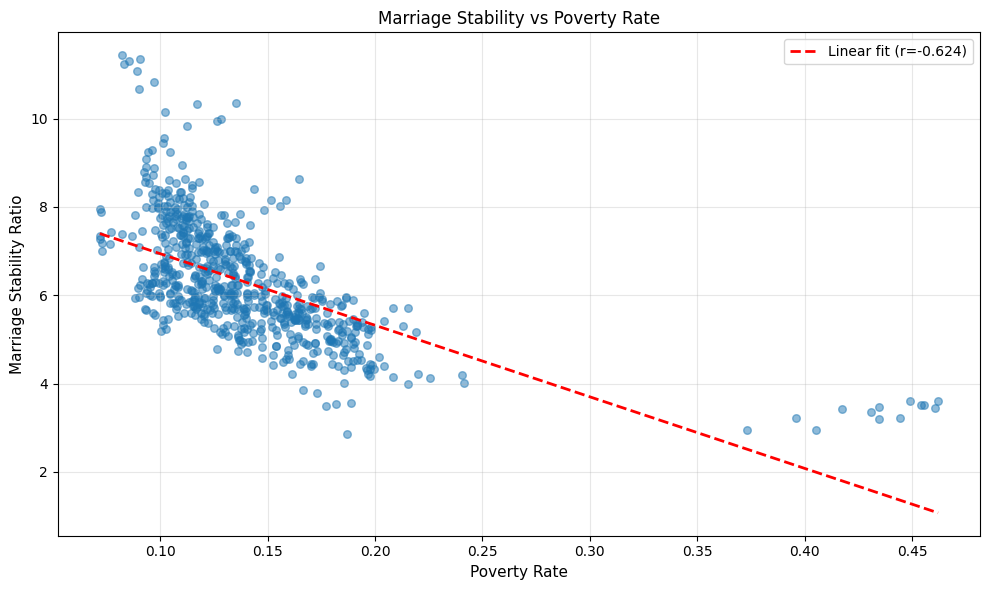

In [158]:
# Analyze correlation between marriage stability and poverty
correlation = acs[['marriage_stability', 'poverty_rate']].corr()

print("Correlation: Marriage Stability vs Poverty Rate")
print(correlation)
print()

# Compute Pearson correlation coefficient
from scipy.stats import pearsonr
valid_data = acs[['marriage_stability', 'poverty_rate']].dropna()
corr_coeff, p_value = pearsonr(valid_data['marriage_stability'], valid_data['poverty_rate'])

print(f"Pearson r: {corr_coeff:.4f}")
print(f"P-value: {p_value:.2e}")
print()

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(valid_data['poverty_rate'], valid_data['marriage_stability'], alpha=0.5, s=30)
z = np.polyfit(valid_data['poverty_rate'], valid_data['marriage_stability'], 1)
p = np.poly1d(z)
ax.plot(valid_data['poverty_rate'].sort_values(), p(valid_data['poverty_rate'].sort_values()), "r--", linewidth=2, label=f'Linear fit (r={corr_coeff:.3f})')
ax.set_xlabel('Poverty Rate', fontsize=11)
ax.set_ylabel('Marriage Stability Ratio', fontsize=11)
ax.set_title('Marriage Stability vs Poverty Rate', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Labor Market Adaptations after COVID

This section examines how work structure and commuting patterns changed before and after COVID-19. By analyzing remote work adoption, public transit usage, and commute times, the analysis explores how the pandemic affected the ways people worked and traveled across the United States.

In [159]:
# Groupby 1: National averages by year

remote_yearly_summary = (
    acs.groupby("year")
    .agg(
        avg_remote_work_rate=("remote_work_rate", "mean"),
        avg_public_transit_rate=("public_transit_rate", "mean"),
        avg_commute_time=("mean_commute_time", "mean")
    )
    .round(4)
    .reset_index()
)

remote_yearly_summary

,year,avg_remote_work_rate,avg_public_transit_rate,avg_commute_time
0,2011,0.0434,0.0380,23.8770
1,2012,0.0442,0.0374,24.0442
2,2013,0.0427,0.0384,24.0804
3,2014,0.0446,0.0384,24.2112
4,2015,0.0454,0.0385,24.4907
5,2016,0.0495,0.0374,24.5346
6,2017,0.0510,0.0359,24.7716
7,2018,0.0523,0.0358,25.0188
8,2019,0.0548,0.0363,25.5101
9,2021,0.1637,0.0170,24.1384


In [160]:
# Groupby 2: Pre vs post summary

remote_period_summary = (
    acs.groupby("period")
    .agg(
        avg_remote_work_rate=("remote_work_rate", "mean"),
        avg_public_transit_rate=("public_transit_rate", "mean"),
        avg_commute_time=("mean_commute_time", "mean")
    )
    .round(4)
    .reset_index()
)

remote_period_summary

,period,avg_remote_work_rate,avg_public_transit_rate,avg_commute_time
0,Post-COVID,0.1389,0.0230,24.8154
1,Pre-COVID,0.0476,0.0374,24.5043


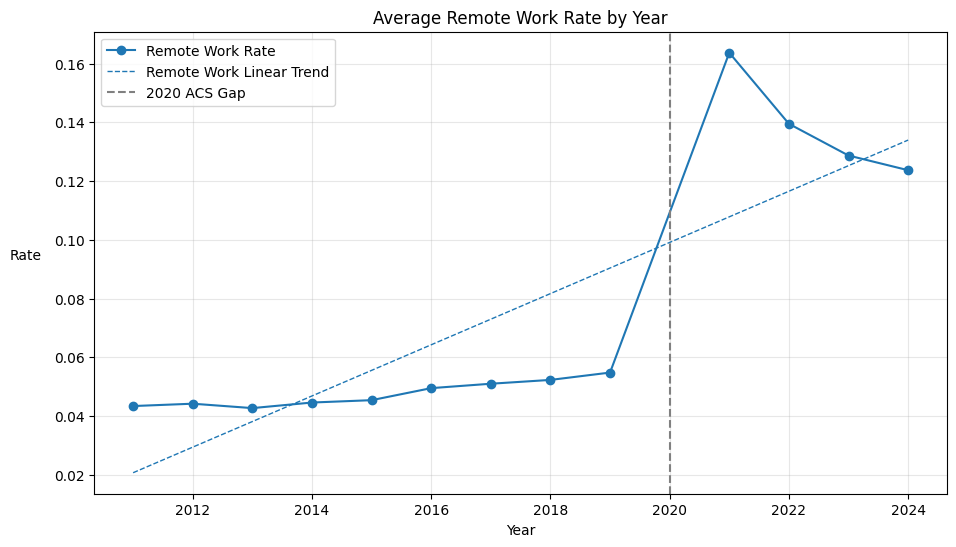

In [161]:
# Chart 1: Remote work trend over time

plt.figure(figsize=(11, 6))

plt.plot(
    remote_yearly_summary["year"],
    remote_yearly_summary["avg_remote_work_rate"],
    marker="o",
    label="Remote Work Rate"
)

# Prepare X and y for sklearn
X1 = remote_yearly_summary[["year"]]
y1 = remote_yearly_summary["avg_remote_work_rate"]

# Fit regression
linreg_model_remote = LinearRegression()
linreg_model_remote.fit(X1, y1)

y_pred_remote = linreg_model_remote.predict(X1)

# Plot trend line
plt.plot(
    remote_yearly_summary["year"],
    y_pred_remote,
    linestyle="--",
    linewidth=1,
    label="Remote Work Linear Trend",
    color="C0"
)

plt.axvline(2020, linestyle="--", color="gray", label="2020 ACS Gap")

plt.title("Average Remote Work Rate by Year")
plt.xlabel("Year")
plt.ylabel("Rate", rotation=0, labelpad=20)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation: Remote Work Increased Significantly Following COVID-19

The remote work data shows a major shift in how Americans worked following COVID-19. Before the pandemic, remote work rates were relatively stable, remaining between roughly 4% and 6% from 2011 through 2019. This suggests that while remote work existed before COVID-19, it was still not widely adopted.

After the pandemic, remote work adoption increased sharply. The average remote work rate rose to more than 16% in 2021, representing a substantial increase compared to pre-COVID levels. Although remote work rates declined somewhat after the initial spike, they have remained significantly above pre-pandemic levels through 2024. This suggests that many workplaces continued to maintain flexible or hybrid work arrangements even after the immediate effects of the pandemic eased.

The linear trendline further highlights the strong upward movement in remote work adoption across the study period. Rather than returning fully to pre-pandemic commuting patterns, the data suggests that COVID-19 accelerated a longer-term shift toward more flexible work structures.

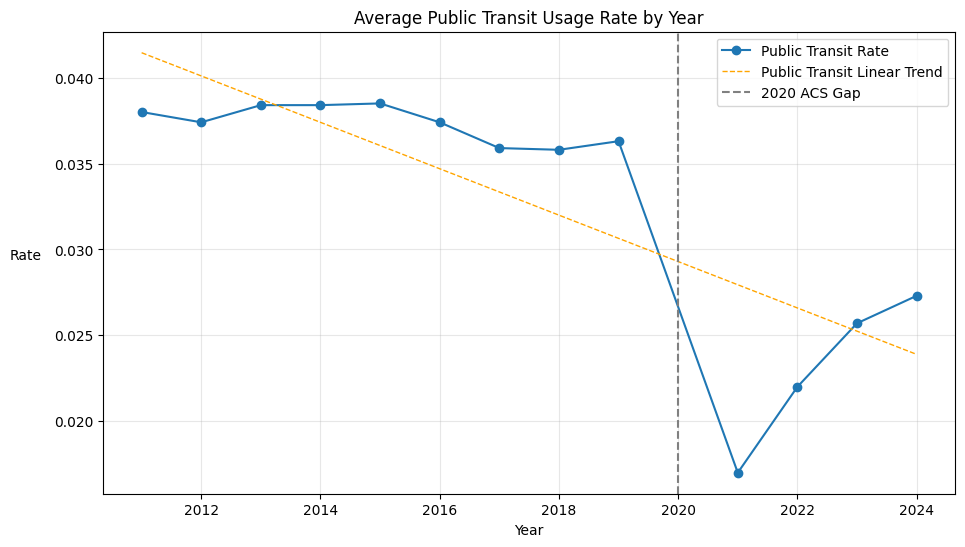

In [162]:
# Chart 2: Public transit trend over time

plt.figure(figsize=(11, 6))

plt.plot(
    remote_yearly_summary["year"],
    remote_yearly_summary["avg_public_transit_rate"],
    marker="o",
    label="Public Transit Rate"
)

# Prepare X and y for sklearn
X2 = remote_yearly_summary[["year"]]
y2 = remote_yearly_summary["avg_public_transit_rate"]

# Fit regression
linreg_model_transit = LinearRegression()
linreg_model_transit.fit(X2, y2)

y_pred_transit = linreg_model_transit.predict(X2)

# Plot trend line
plt.plot(
    remote_yearly_summary["year"],
    y_pred_transit,
    linestyle="--",
    linewidth=1,
    label="Public Transit Linear Trend",
    color="orange"
)

plt.axvline(2020, linestyle="--", color="gray", label="2020 ACS Gap")

plt.title("Average Public Transit Usage Rate by Year")
plt.xlabel("Year")
plt.ylabel("Rate", rotation=0, labelpad=20)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation: Public Transit Usage Declined Following COVID-19

Public transit usage remained relatively stable before COVID-19, between approximately 3.5% and 4.0% from 2011 through 2019. This suggests that commuting patterns and transit reliance were fairly consistent across states during the pre-pandemic period.

Following COVID-19, public transit usage declined sharply. The average public transit rate fell to roughly 1.7% in 2021, representing a significant drop compared to pre-pandemic levels. Although transit usage began to recover gradually in the years since, it has still remained below pre-COVID levels.

The linear trendline highlights the broader downward movement in public transit usage across the study period. Together, these patterns suggest that the pandemic significantly disrupted traditional commuting behavior and that many workers did not fully return to pre-pandemic transit patterns, likely due in part to the continued growth of remote and hybrid work arrangements.

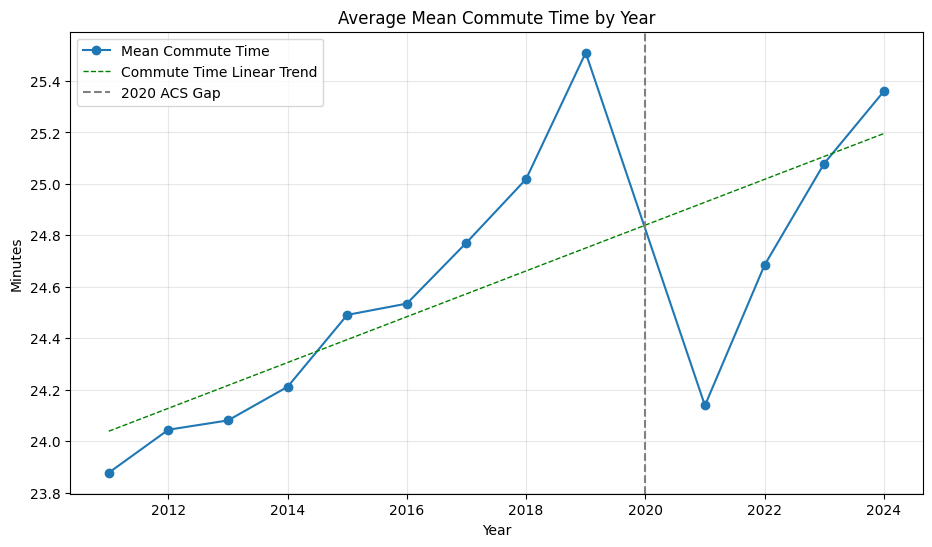

In [163]:
# Chart 3: Mean commute time trend over time

plt.figure(figsize=(11, 6))

plt.plot(
    remote_yearly_summary["year"],
    remote_yearly_summary["avg_commute_time"],
    marker="o",
    label="Mean Commute Time"
)

# Prepare X and y for sklearn
X3 = remote_yearly_summary[["year"]]
y3 = remote_yearly_summary["avg_commute_time"]

# Fit regression
linreg_model_commute = LinearRegression()
linreg_model_commute.fit(X3, y3)

y_pred_commute = linreg_model_commute.predict(X3)

# Plot trend line
plt.plot(
    remote_yearly_summary["year"],
    y_pred_commute,
    linestyle="--",
    linewidth=1,
    label="Commute Time Linear Trend",
    color="green"
)

plt.axvline(2020, linestyle="--", color="gray", label="2020 ACS Gap")

plt.title("Average Mean Commute Time by Year")
plt.xlabel("Year")
plt.ylabel("Minutes")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation: Average Commute Times Changed Less Than Other Work Patterns

Compared to remote work adoption and public transit usage, average commute times remained relatively stable. Commute times gradually increased between 2011 and 2019, rising from around 24 minutes to approximately 25.5 minutes before the pandemic in 2019.

Following COVID-19, average commute times declined noticeably in 2021, likely reflecting the sharp increase in remote and hybrid work arrangements during the immediate post-pandemic period. However, commute times gradually increased again between 2022 and 2024, eventually returning close to pre-pandemic levels.

The linear trendline highlights a small overall upward movement in commute times across the study period. Unlike remote work and transit usage, which experienced more dramatic structural shifts following COVID-19, commute times appear to have recovered more gradually toward longer-term historical patterns.

In [164]:
# Groupby 3: Regional commute summary

regional_commute_summary = (
    acs.groupby(["region", "period"])
    .agg(
        avg_remote_work_rate=("remote_work_rate", "mean"),
        avg_public_transit_rate=("public_transit_rate", "mean"),
        avg_commute_time=("mean_commute_time", "mean")
    )
    .round(4)
    .reset_index()
)

regional_commute_summary

,region,period,avg_remote_work_rate,avg_public_transit_rate,avg_commute_time
0,Midwest,Post-COVID,0.1226,0.0117,21.9379
1,Midwest,Pre-COVID,0.0458,0.0195,21.7010
2,Northeast,Post-COVID,0.1600,0.0520,27.3107
3,Northeast,Pre-COVID,0.0505,0.0723,27.2187
4,Puerto Rico,Post-COVID,0.0608,0.0090,28.1229
5,Puerto Rico,Pre-COVID,0.0223,0.0214,29.5762
6,South,Post-COVID,0.1380,0.0210,26.3068
7,South,Pre-COVID,0.0420,0.0381,25.7931
8,West,Post-COVID,0.1465,0.0170,23.5394
9,West,Pre-COVID,0.0563,0.0299,23.1373


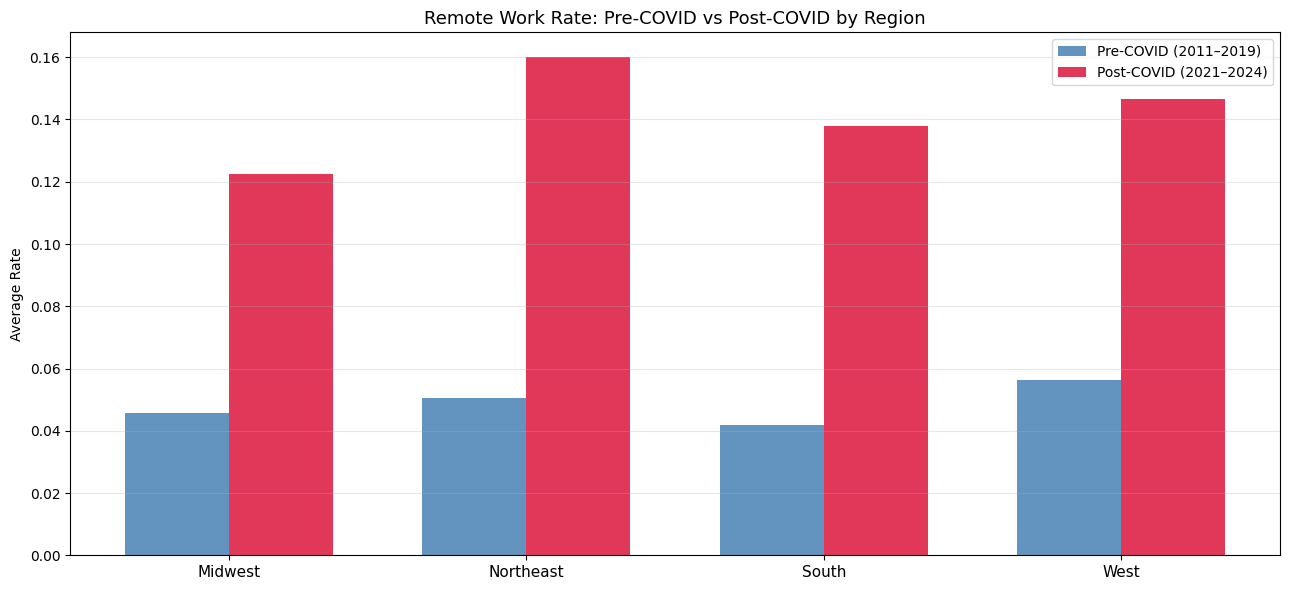

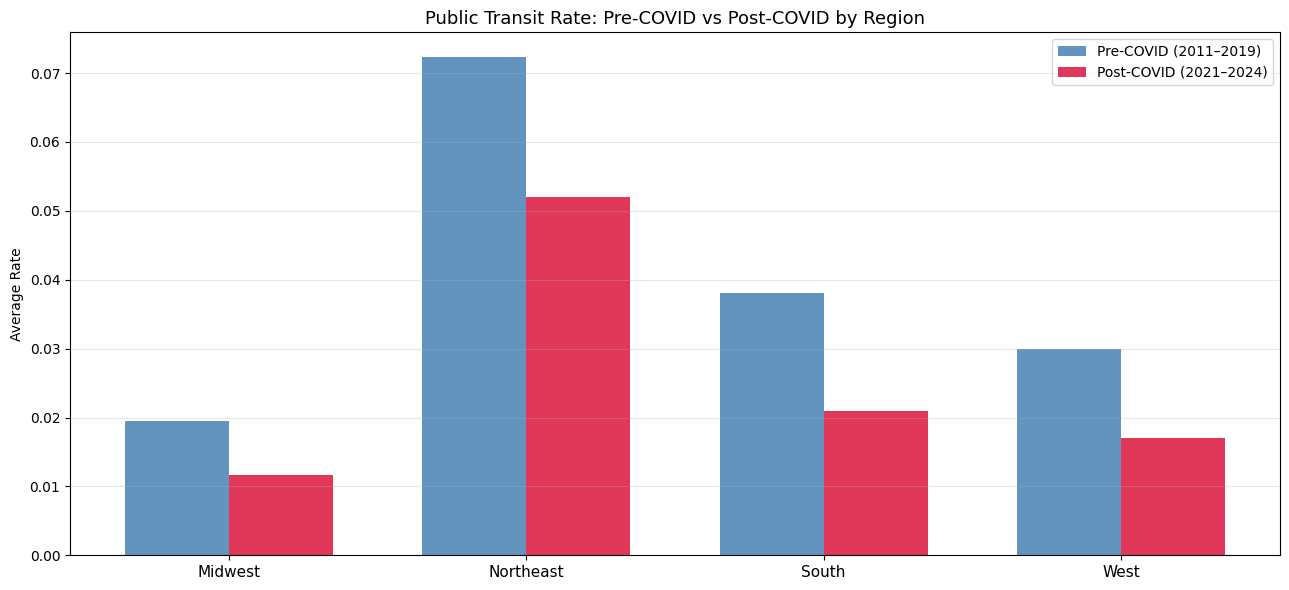

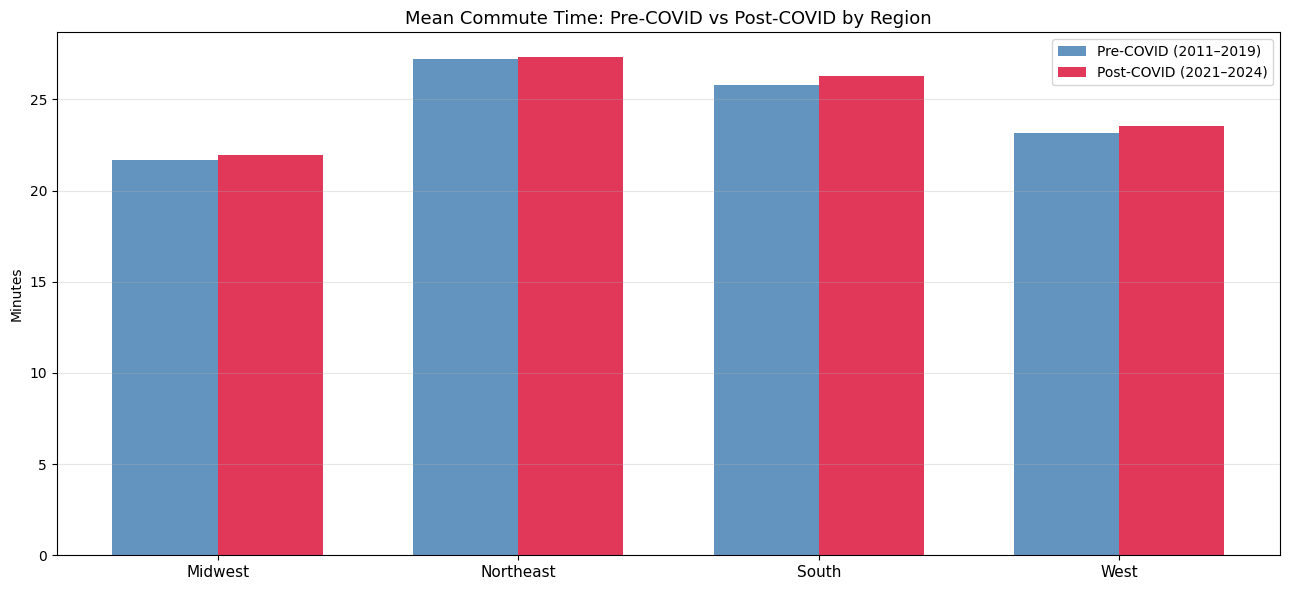

In [165]:
# Grouped bar chart: Remote work, transit usage, and commute time by region

regional_commute_filtered = regional_commute_summary[
    regional_commute_summary["region"] != "Puerto Rico"
]

metrics = [
    "avg_remote_work_rate",
    "avg_public_transit_rate",
    "avg_commute_time"
]

labels = [
    "Remote Work Rate",
    "Public Transit Rate",
    "Mean Commute Time"
]

for metric, label in zip(metrics, labels):

    pivot = regional_commute_filtered.pivot(
        index="region",
        columns="period",
        values=metric
    )

    regions = pivot.index

    pre = pivot["Pre-COVID"].values
    post = pivot["Post-COVID"].values

    x = np.arange(len(regions))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.bar(
        x - width/2,
        pre,
        width,
        label="Pre-COVID (2011–2019)",
        color="steelblue",
        alpha=0.85
    )

    ax.bar(
        x + width/2,
        post,
        width,
        label="Post-COVID (2021–2024)",
        color="crimson",
        alpha=0.85
    )

    ax.set_xticks(x)
    ax.set_xticklabels(regions, fontsize=11)

    if metric == "avg_commute_time":
        ax.set_ylabel("Minutes")
    else:
        ax.set_ylabel("Average Rate")

    ax.set_title(
        f"{label}: Pre-COVID vs Post-COVID by Region",
        fontsize=13
    )

    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [166]:
# Calculate post-COVID minus pre-COVID differences

commute_diff = (
    regional_commute_filtered
    .pivot(index="region", columns="period")
)

# Difference calculations
commute_diff["remote_work_change"] = (
    commute_diff[("avg_remote_work_rate", "Post-COVID")] -
    commute_diff[("avg_remote_work_rate", "Pre-COVID")]
)

commute_diff["public_transit_change"] = (
    commute_diff[("avg_public_transit_rate", "Post-COVID")] -
    commute_diff[("avg_public_transit_rate", "Pre-COVID")]
)

commute_diff["commute_time_change"] = (
    commute_diff[("avg_commute_time", "Post-COVID")] -
    commute_diff[("avg_commute_time", "Pre-COVID")]
)

# Keep only final columns
commute_diff = commute_diff[[
    "remote_work_change",
    "public_transit_change",
    "commute_time_change"
]].round(4)

commute_diff.reset_index()

,region,remote_work_change,public_transit_change,commute_time_change
period,,,,
0,Midwest,0.0768,-0.0078,0.2369
1,Northeast,0.1095,-0.0203,0.0920
2,South,0.0960,-0.0171,0.5137
3,West,0.0902,-0.0129,0.4021


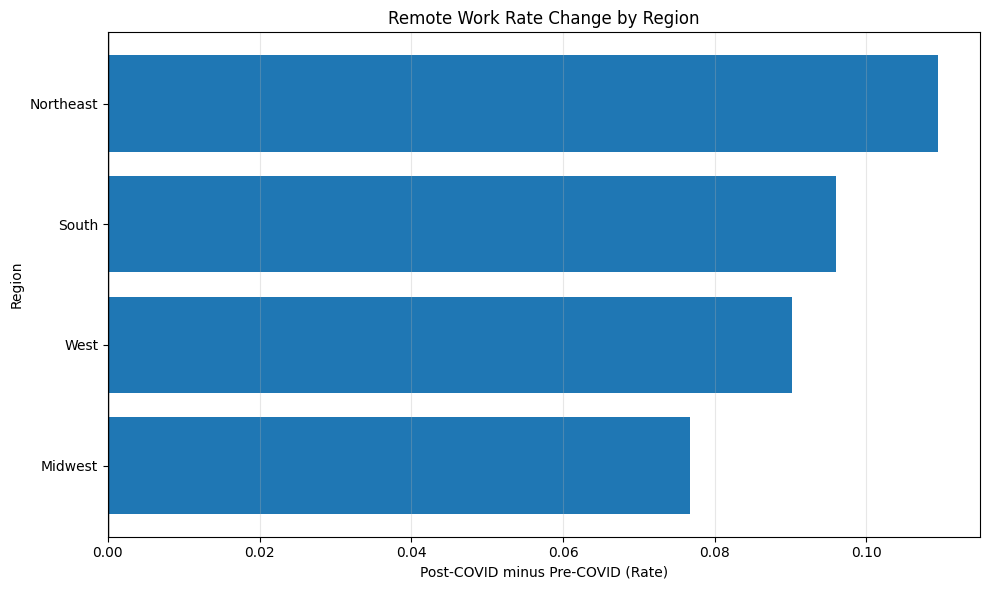

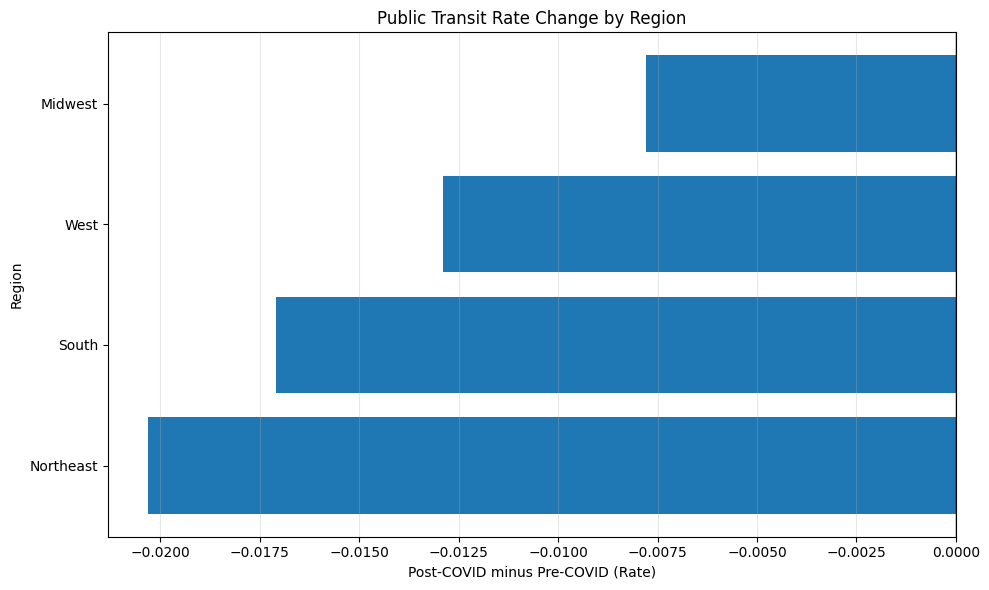

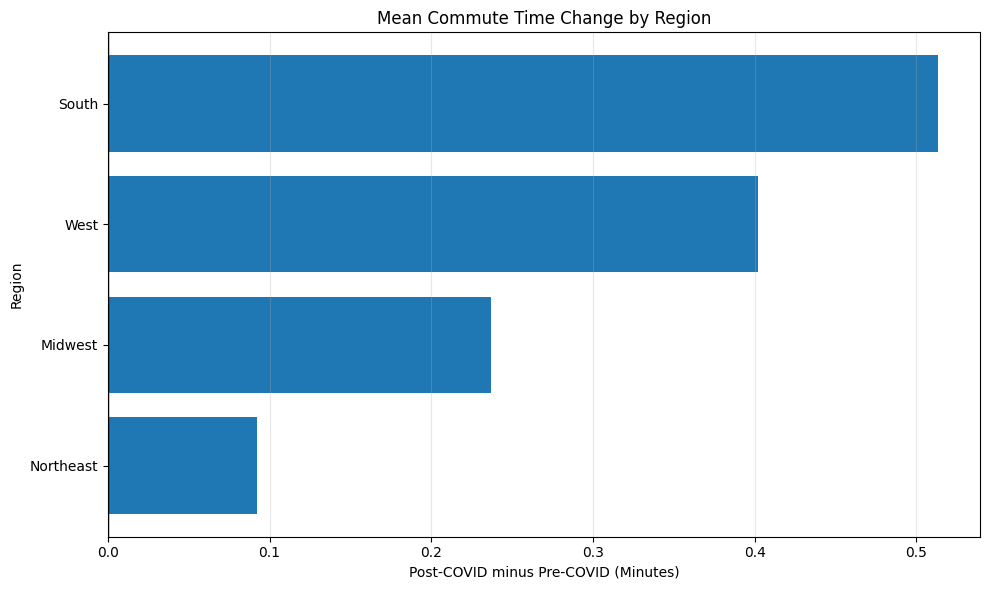

In [167]:
# Diverging bar charts: Pre vs Post COVID changes by region

change_metrics = [
    "remote_work_change",
    "public_transit_change",
    "commute_time_change"
]

change_labels = [
    "Remote Work Rate Change",
    "Public Transit Rate Change",
    "Mean Commute Time Change"
]

for metric, label in zip(change_metrics, change_labels):

    plot_data = commute_diff.reset_index().sort_values(metric)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        plot_data["region"],
        plot_data[metric]
    )

    ax.axvline(0, color="black", linewidth=1)

    if metric == "commute_time_change":
        ax.set_xlabel("Post-COVID minus Pre-COVID (Minutes)")
    else:
        ax.set_xlabel("Post-COVID minus Pre-COVID (Rate)")

    ax.set_ylabel("Region")
    ax.set_title(f"{label} by Region")

    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

### Regional Differences in Remote Work and Commuting Patterns

The regional results suggest that the impact of COVID-19 on commuting behavior was not uniform across the United States. All four major regions experienced substantial increases in remote work adoption following the pandemic, although the magnitude of the increase differed across regions.

The Northeast experienced the highest increase in remote work rates after COVID-19, increasing from approximately 5.0% pre-pandemic to 16.0% post-pandemic. The West also showed relatively high remote work adoption, increasing from approximately 5.6% to 14.8%. In contrast, the Midwest and South started from lower pre-pandemic remote work levels and remained somewhat lower than the Northeast and West following COVID-19. These patterns suggest that regions with larger concentrations of office-based and professional-service employment may have transitioned more easily toward remote and hybrid work arrangements.

Public transit usage declined across all regions following COVID-19. The Northeast maintained the highest transit usage overall, though its average transit rate still fell substantially from 7.2% pre-COVID to 5.2% post-COVID. The South, West, and Midwest also experienced declines, although transit usage remained considerably lower in these regions overall. This suggests that the pandemic disrupted traditional commuting behavior nationwide, particularly in regions more dependent on public transportation systems.

Average commute times changed less dramatically than remote work and transit usage. Commute times increased slightly in most regions following COVID-19, with the Northeast maintaining the longest average commute times overall. One possible explanation is that although more workers adopted remote or hybrid work arrangements, some individuals may have moved farther away from city centers or primary workplaces during and after the pandemic. As a result, fewer people may have been commuting daily, but those who did commute may have been traveling longer distances on average.

# Conclusion

This analysis explored how social and economic resilience varied across U.S. states before and after COVID-19 using American Community Survey (ACS) data from 2016–2024. The project examined trends in income, employment, poverty, housing affordability, education, insurance access, commuting patterns, relationship metrics, and broader social conditions to better understand how states recoverd post-pandemic.

#### **Key findings:**
1. **Resilience was not evenly distributed across the country.** States with stronger pre-COVID socioeconomic conditions generally maintained stronger outcomes during the post-COVID recovery period, while lower-resilience states often continued to face higher levels of poverty, unemployment, housing burden, and uninsured populations. Geographic clustering patterns remained visible even after recovery began.

2. **Many indicators demonstrated measurable shifts after COVID-19.** Remote work participation increased substantially across many states, while commuting patterns and public transit usage changed in ways that reflected broader labor market and behavioral adjustments. Housing affordability pressures also intensified in many regions, suggesting that recovery was uneven across different dimensions of well-being.

3. **Relationship analysis and modeling further reinforced the interconnected nature of resilience.** Higher education attainment tended to be associated with lower poverty and unemployment rates, while higher uninsured and housing burden rates were often linked with weaker resilience outcomes. The regression and classification models demonstrated that multiple socioeconomic indicators collectively contributed to resilience patterns across states.

Overall, this project highlights that post-COVID recovery cannot be understood through a single economic or social metric alone. Resilience reflects a combination of economic stability, access to healthcare, education, housing conditions, and labor market adaptability. Understanding these relationships may help public health organizations, policymakers, and economic development leaders better identify where targeted investment and long-term resilience planning may be most beneficial in the future.